In [1]:
import ROOT
import numpy as np
import uproot as ur
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep
import os
hep.style.use("CMS")
hep.style.use(hep.style.CMS)
import matplotlib.colors as mcolors
from matplotlib import colormaps
from scipy.optimize import curve_fit
import pandas as pd
from cycler import cycler
plt.rcParams["axes.prop_cycle"] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [2]:
solid_target = "C"
plot_title = "RGE LD2 + C: 20131-20176 pass 0.7"
sim_title = "RGE LD2 + C: clasdis simulation"

In [3]:
separated_sim_liquid_and_solid = True
directories = {"data" : "/media/miguel/Elements_2024/CLAS_data/",
               "sim_liquid" : "/media/miguel/Elements_2024/CLAS_data/",
               "sim_solid" : "/media/miguel/Elements_2024/CLAS_data/",
              }
file_names = {"data" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_020131-020176_pass07_roottuples.root",
              "sim_liquid" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_LD2Cliquid_clasdis_deuteron_3000files_roottuples.root",
              "sim_solid" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_LD2Csolid_clasdis_deuteron_3000files_roottuples.root",
             }

branches_dict = {}
for name in directories:
    with ur.open(f"{os.path.join(directories[name], file_names[name])}:electrons") as events:
        branches = events.arrays()
        permutation = np.random.permutation(len(branches))
        branches_shuffled = branches[permutation]
        branches_dict[name] = branches_shuffled[:]

if separated_sim_liquid_and_solid:
    branches_dict["sim_solid"]["weight"] = 1
    branches_dict["sim_liquid"]["weight"] = 1
    
    n_liquid = len(branches_dict["sim_liquid"]["v_z"])
    branches_dict["sim_liquid"]["target"] = ak.Array(["D2"]*n_liquid)
    n_solid  = len(branches_dict["sim_solid"]["v_z"])
    branches_dict["sim_solid"]["target"] = ak.Array([solid_target]*n_solid)
    branches_dict["sim"] = ak.concatenate([branches_dict["sim_liquid"], branches_dict["sim_solid"]])
else:
    branches_dict["sim"]["weight"] = 1


In [4]:
sim_mask = (branches_dict["sim"]["p"]>2) & (branches_dict["sim"]["p"]<8) & (branches_dict["sim"]["theta_degrees"]>2)
branches_dict["sim"] = branches_dict["sim"][sim_mask]

data_mask = (branches_dict["data"]["p"]>2) & (branches_dict["data"]["p"]<8) & (branches_dict["data"]["theta_degrees"]>2)
branches_dict["data"] = branches_dict["data"][data_mask]

In [5]:
def calc_theta_lab(px, py, pz):
    return np.arctan2(np.sqrt(px**2 + py**2), pz)
def calc_Q2(p, beam_E, theta):
    return 4 * p * beam_E* np.sin(theta/2)*np.sin(theta/2)
def calc_nu(p, beam_E):
    return beam_E - p
def calc_xb(Q2, beam_E, nu):
    proton_mass = .938
    return np.array(Q2/(2*proton_mass*nu))
def calc_y(p, beam_E):
    return calc_nu(p, beam_E)/beam_E
def calc_W2(p, beam_E, theta):
    proton_mass = .938
    return proton_mass*proton_mass + 2*proton_mass*calc_nu(p, beam_E) - calc_Q2(p, beam_E, theta)

In [6]:
E_beam = 10.547

In [7]:
variables_to_unfold = ["v_z", "p", "theta_degrees", "phi_degrees", "x", "Q2"]
sim_MCreco_dict, sim_MCgen_dict =  {}, {}
for variable in variables_to_unfold:
    sim_MCreco_dict[variable] = np.array(branches_dict["sim"][variable])
    sim_MCgen_dict[variable] = np.array(branches_dict["sim"][variable])
df_MCgen_test = ROOT.RDF.FromNumpy(sim_MCgen_dict)
df_MCreco_test = ROOT.RDF.FromNumpy(sim_MCgen_dict)

In [8]:
def np_to_TVector(array):
    vector = ROOT.TVector(len(array))
    for i, entry in enumerate(array):
        vector[i] = entry
    return vector
def TVector_to_np(vector):
    out_array = []
    for i in range(vector.GetNoElements()):
        out_array.append(vector[i])
    return np.array(out_array)

In [9]:
unbinned_unfolding = ROOT.RooUnfoldOmnifold()
unbinned_unfolding.SetSaveDirectory("/home/ryan/clas_analysis/clas12-rge-analysis/analysis/")
unbinned_unfolding.SetModelName("RGE_carbon_roottuples_withfiducialcuts_W2GeV_pass08")
unbinned_unfolding.SetTestMCgenDataFrame(df_MCgen_test)
unbinned_unfolding.SetTestMCrecoDataFrame(df_MCreco_test)


In [10]:
test_unbinned_results = unbinned_unfolding.TestUnbinnedOmnifold()
step1_test_weights_TVector = ROOT.std.get[0](test_unbinned_results)
step2_test_weights_TVector = ROOT.std.get[1](test_unbinned_results)
step1_weights = TVector_to_np(step1_test_weights_TVector)
branches_dict["sim"]["step1_weights"] = step1_weights

Opening /home/ryan/clas_analysis/clas12-rge-analysis/analysis/RGE_carbon_roottuples_withfiducialcuts_W2GeV_pass08_models.pkl for step 1 predictions.
(3666100, 6)
(3666100, 6)
[]
Opening /home/ryan/clas_analysis/clas12-rge-analysis/analysis/RGE_carbon_roottuples_withfiducialcuts_W2GeV_pass08_models.pkl for step 2 predictions.
(3666100, 6)
about to make step 2
made step 2


Text(0.5, 1.0, 'Sim both targets')

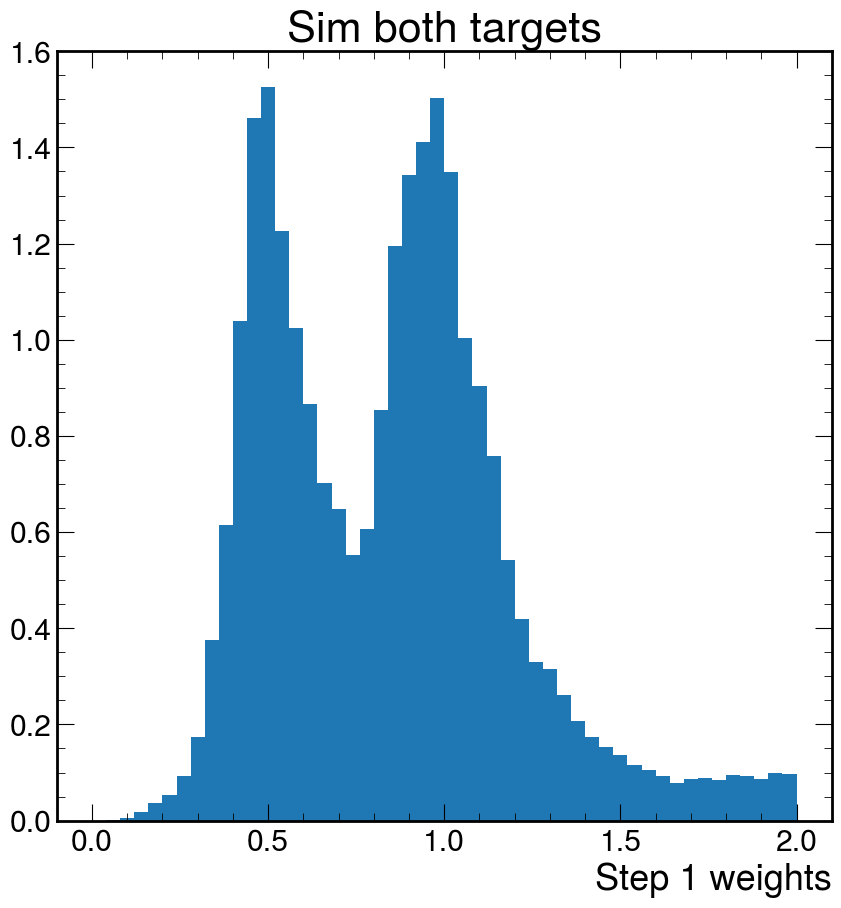

In [11]:
plt.hist(branches_dict["sim"]["step1_weights"], bins=50, range=(0,2), density=True)
plt.xlabel("Step 1 weights")
plt.title("Sim both targets")

Text(0.5, 1.0, 'Sim solid target')

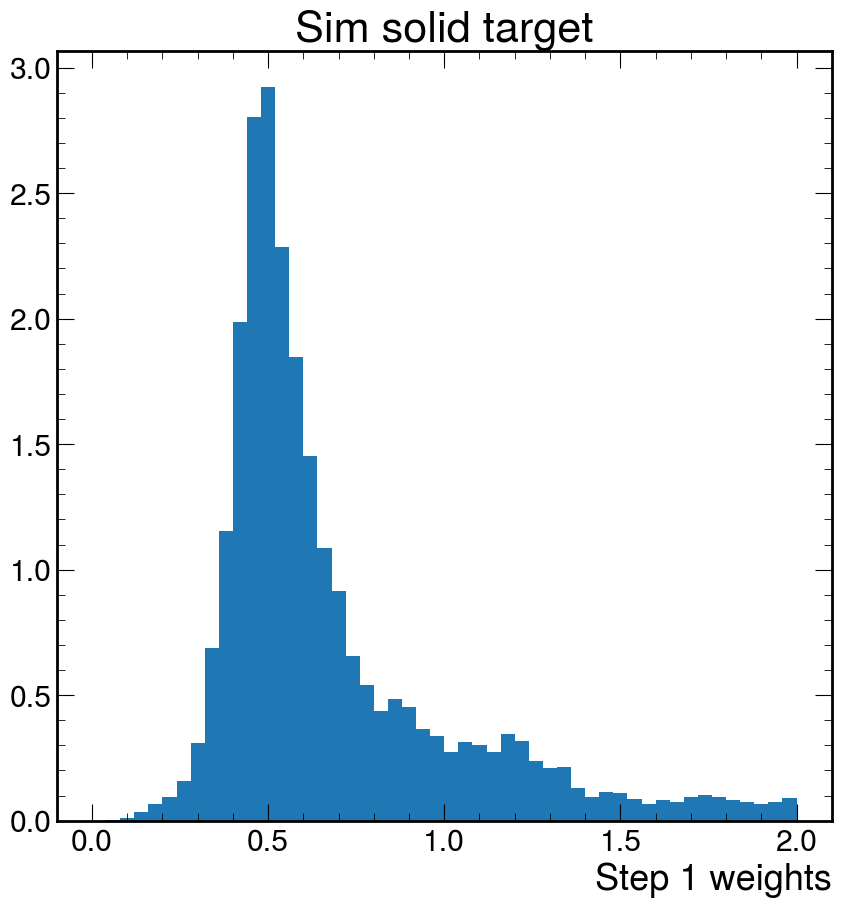

In [12]:
plt.hist(branches_dict["sim"]["step1_weights"][branches_dict["sim"]["target"]==solid_target], bins=50, range=(0,2), density=True)
plt.xlabel("Step 1 weights")
plt.title("Sim solid target")

Text(0.5, 1.0, 'Sim D2 target')

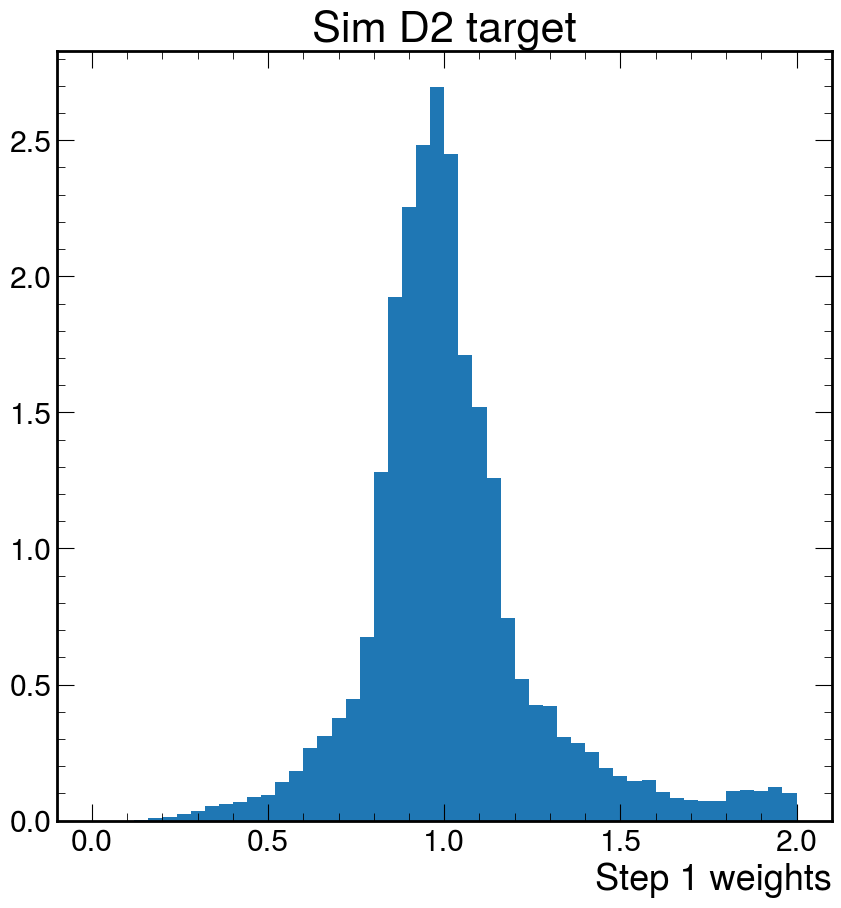

In [13]:
plt.hist(branches_dict["sim"]["step1_weights"][branches_dict["sim"]["target"]=="D2"], bins=50, range=(0,2), density=True)
plt.xlabel("Step 1 weights")
plt.title("Sim D2 target")

In [14]:
lumonisity_ratios = {"C": .75, "Pb":.5}
num_sectors=6

Text(0.5, 1.0, 'e+A DIS phase-space')

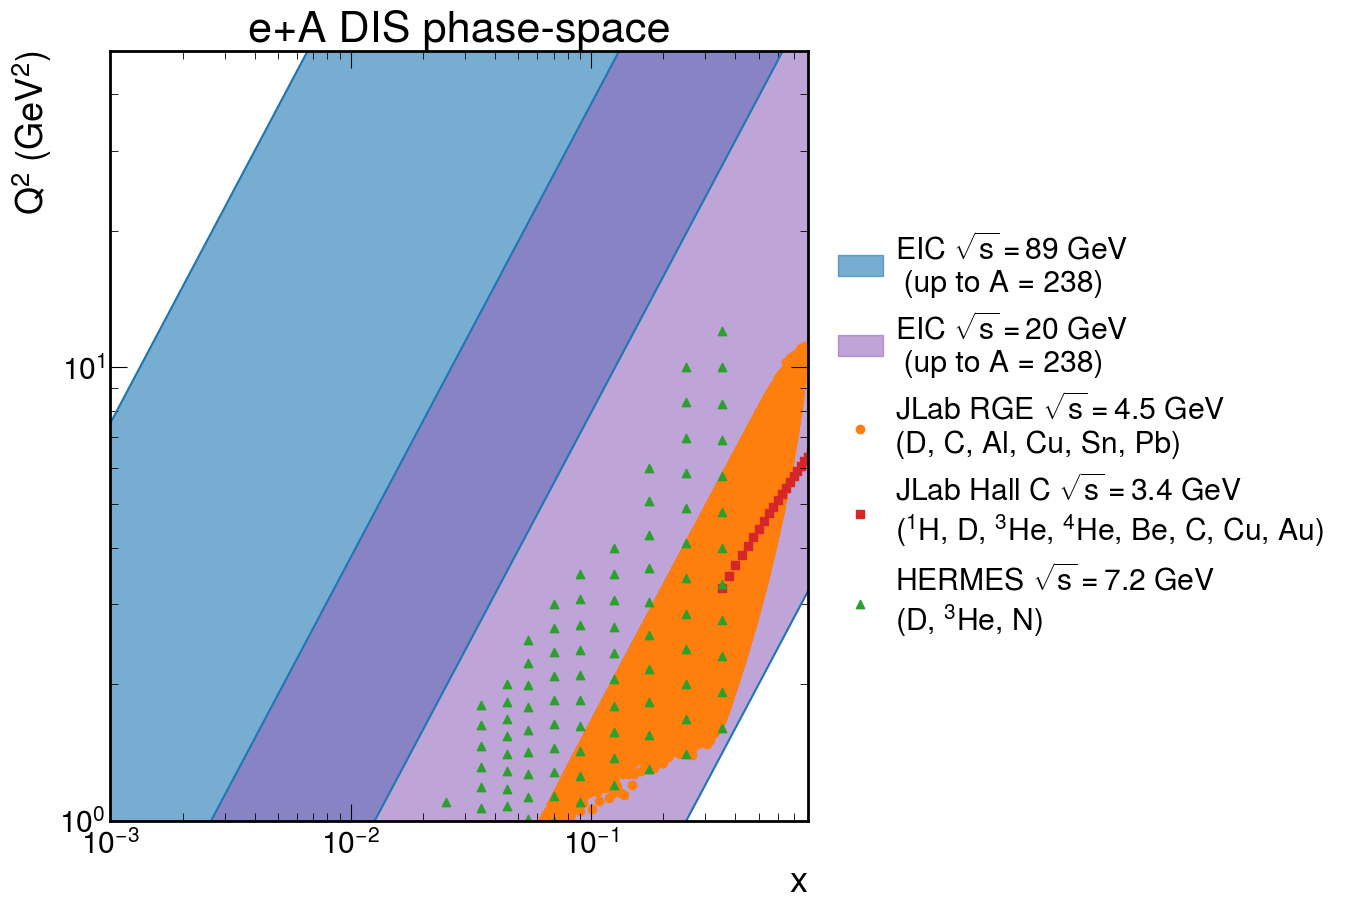

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 10))
ax = plt.gca()

# EIC sqrt s = 89 GeV
s = 89**2 
y_min = 0.01
y_max = .95
x = np.logspace(-4, 0, 500)
Q2_min = x * y_min * s
Q2_max = x * y_max * s
plt.fill_between(x, Q2_min, Q2_max, color='#1f77b4', alpha=0.6, label="EIC $\sqrt{s} = 89$ GeV\n (up to A = 238)")
plt.plot(x, Q2_min, color='#1f77b4')
plt.plot(x, Q2_max, color='#1f77b4')

# EIC sqrt s = 20 GeV
s = 20**2 
Q2_min = x * y_min * s
Q2_max = x * y_max * s
plt.fill_between(x, Q2_min, Q2_max, color='#9467bd', alpha=0.6, label="EIC $\sqrt{s} = 20$ GeV\n (up to A = 238)")
plt.plot(x, Q2_min, color='#1f77b4')
plt.plot(x, Q2_max, color='#1f77b4')

hermes_x = [.0125, .0175, .025, .035, .045, .055, .07, .09, .125, .175, .25, .35]
hermes_Q2 = [
    np.logspace(np.log10(0.3),  np.log10(0.5),  4),
    np.logspace(np.log10(0.45), np.log10(0.8),  5),
    np.logspace(np.log10(0.5),  np.log10(1.1),  8),
    np.logspace(np.log10(0.7),  np.log10(1.8),  10),
    np.logspace(np.log10(0.9),  np.log10(2),    10),
    np.logspace(np.log10(0.9),  np.log10(2.5),  10),
    np.logspace(np.log10(1),    np.log10(3),    10),
    np.logspace(np.log10(1.1),  np.log10(3.5),  10),
    np.logspace(np.log10(1.2),  np.log10(4),    10),
    np.logspace(np.log10(1.3),  np.log10(6),    10),
    np.logspace(np.log10(1.4),  np.log10(10),   12),
    np.logspace(np.log10(1.6),  np.log10(12),   12)
]

x_vals = []
q2_vals = []

for x, q2_range in zip(hermes_x, hermes_Q2):
    x_vals.extend([x] * len(q2_range))
    q2_vals.extend(q2_range)

plt.scatter(branches_dict["data"]["x"], branches_dict["data"]["Q2"], label="JLab RGE $\sqrt{s} = 4.5$ GeV\n(D, C, Al, Cu, Sn, Pb) ", color='#ff7f0e')
jlab_6gev_data=np.array([[3.500E-1, 3.266E+0, 8.625E-1, 1.006E+0, 1.034E-2, 1.143E-2],
[3.750E-1, 3.466E+0, 8.541E-1, 9.807E-1, 8.507E-3, 1.105E-2],
[4.000E-1, 3.661E+0, 8.459E-1, 9.751E-1, 9.586E-3, 1.089E-2],
[4.250E-1, 3.853E+0, 8.378E-1, 9.721E-1, 6.011E-3, 1.077E-2],
[4.500E-1, 4.041E+0, 8.299E-1, 9.778E-1, 8.015E-3, 1.075E-2],
[4.750E-1, 4.225E+0, 8.221E-1, 9.779E-1, 7.579E-3, 1.076E-2],
[5.000E-1, 4.406E+0, 8.145E-1, 9.541E-1, 5.835E-3, 1.077E-2],
[5.250E-1, 4.584E+0, 8.070E-1, 9.361E-1, 5.704E-3, 1.077E-2],
[5.500E-1, 4.759E+0, 7.997E-1, 9.347E-1, 5.966E-3, 1.086E-2],
[5.750E-1, 4.930E+0, 7.924E-1, 9.250E-1, 7.195E-3, 1.079E-2],
[6.000E-1, 5.098E+0, 7.853E-1, 9.244E-1, 5.292E-3, 1.076E-2],
[6.250E-1, 5.264E+0, 7.784E-1, 9.244E-1, 6.667E-3, 1.070E-2],
[6.500E-1, 5.426E+0, 7.715E-1, 9.023E-1, 9.596E-3, 1.039E-2],
[6.750E-1, 5.586E+0, 7.648E-1, 9.071E-1, 8.462E-3, 1.040E-2],
[7.000E-1, 5.743E+0, 7.582E-1, 9.047E-1, 9.134E-3, 1.032E-2],
[7.250E-1, 5.897E+0, 7.517E-1, 8.985E-1, 1.006E-2, 1.021E-2],
[7.500E-1, 6.049E+0, 7.453E-1, 9.120E-1, 6.692E-3, 1.032E-2],
[7.750E-1, 6.198E+0, 7.391E-1, 9.301E-1, 1.067E-2, 1.050E-2],
[8.000E-1, 6.344E+0, 7.329E-1, 9.367E-1, 1.169E-2, 1.053E-2],
[8.250E-1, 6.488E+0, 7.268E-1, 9.833E-1, 1.349E-2, 1.103E-2],
[8.500E-1, 6.630E+0, 7.209E-1, 1.020E+0, 1.552E-2, 1.142E-2],
[8.750E-1, 6.769E+0, 7.150E-1, 1.123E+0, 1.589E-2, 1.254E-2],
[9.000E-1, 6.907E+0, 7.092E-1, 1.169E+0, 2.385E-2, 1.303E-2],
[9.250E-1, 7.042E+0, 7.035E-1, 1.277E+0, 1.887E-2, 1.421E-2],
[9.500E-1, 7.174E+0, 6.979E-1, 1.361E+0, 4.168E-2, 1.512E-2]])
jlab_6gev_x = jlab_6gev_data[:,0]
jlab_6gev_Q2 = jlab_6gev_data[:,1]
#sqrt s = 3.4 GeV
plt.scatter(jlab_6gev_x, jlab_6gev_Q2, color='#d62728', marker='s', label='JLab Hall C $\sqrt{s} = 3.4$ GeV\n($^1H$, D, $^3He$, $^4He$, Be, C, Cu, Au)')

#sqrt s = 7.2 GeV
plt.scatter(x_vals, q2_vals, color='#2ca02c', marker='^', label='HERMES $\sqrt{s} = 7.2$ GeV\n(D, $^3He$, N)')




box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.75, box.height])  # shrink width to 75%

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), handletextpad=0.4)

# Final formatting
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(0.001, 0.8)
ax.set_ylim(1, 50)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$Q^2$ (GeV$^2$)')
ax.set_title("e+A DIS phase-space")


Text(0.5, 1.0, 'RGE LD2 + C: 20131-20176 pass 0.7')

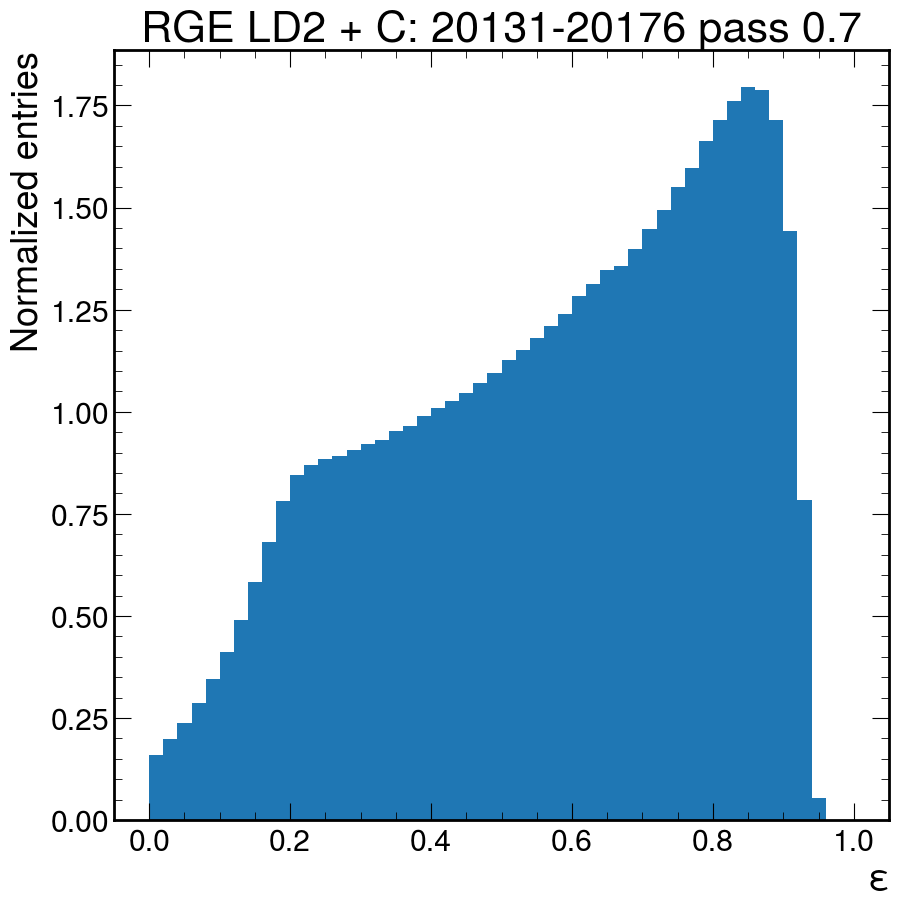

In [16]:
epsilon_numerator = 4*(1-branches_dict["data"]["y"]) - branches_dict["data"]["Q2"]/branches_dict["data"]["p"]**2
epsilon_denominator = 4*(1-branches_dict["data"]["y"]) + 2*branches_dict["data"]["y"]**2 + branches_dict["data"]["Q2"]/branches_dict["data"]["p"]**2
epsilon = epsilon_numerator/epsilon_denominator

plt.hist(epsilon, range = (0,1), bins=50, density=True)
epsilon_numerator = 4*(1-branches_dict["sim"]["y"]) - branches_dict["sim"]["Q2"]/branches_dict["sim"]["p"]**2
epsilon_denominator = 4*(1-branches_dict["sim"]["y"]) + 2*branches_dict["sim"]["y"]**2 + branches_dict["sim"]["Q2"]/branches_dict["sim"]["p"]**2
epsilon = epsilon_numerator/epsilon_denominator
plt.xlabel("$\epsilon$")
plt.ylabel("Normalized entries")
plt.title(plot_title)

Text(0.5, 1.02, 'RGE LD2 + C: 20131-20176 pass 0.7')

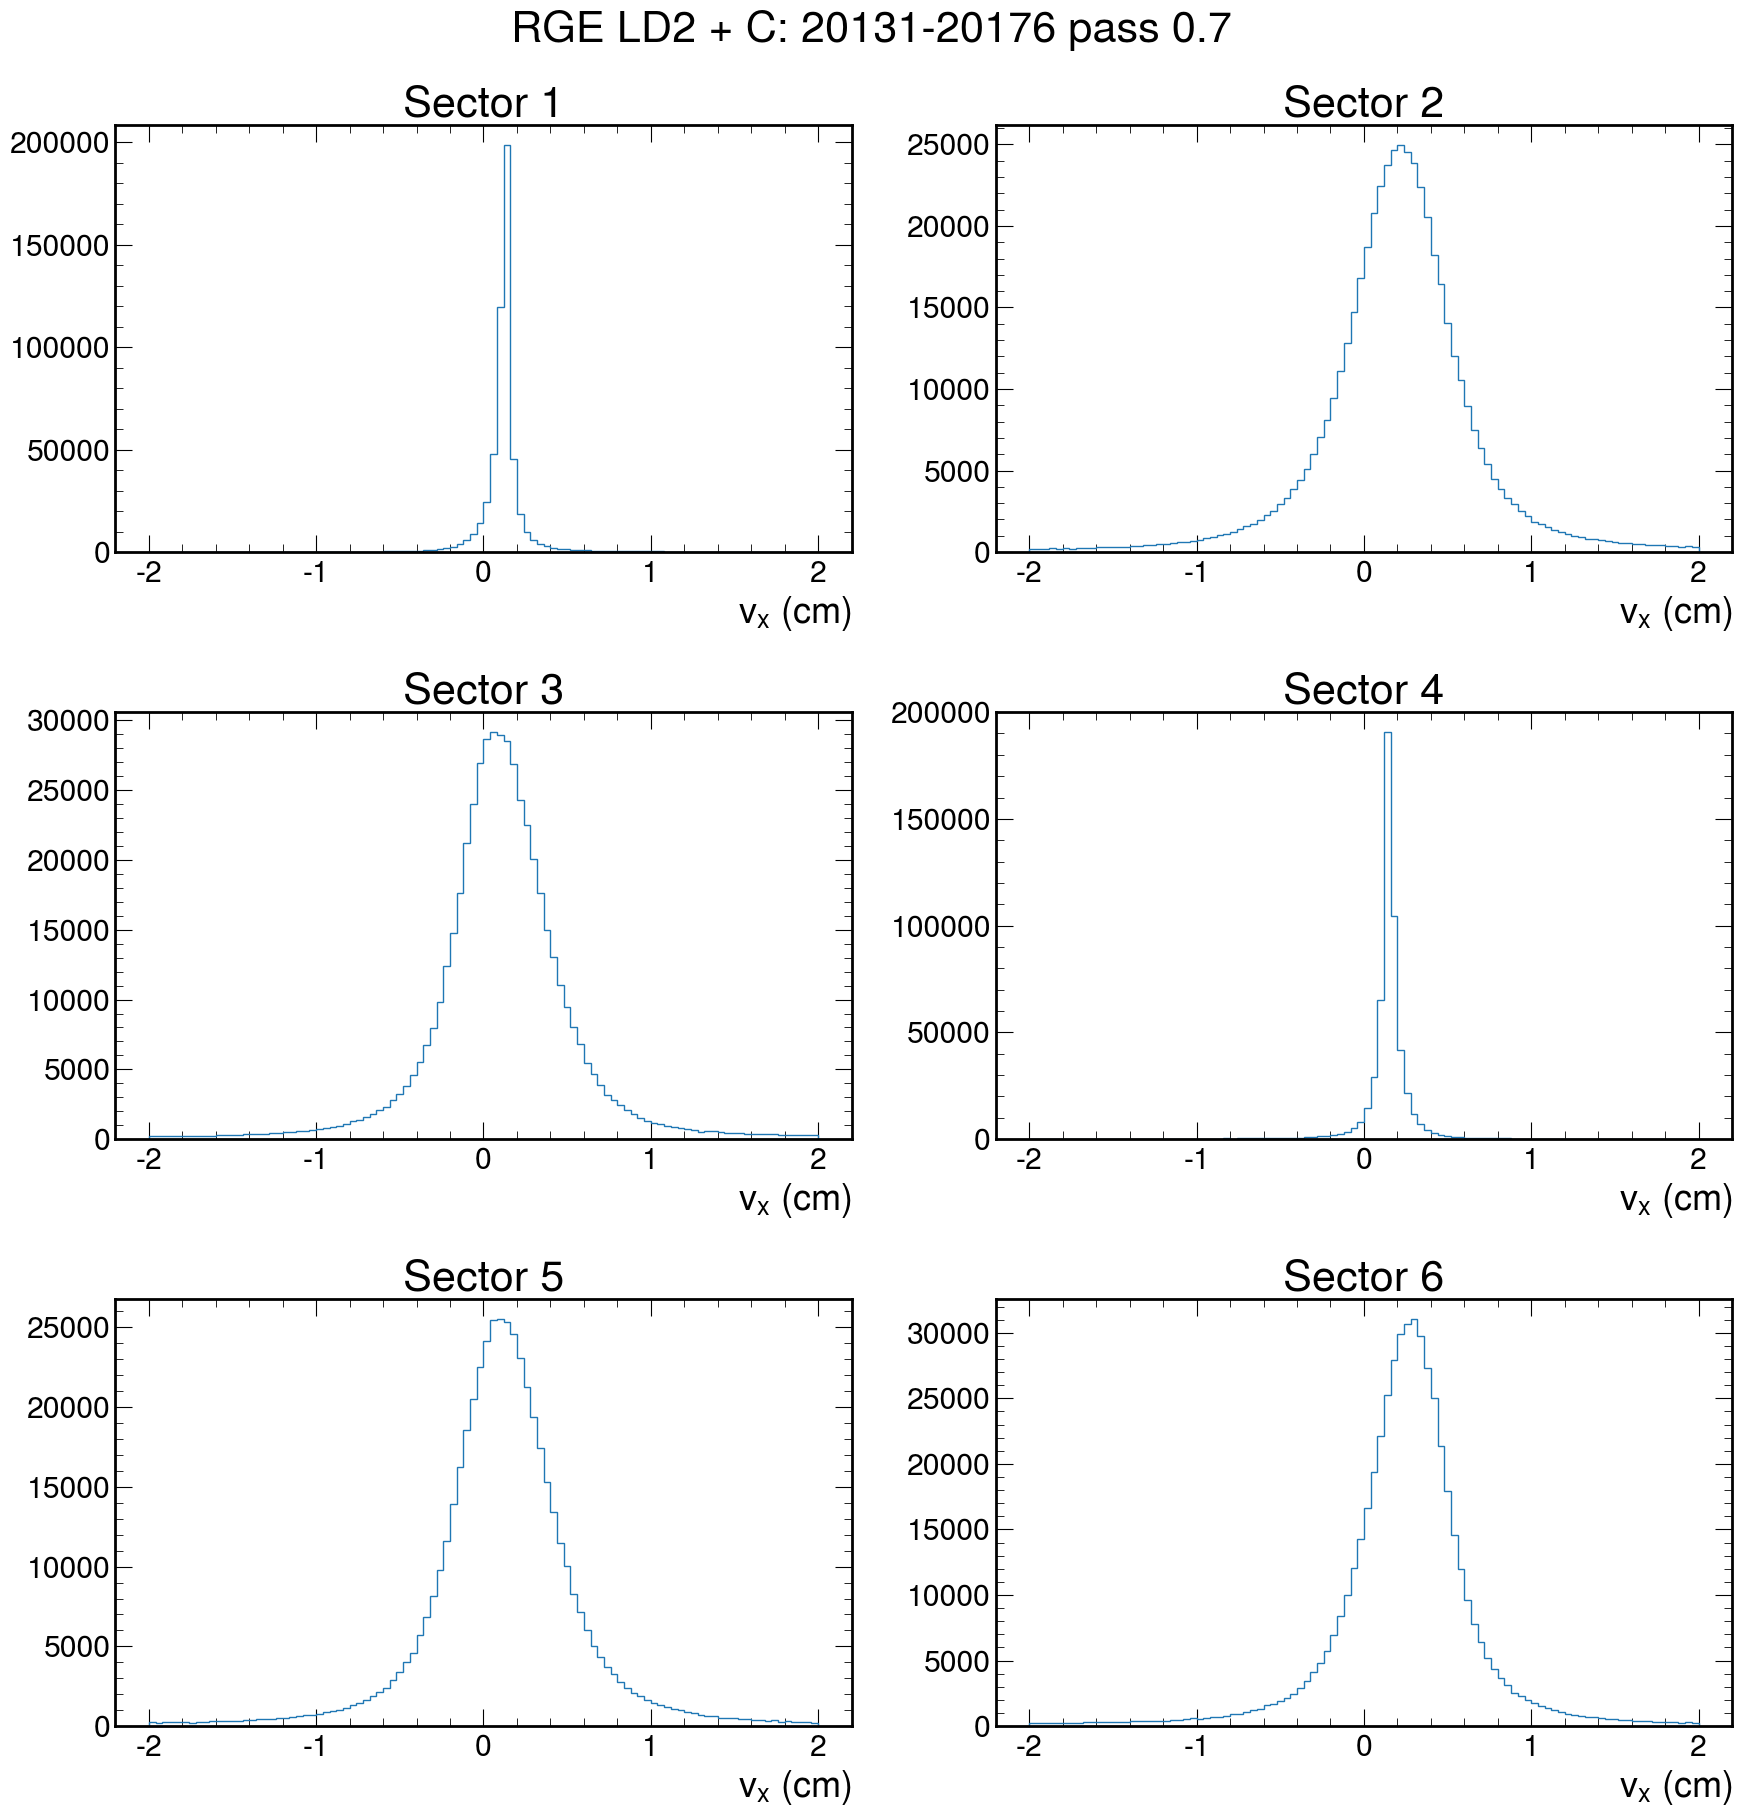

In [17]:
fig, axs = plt.subplots(3, 2, figsize=(18, 18))
axs = axs.flatten()
for sector in range(num_sectors):
    sector_cut = branches_dict["data"]["sector"]==(sector+1)
    
    vertex_x = np.array(branches_dict["data"]["v_x"][sector_cut])
    vertex_x_counts, vertex_x_bins, _ = axs[sector].hist(
        vertex_x,
        bins=100,
        range=(-2,2),
        histtype='step'
    )
    axs[sector].set_xlabel("$v_{x}$ (cm)")
    axs[sector].set_title(f"Sector {sector+1}") 
fig.tight_layout()
fig.suptitle(plot_title, y=1.02)

Text(0.5, 1.02, 'RGE LD2 + C: 20131-20176 pass 0.7')

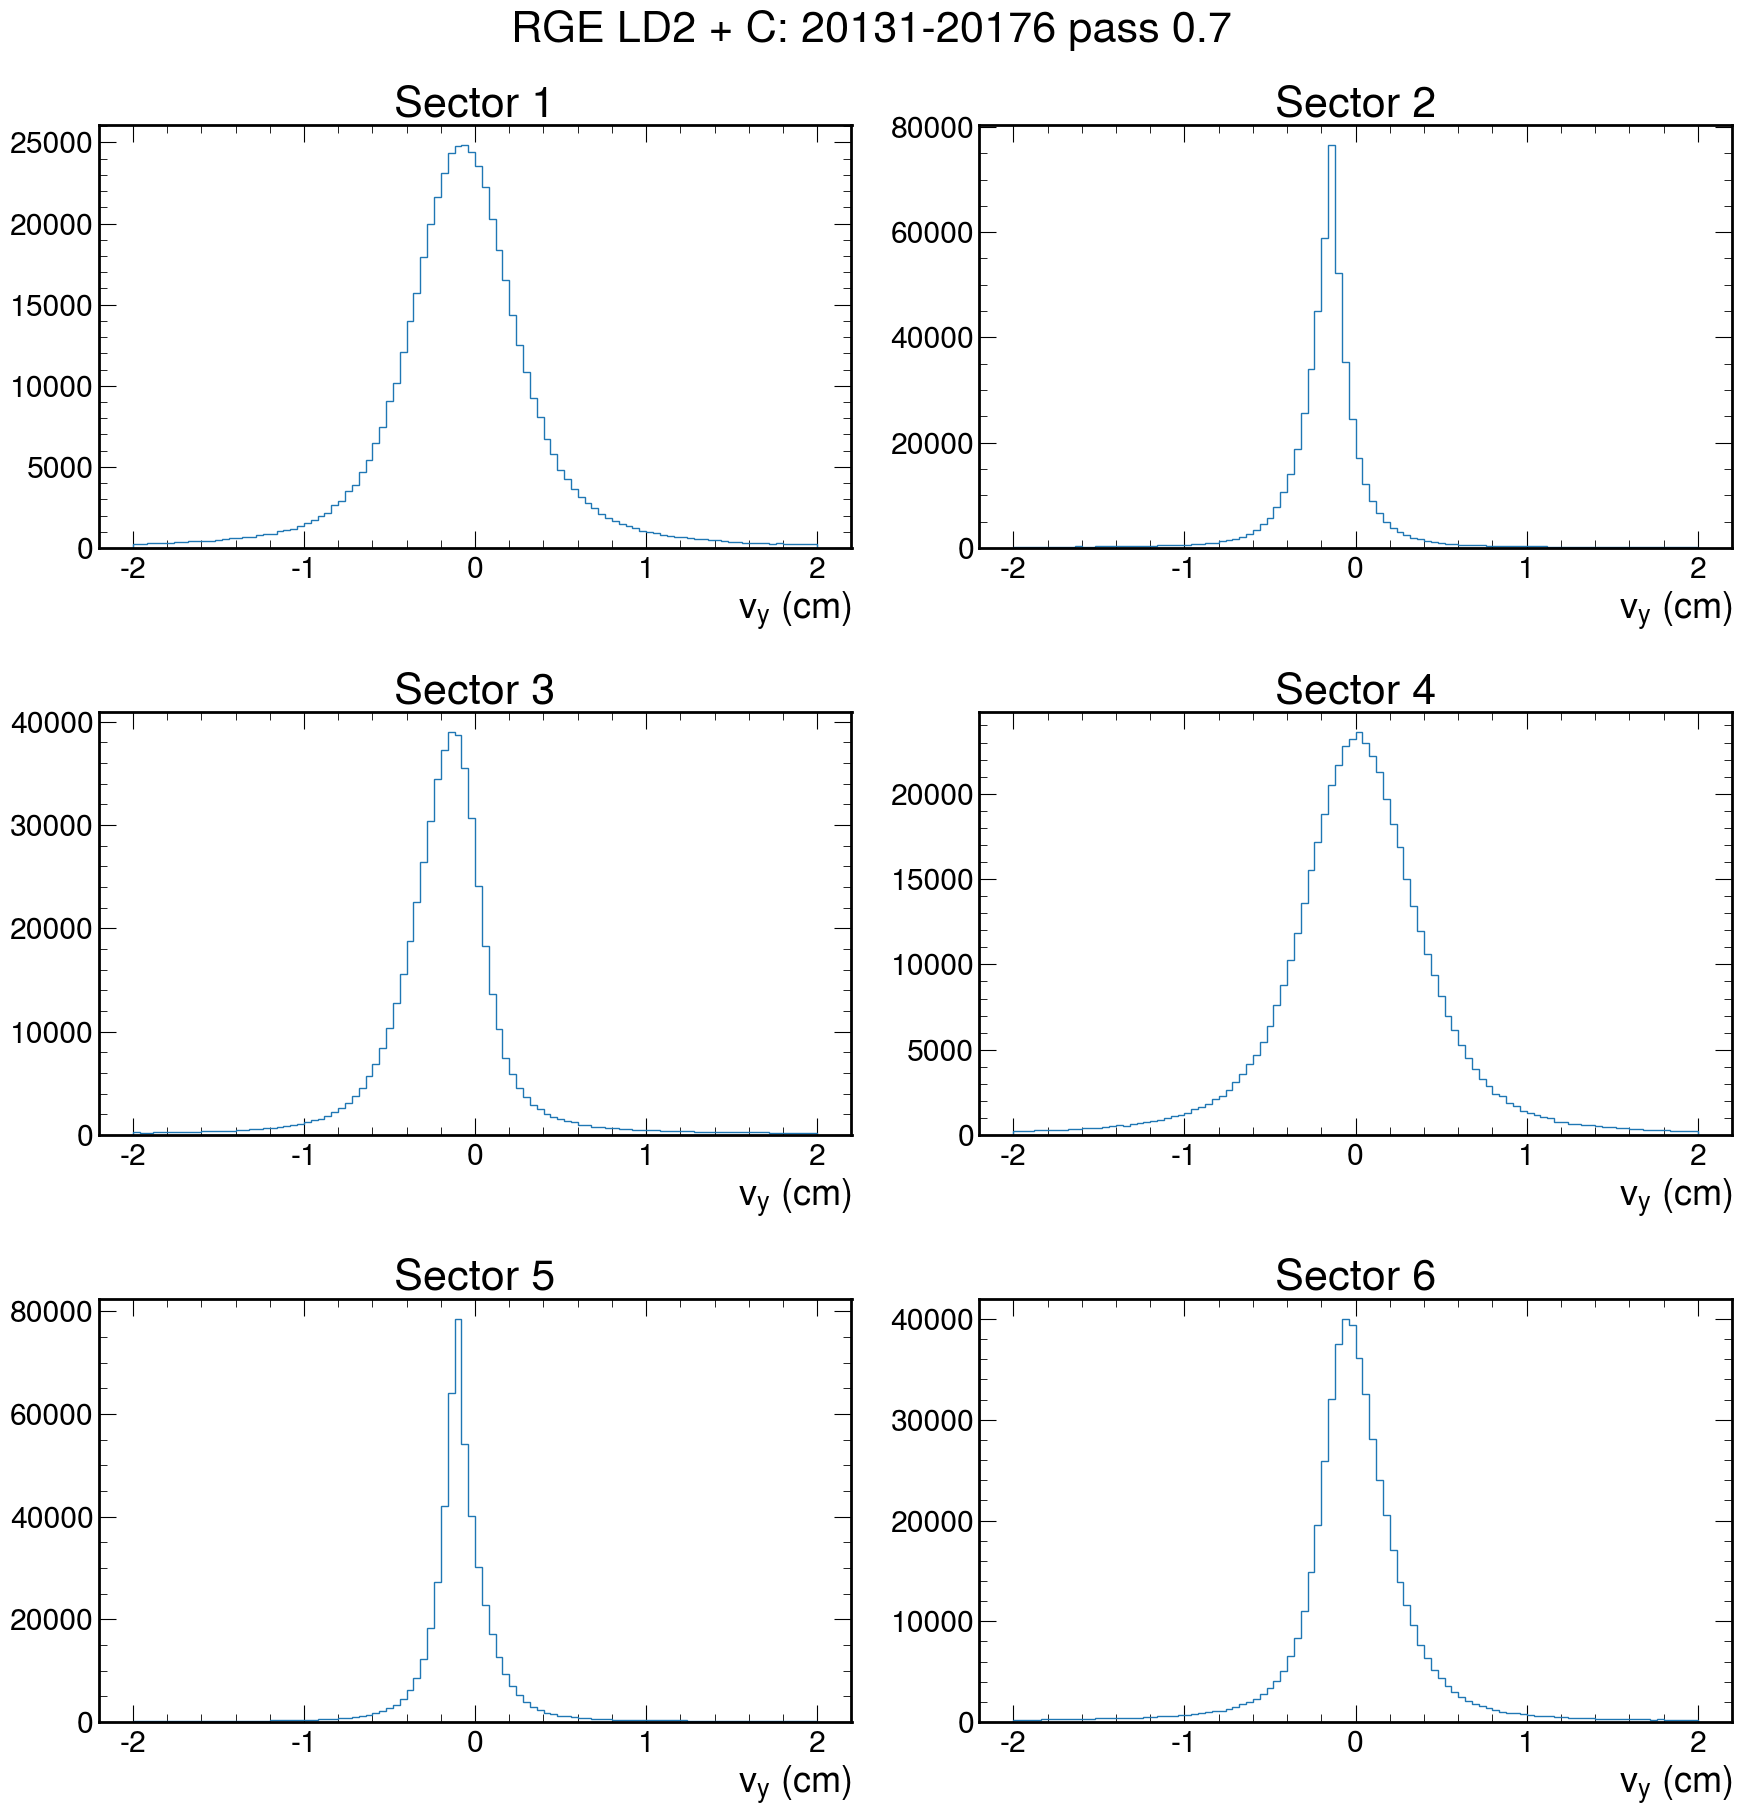

In [18]:
fig, axs = plt.subplots(3, 2, figsize=(18, 18))
axs = axs.flatten()
for sector in range(num_sectors):
    sector_cut = branches_dict["data"]["sector"]==(sector+1)
    
    vertex_y = np.array(branches_dict["data"]["v_y"][sector_cut])
    vertex_y_counts, vertex_y_bins, _ = axs[sector].hist(
        vertex_y,
        bins=100,
        range=(-2,2),
        histtype='step'
    )
    axs[sector].set_xlabel("$v_{y}$ (cm)")
    axs[sector].set_title(f"Sector {sector+1}") 
fig.tight_layout()
fig.suptitle(plot_title, y=1.02)

In [19]:
def double_gaussian(x, amp1, mean1, sigma1, amp2, mean2, sigma2):
    return amp1 * np.exp( -(x - mean1)**2 / (2*sigma1) ) + \
           amp2 * np.exp( -(x - mean2)**2 / (2*sigma2) )

27789.0
25994.0
27266.0
27563.0
25930.0
28172.0


Text(0.5, 1.02, 'RGE LD2 + C: 20131-20176 pass 0.7\n Electron candidates with vx,vy cut')

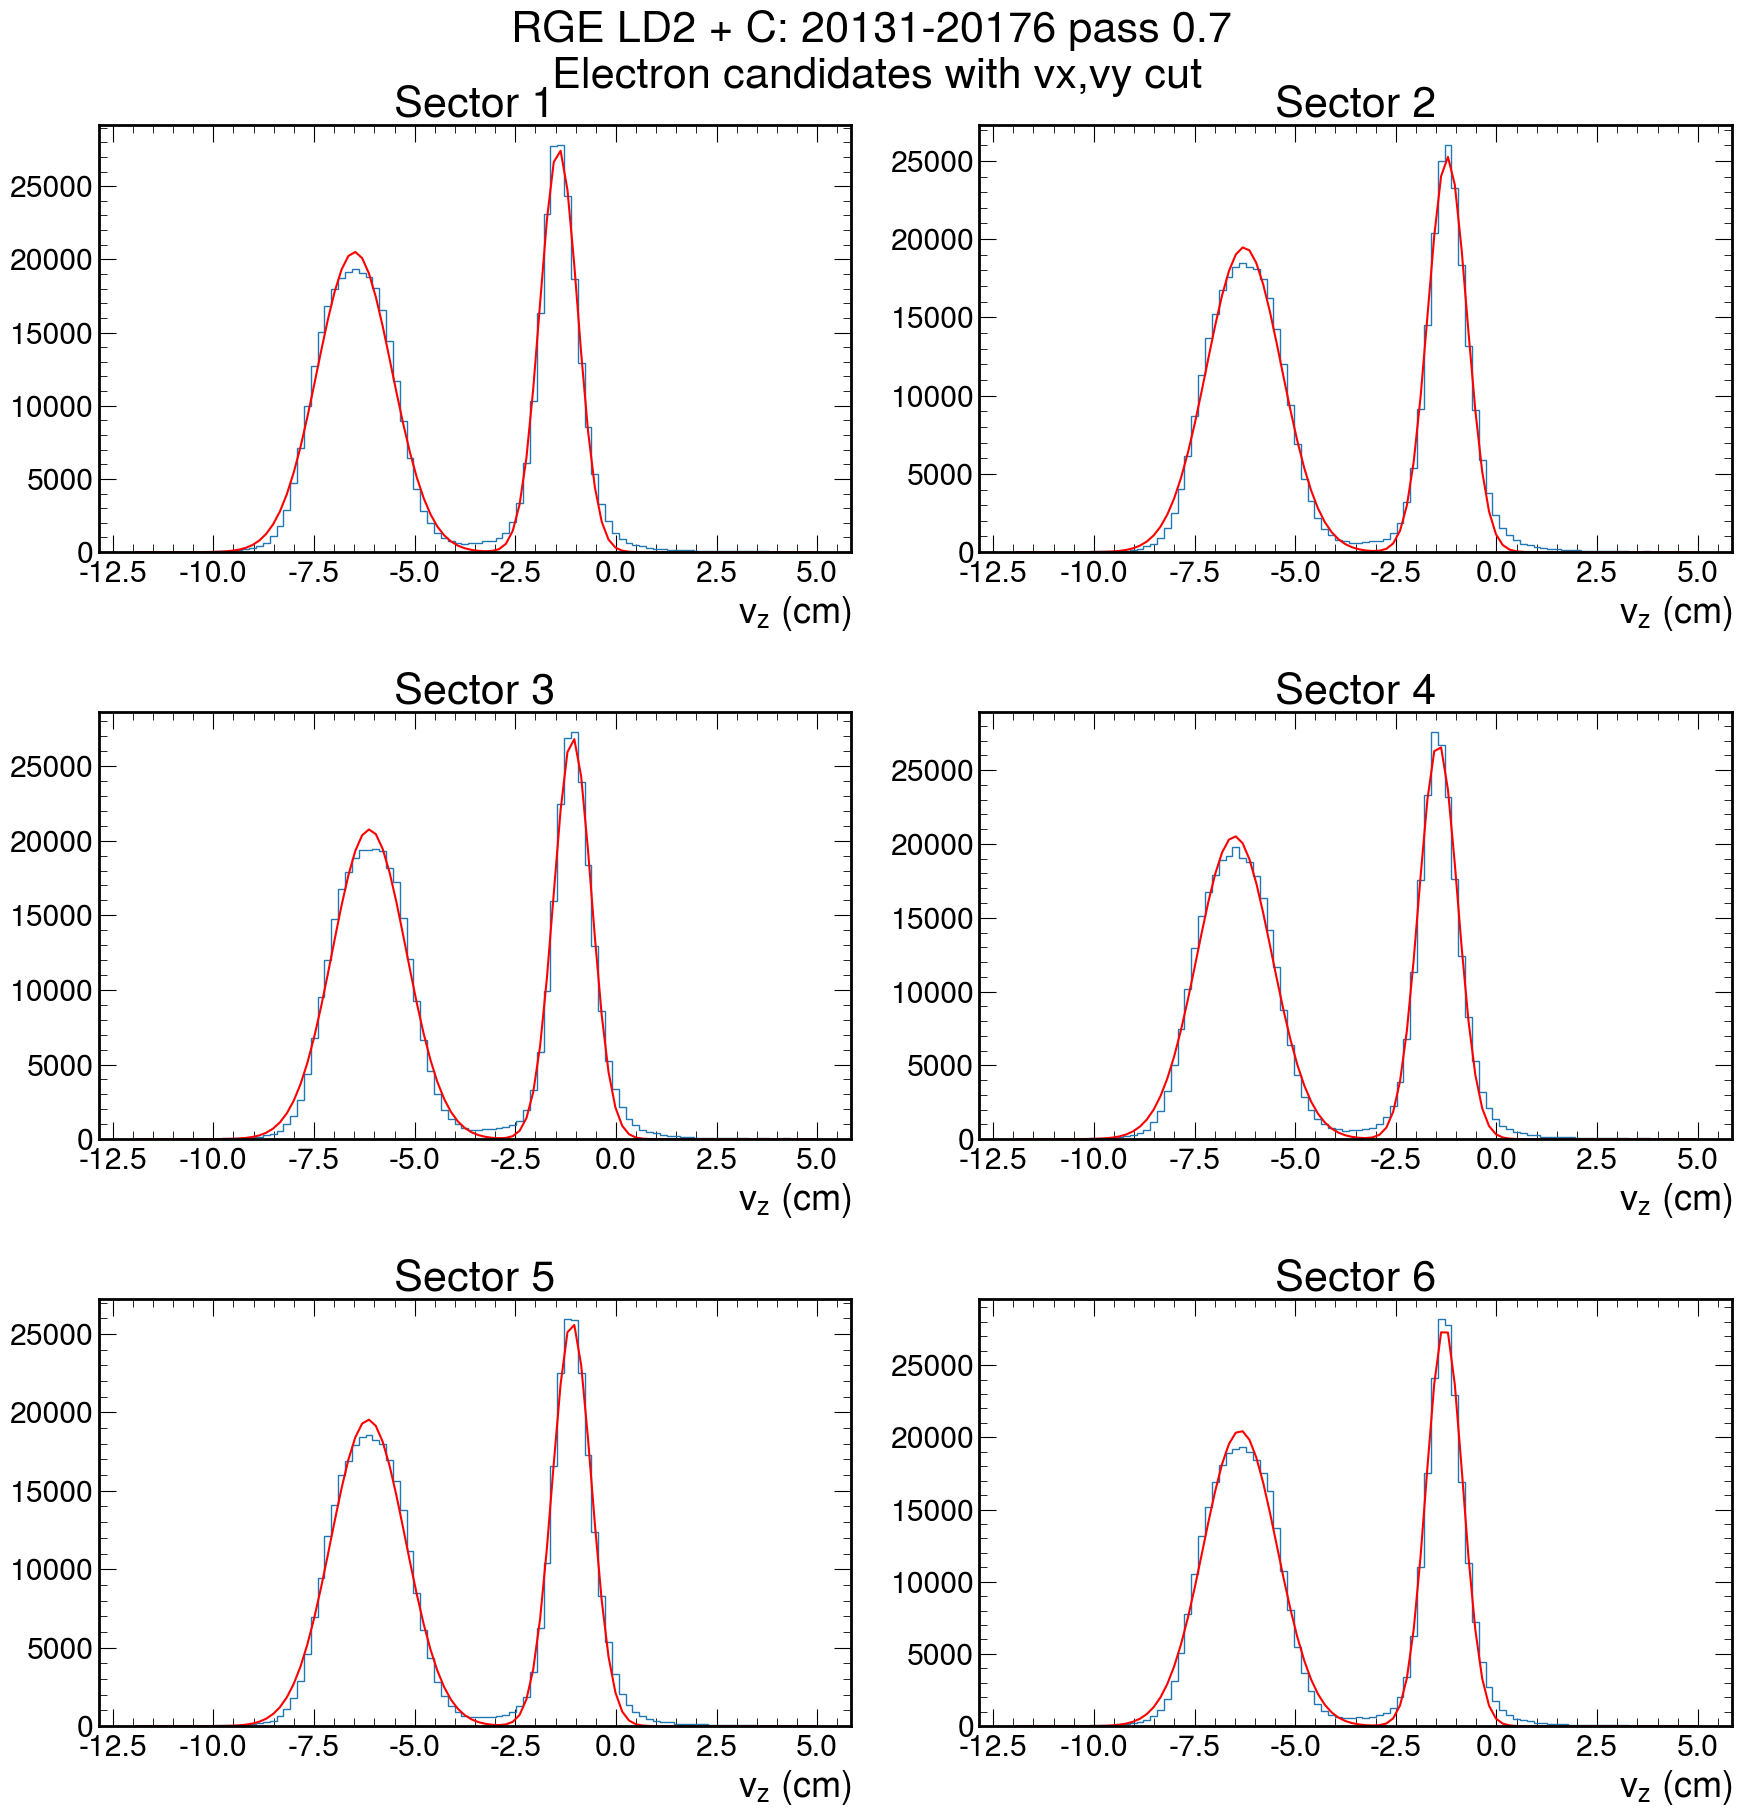

In [20]:
fig, axs = plt.subplots(3, 2, figsize=(18, 18))
axs = axs.flatten()
transverse_mask = np.sqrt(branches_dict["data"]["v_x"]**2 + branches_dict["data"]["v_y"]**2) < 1.2
num_sectors = 6
z_fit_parameters_all_sectors = []
for sector in range(num_sectors):
    sector_cut = branches_dict["data"][transverse_mask]["sector"]==(sector+1)
    
    vertex_z = np.array(branches_dict["data"]["v_z"][transverse_mask][sector_cut])
    vertex_z_counts, vertex_z_bins, _ = axs[sector].hist(
        vertex_z,
        bins=100,
        range=(-12,5),
        histtype='step'
    )
    vertex_z_bin_centers = (vertex_z_bins[:-1] + vertex_z_bins[1:])/2
    lower_fit_range = -12
    upper_fit_range = 12

    amplitude_guess = np.max(vertex_z_counts)
    mean_z_guess = ak.mean(vertex_z)
    std_z_guess = ak.std(vertex_z)
    
    print(amplitude_guess)
    z_fit_parameters, z_fit_covariance = curve_fit(double_gaussian,
                                                   vertex_z_bin_centers,
                                                   vertex_z_counts, 
                                                   p0=(amplitude_guess, -7, 2.5, amplitude_guess, -1.5, 1.5))
    y_fit = double_gaussian(vertex_z_bin_centers, *z_fit_parameters)
    z_fit_parameters_all_sectors.append(z_fit_parameters)
    axs[sector].plot(vertex_z_bin_centers, y_fit, color='r')
    axs[sector].set_xlabel("$v_{z}$ (cm)")
    axs[sector].set_title(f"Sector {sector+1}") 
    
fig.tight_layout()
fig.suptitle(plot_title+"\n Electron candidates with vx,vy cut", y=1.02)

[ 2.05083162e+04 -6.49322191e+00  8.59402732e-01  2.75616912e+04
 -1.42294222e+00  2.20764190e-01]
[ 1.94838966e+04 -6.26919711e+00  8.67975385e-01  2.52679417e+04
 -1.22097298e+00  2.35878176e-01]
[ 2.07587082e+04 -6.12577733e+00  8.44990278e-01  2.69154159e+04
 -1.07735041e+00  2.22674912e-01]
[ 2.05243097e+04 -6.50572732e+00  8.66344856e-01  2.68336229e+04
 -1.44708908e+00  2.33780241e-01]
[ 1.95388819e+04 -6.15406356e+00  8.63197383e-01  2.57667010e+04
 -1.09473581e+00  2.34894225e-01]
[ 2.04675690e+04 -6.36587136e+00  8.40647101e-01  2.77486805e+04
 -1.29092403e+00  2.05656455e-01]


Text(0.5, 1.02, 'RGE LD2 + C: 20131-20176 pass 0.7')

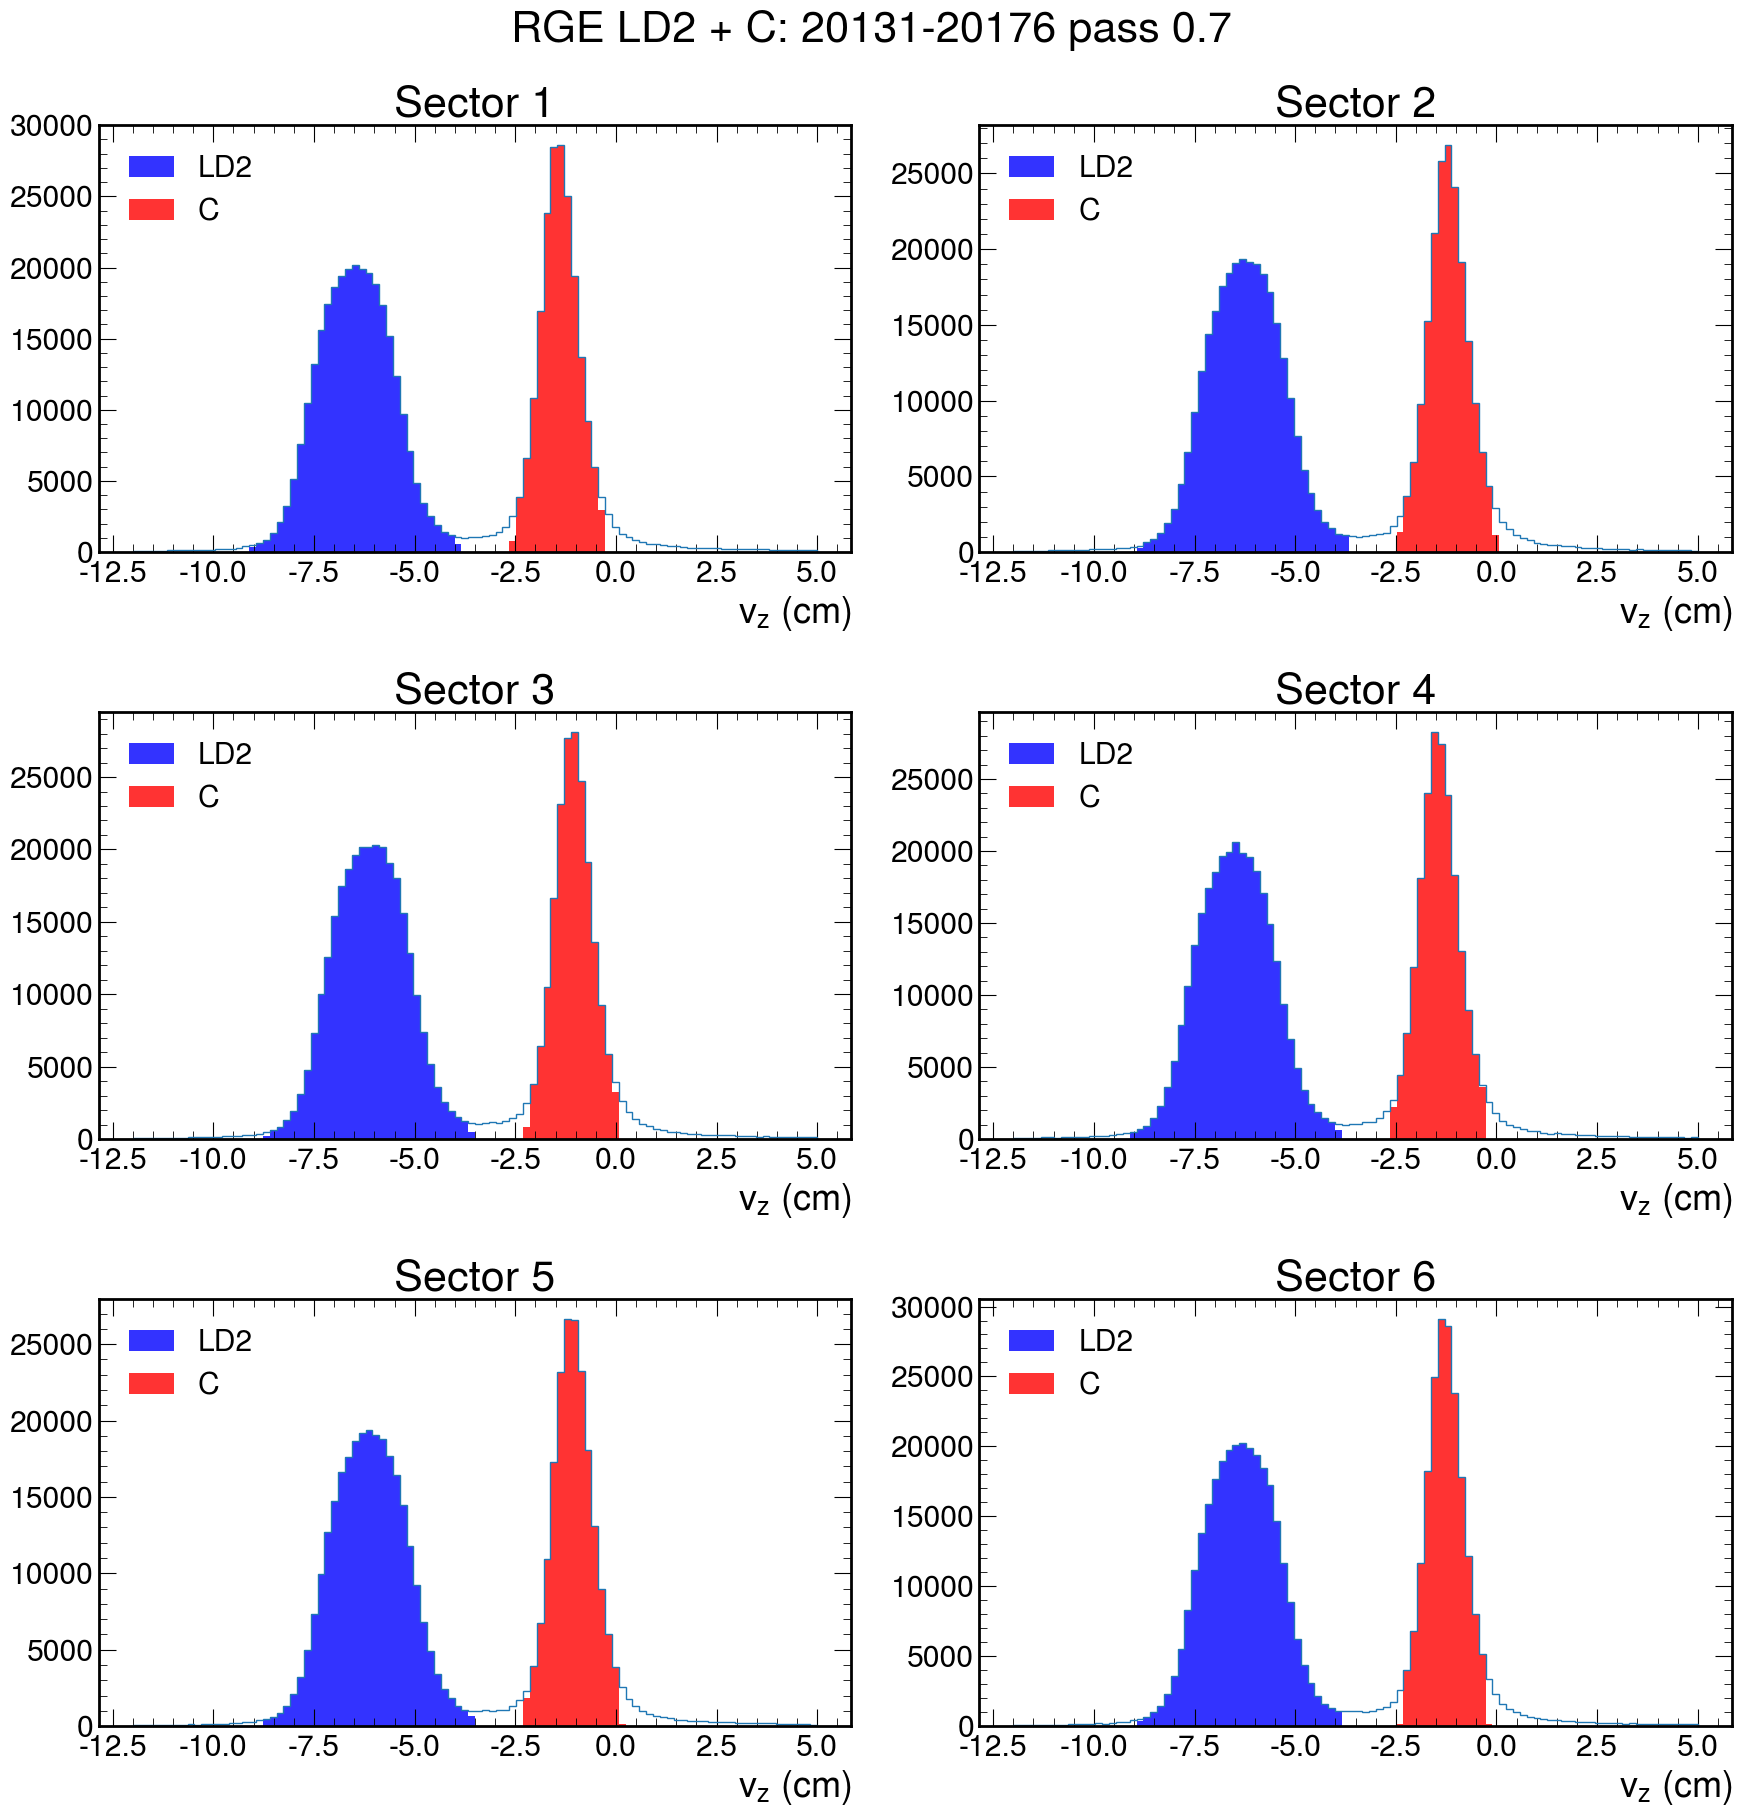

In [21]:
deuterium_mask_by_sector = []
solid_mask_by_sector = []
fig, axs = plt.subplots(3, 2, figsize=(18, 18))
axs = axs.flatten()
for sector in range(num_sectors):
    z_fit_parameters = z_fit_parameters_all_sectors[sector]
    print(z_fit_parameters)
    sector_cut = branches_dict["data"]["sector"]==(sector+1)
    
    vertex_z = np.array(branches_dict["data"]["v_z"][sector_cut])
    vertex_z_counts, vertex_z_bins, _ = axs[sector].hist(
        vertex_z,
        bins=100,
        range=(-12,5),
        histtype='step'
    )
    vertex_z_bin_centers = (vertex_z_bins[:-1] + vertex_z_bins[1:])/2
    deuterium_z_mean = min(z_fit_parameters[1], z_fit_parameters[4])
    if deuterium_z_mean == z_fit_parameters[1]:
        deuterium_z_sigma = z_fit_parameters[2]
        solid_z_mean, solid_z_sigma = z_fit_parameters[4], z_fit_parameters[5]
    elif deuterium_z_mean == z_fit_parameters[4]:
        deuterium_z_sigma = z_fit_parameters[5]
        solid_z_mean, solid_z_sigma = z_fit_parameters[1], z_fit_parameters[2]
    
    # 2 sigma cut was chosen arbitrarily. Just a first attempt that looks OK.
    deuterium_cut = (vertex_z > (deuterium_z_mean - 3 * deuterium_z_sigma) ) &\
                    (vertex_z < (deuterium_z_mean + 3 * deuterium_z_sigma) )
    solid_cut     = (vertex_z > (solid_z_mean - 5 * solid_z_sigma) ) &\
                    (vertex_z < (solid_z_mean + 5 * solid_z_sigma) )
    deuterium_mask_by_sector.append(deuterium_cut)
    solid_mask_by_sector.append(solid_cut)
    
    axs[sector].hist(vertex_z[deuterium_cut],
         bins = 100,
         range=(-12, 5),
         color='b',
         label="LD2",
         alpha=.8)
    axs[sector].hist(vertex_z[solid_cut],
             bins = 100,
             range=(-12, 5),
             color='r',
             label=solid_target,
             alpha=.8)
    
    axs[sector].set_xlabel("$v_{z}$ (cm)")
    axs[sector].set_title(f"Sector {sector+1}") 
    axs[sector].legend(loc='upper left')
fig.tight_layout()
fig.suptitle(plot_title, y=1.02)

In [22]:
masked_branches_by_sector = []
target_type_by_sector = []
for sector in range(num_sectors):
    sector_mask = branches_dict["data"]["sector"]==(sector+1)
    target_type = []
    for deuterium, solid in zip(deuterium_mask_by_sector[sector], solid_mask_by_sector[sector]):
        if deuterium:
            target_type.append("D2")
        elif solid:
            target_type.append(solid_target)
    target_type_by_sector.append(ak.Array(target_type))
    
    target_mask = (deuterium_mask_by_sector[sector] | solid_mask_by_sector[sector])
    masked_branches =  branches_dict["data"][sector_mask][target_mask]
    masked_branches_by_sector.append(masked_branches)
enriched_by_sector = [
    ak.with_field(data_array, target_array, where="target")
    for data_array, target_array in zip(masked_branches_by_sector, target_type_by_sector)
]

In [23]:
branches_dict["data"] = ak.concatenate(enriched_by_sector)

In [24]:
branches_dict = ak.Record(branches_dict)

In [25]:
print(len(branches_dict["data"]["Q2"]))

2889070


In [26]:
print(len(branches_dict["data"]["Q2"])/8583475*100)

33.65851243231908


In [27]:
solid_data = branches_dict["data"][branches_dict["data"]["target"] == solid_target]
deuterium_data = branches_dict["data"][branches_dict["data"]["target"] == "D2"]

dataframes = {}

dataframes[solid_target] =  ak.to_dataframe(solid_data)
dataframes["LD2"] =  ak.to_dataframe(deuterium_data)

In [28]:
sim_solid_data = branches_dict["sim"][branches_dict["sim"]["target"] == solid_target]
sim_deuterium_data = branches_dict["sim"][branches_dict["sim"]["target"] == "D2"]

sim_dataframes = {}

sim_dataframes[solid_target] =  ak.to_dataframe(sim_solid_data)
sim_dataframes["LD2"] =  ak.to_dataframe(sim_deuterium_data)

In [29]:
def get_acceptance_ratio(dataframes, solid_target, q="Q2<12 and x < 1 and x>0"):
    nA=len(dataframes[solid_target].query(q))
    nD=len(dataframes["LD2"].query(q))

    if nA!=0 and nD!=0:
        return nA/nD/lumonisity_ratios[solid_target], (nA/nD)*np.sqrt(1/nA+1/nD), nA, nD
    else :
        return 1, 10, 0, 0

In [30]:
print(get_acceptance_ratio(dataframes, solid_target))
print(get_acceptance_ratio(sim_dataframes, solid_target))

(0.8905759604617137, 0.0008019834692077102, 1156943, 1732127)
(1.3840021791457973, 0.0010844296743280932, 1867230, 1798870)


/tmp/ipykernel_337233/1882353645.py:41: RuntimeWarning: divide by zero encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
/tmp/ipykernel_337233/1882353645.py:41: RuntimeWarning: invalid value encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]


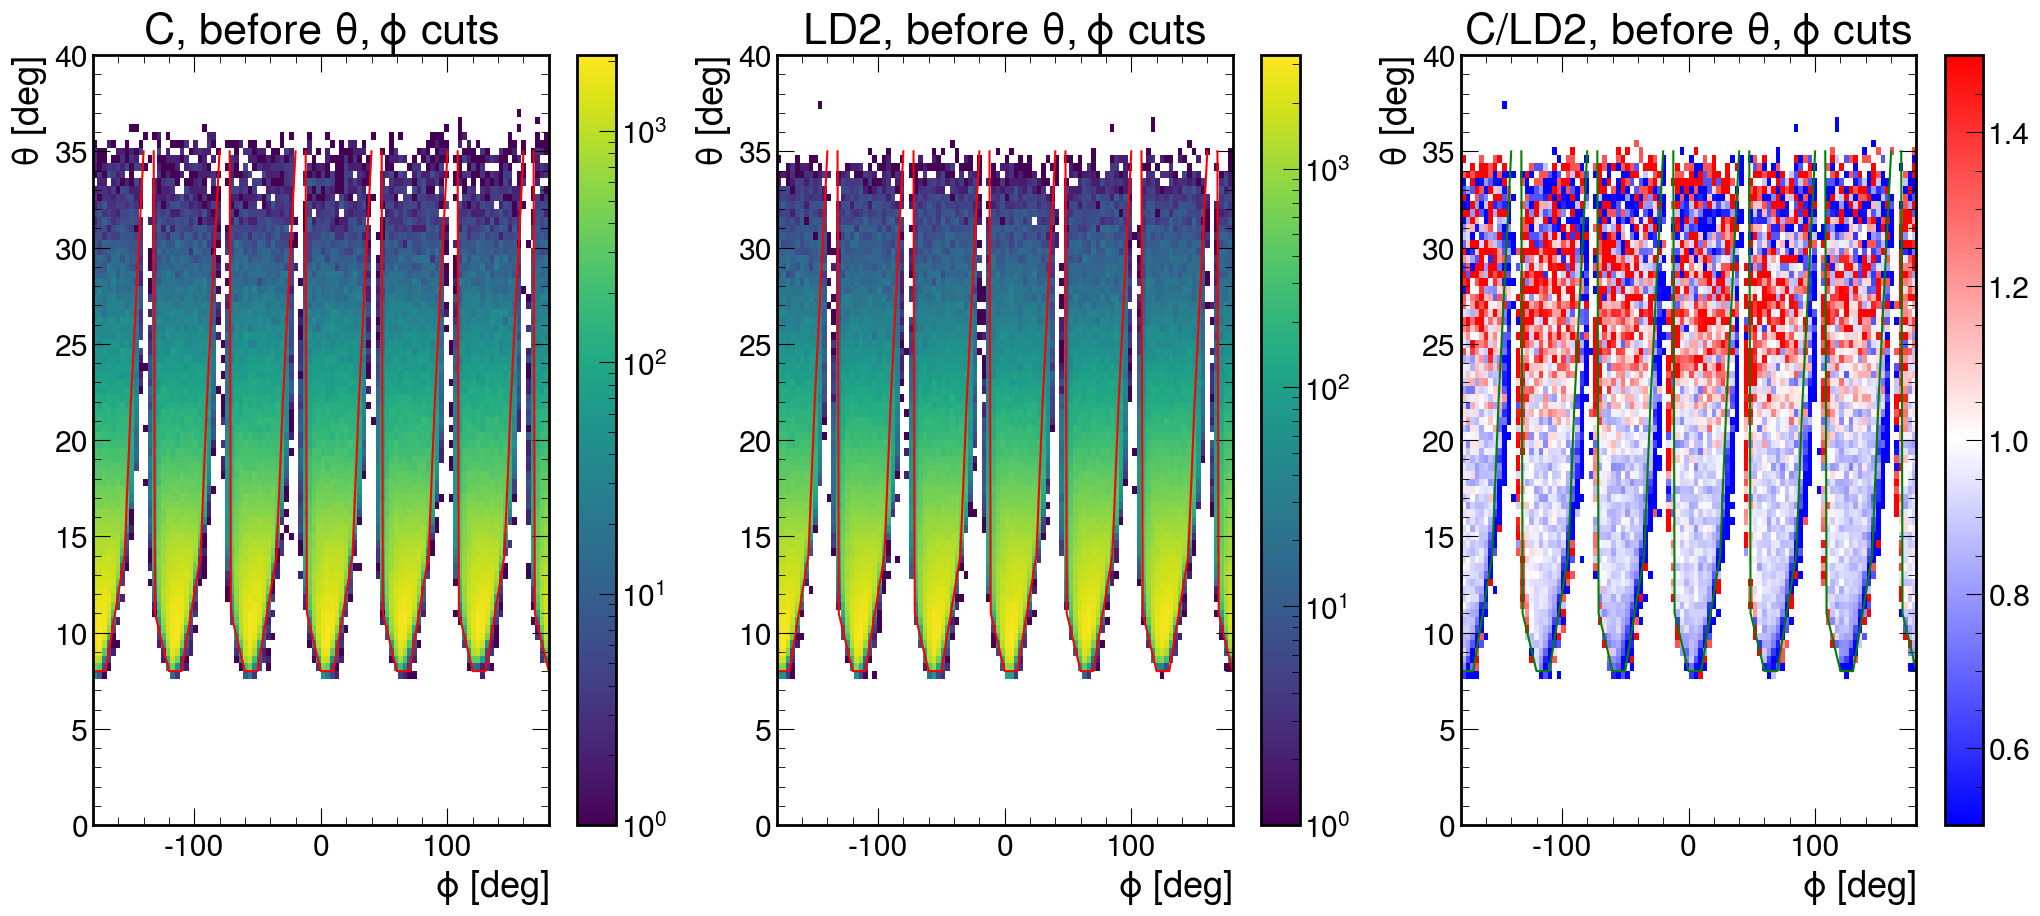

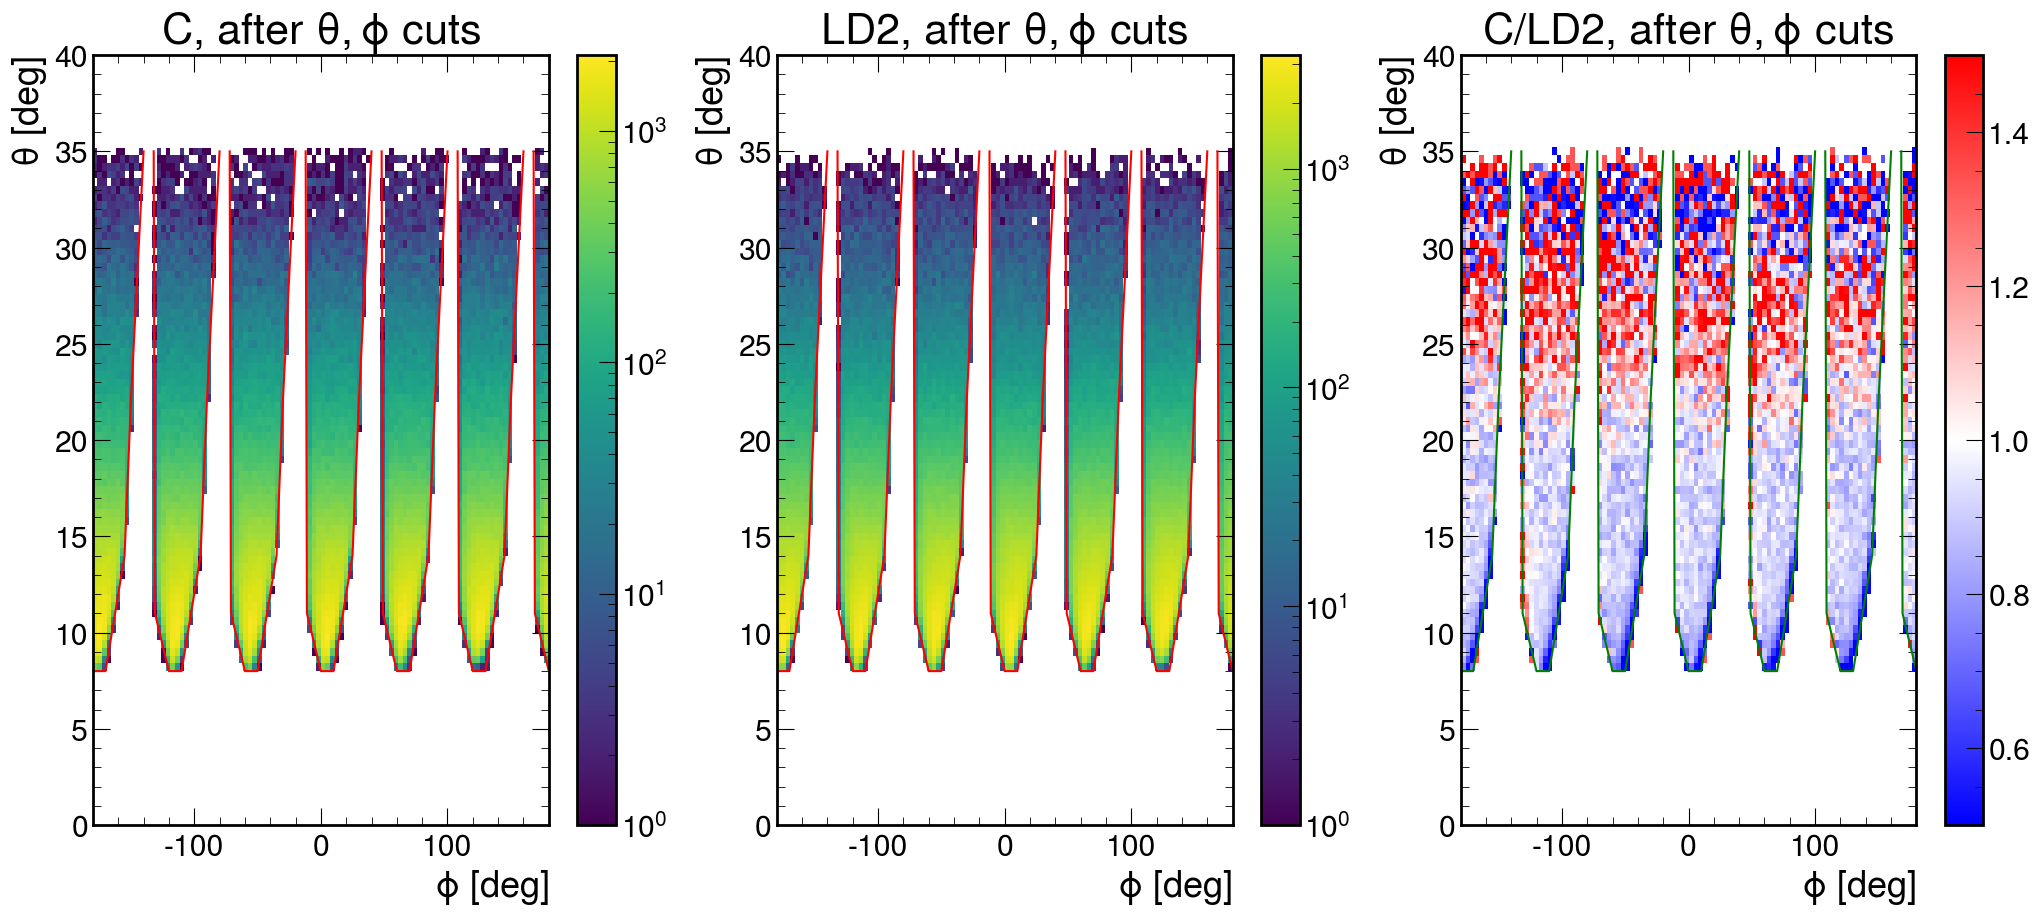

In [31]:
# These are points in the theta-phi space
# We connect these points together with lines
# For instance (-12, 35) to (-11, 11) is one line
# We then only keep points that are above/greater than these lines
# Basically defining a polygon and then only keeping points within that polygon
fid_cuts_phi=np.array([-12, -11, 0, 10, 20,25, 30,40])
fid_cuts_theta=np.array([35, 11, 8,8,12,14, 22,35])


fid_cuts=""
phip=f"(phi*{180/np.pi}+180+10)%60-10"
for i in range(len(fid_cuts_phi)-1):
    fid_cuts+=f" and theta*{180/np.pi}>{fid_cuts_theta[i]}+({phip}-{fid_cuts_phi[i]})/({fid_cuts_phi[i+1]-fid_cuts_phi[i]})*({fid_cuts_theta[i+1]-fid_cuts_theta[i]})"
fiducial_cuts="("+fid_cuts[5:]+f" and theta*{180/np.pi}<{fid_cuts_theta[0]})"

DIS_cuts ="W>2 and y<0.85"

for useFidCuts in False, True:
    hists={}
    fig, axs = plt.subplots(1,3, figsize=(25,10))
    
    for i, (target_name, target_data) in enumerate(dataframes.items()):
        plt.sca(axs[i])
        masked_dataframe = dataframes[target_name].query(DIS_cuts + " and " + fiducial_cuts) if useFidCuts else dataframes[target_name].query(DIS_cuts)
        hists[target_name] = plt.hist2d(
            masked_dataframe.phi*180/np.pi,
            masked_dataframe.theta*180/np.pi,
            bins=100, range=((-180, 180), (0, 40)),
            norm=mcolors.LogNorm()
        )
        # dfq=dfs[tar].query(q)
        for i in range(-3, 4):
            plt.plot(fid_cuts_phi+60*i, fid_cuts_theta, color='r')  
        plt.xlabel("$\\phi$ [deg]")
        plt.ylabel("$\\theta$ [deg]")  
        plt.title(target_name + (", before $\\theta,\\phi$ cuts" if not useFidCuts else ", after $\\theta,\\phi$ cuts"))
        plt.colorbar()
    
    # Create ratio plot
    plt.sca(axs[2])
    h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
    xedges, yedges= hists[solid_target][1:3]
    pc = plt.gca().pcolorfast(xedges, yedges, h.T, norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr'])
    plt.xlabel("$\\phi$ [deg]")
    plt.ylabel("$\\theta$ [deg]")  
    plt.title(f"{solid_target}/LD2"+ (", before $\\theta,\\phi$ cuts" if not useFidCuts else ", after $\\theta,\\phi$ cuts"))
    plt.xlim(-180,180)
    for i in range(-3, 4):
        plt.plot(fid_cuts_phi+60*i, fid_cuts_theta, color='g')  
    plt.colorbar(pc)
    plt.show()

/tmp/ipykernel_337233/2659566853.py:22: RuntimeWarning: divide by zero encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
/tmp/ipykernel_337233/2659566853.py:22: RuntimeWarning: invalid value encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]


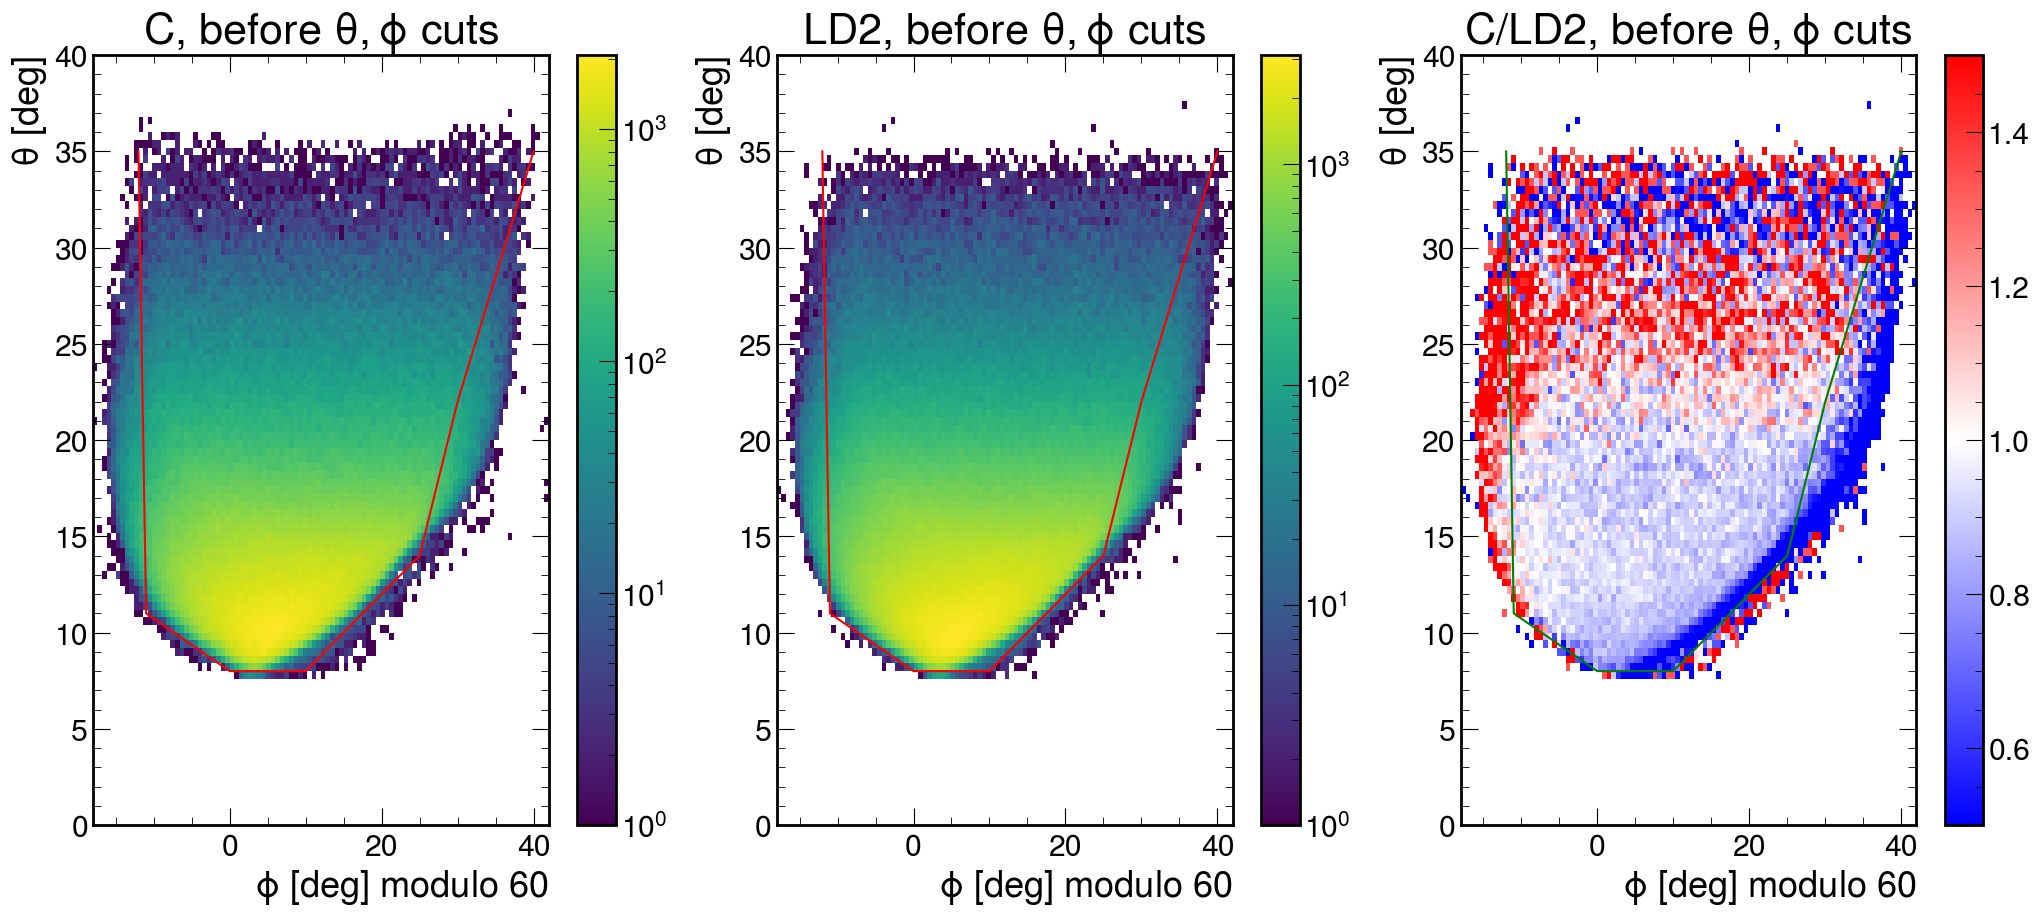

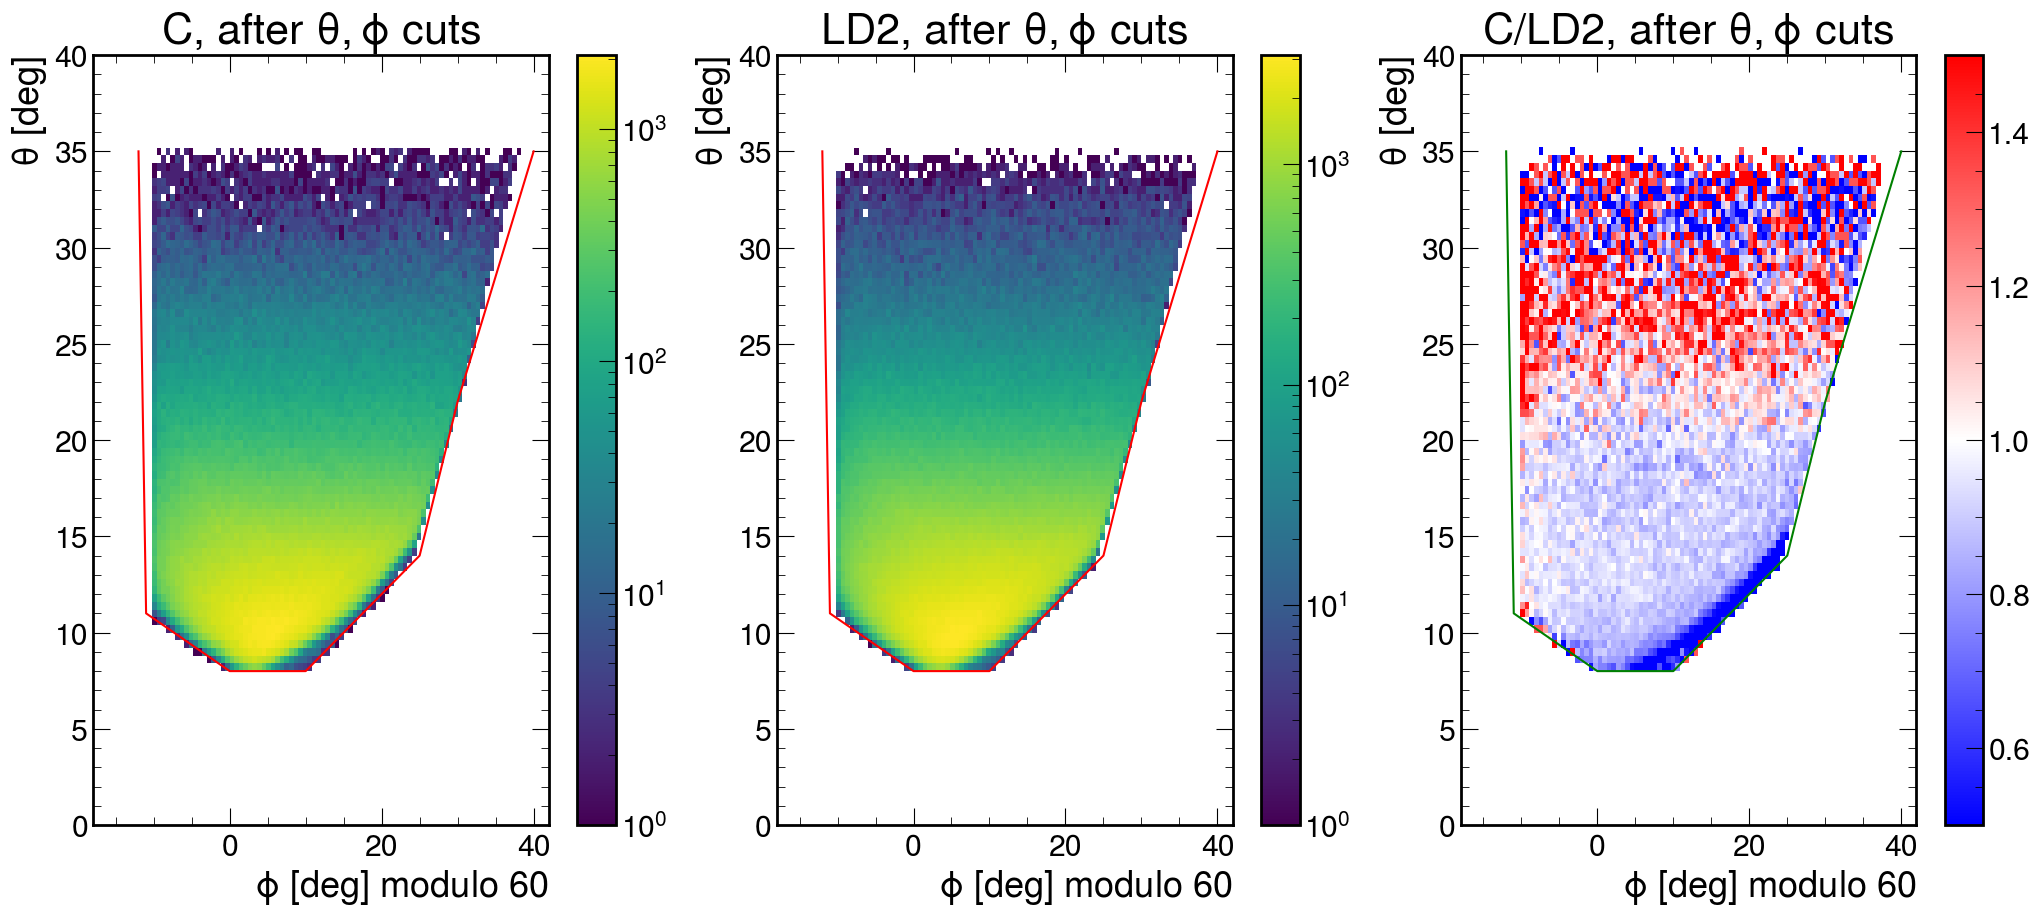

In [32]:
for useFidCuts in False, True:
    hists={}
    fig, axs = plt.subplots(1,3, figsize=(25,10))
    
    for i, (target_name, target_data) in enumerate(dataframes.items()):
        plt.sca(axs[i])
        masked_dataframe = dataframes[target_name].query(DIS_cuts + " and " + fiducial_cuts) if useFidCuts else dataframes[target_name].query(DIS_cuts)
        hists[target_name] = plt.hist2d(
            ((masked_dataframe.phi*180/np.pi+18)%60)-18,
            masked_dataframe.theta*180/np.pi, bins=100,
            range=((-18, 42), (0, 40)),
            norm=mcolors.LogNorm(),
        )
        plt.plot(fid_cuts_phi, fid_cuts_theta, color='r')  
        plt.xlabel("$\\phi$ [deg] modulo 60")
        plt.ylabel("$\\theta$ [deg]")  
        plt.title(target_name + (", before $\\theta,\\phi$ cuts" if not useFidCuts else ", after $\\theta,\\phi$ cuts"))
        plt.colorbar()
    
    # Create ratio plot
    plt.sca(axs[2])
    h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
    xedges, yedges= hists[solid_target][1:3]
    pc = plt.gca().pcolorfast(xedges, yedges, h.T, norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr'])
    plt.xlabel("$\\phi$ [deg] modulo 60")
    plt.ylabel("$\\theta$ [deg]")  
    plt.title(f"{solid_target}/LD2"+ (", before $\\theta,\\phi$ cuts" if not useFidCuts else ", after $\\theta,\\phi$ cuts"))
    plt.plot(fid_cuts_phi, fid_cuts_theta, color='g')  
    plt.colorbar(pc)
    plt.show()

/tmp/ipykernel_337233/2170270323.py:30: RuntimeWarning: divide by zero encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
/tmp/ipykernel_337233/2170270323.py:30: RuntimeWarning: invalid value encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]


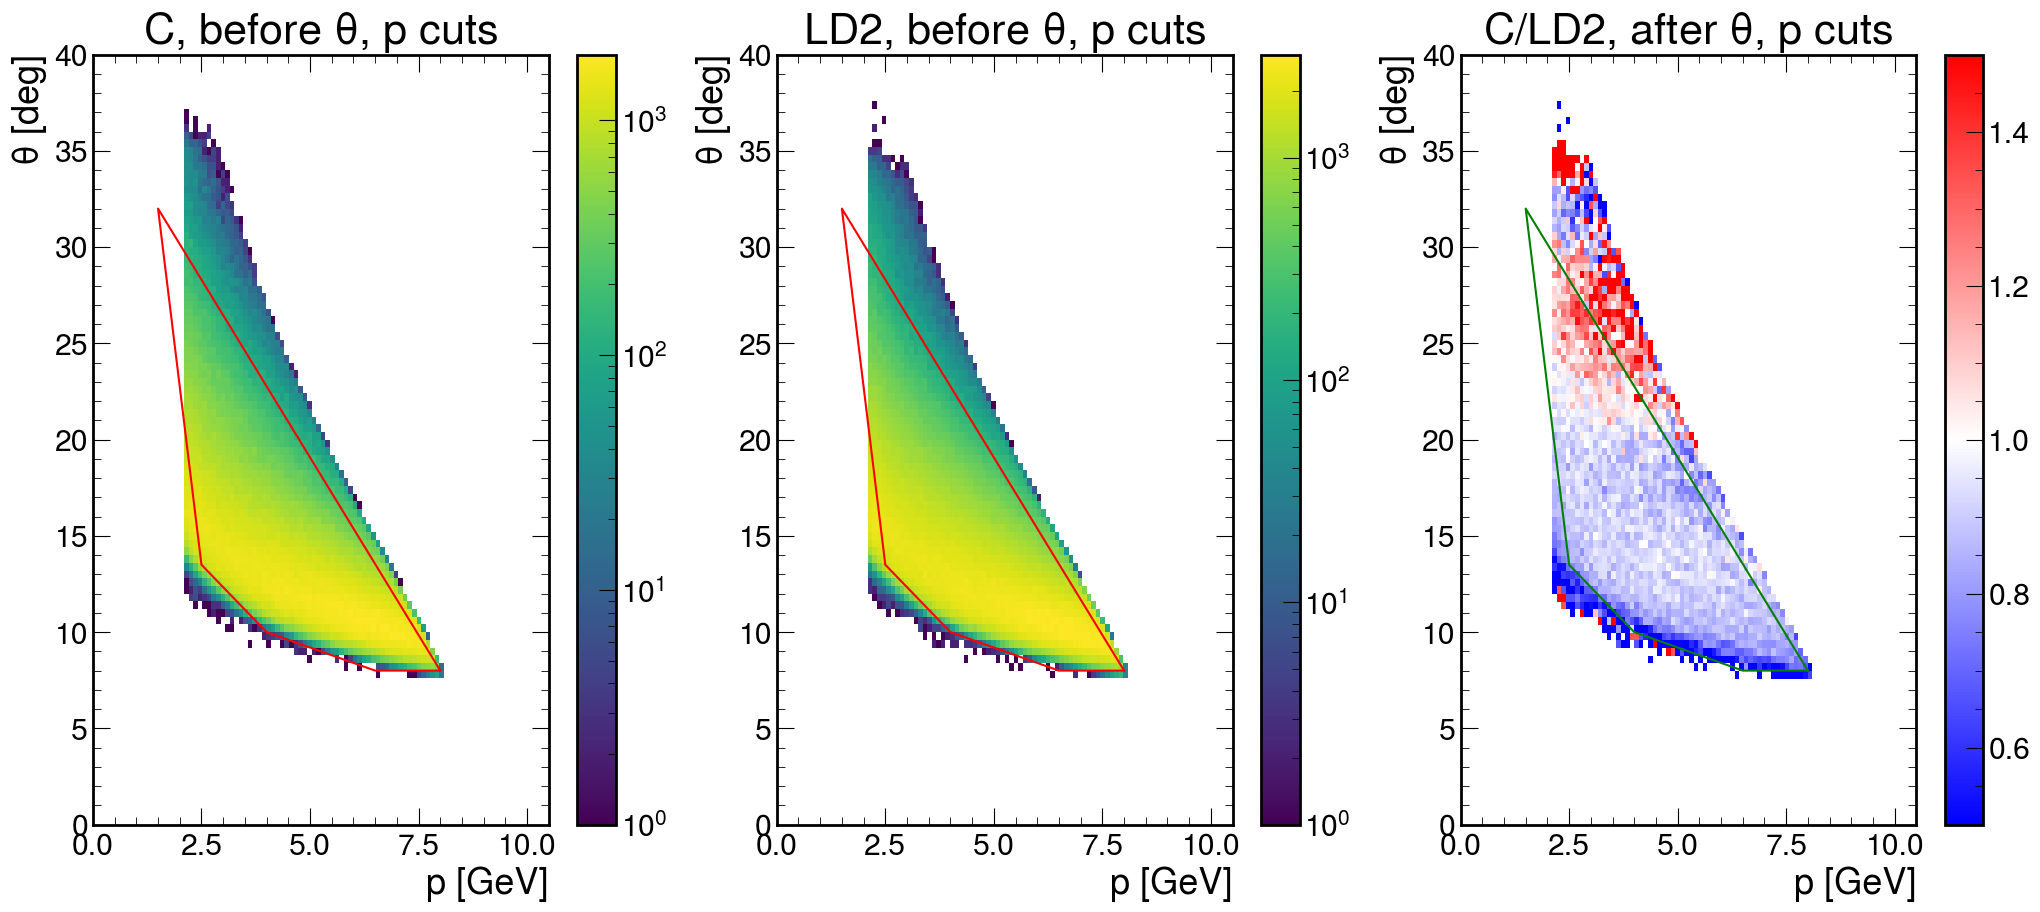

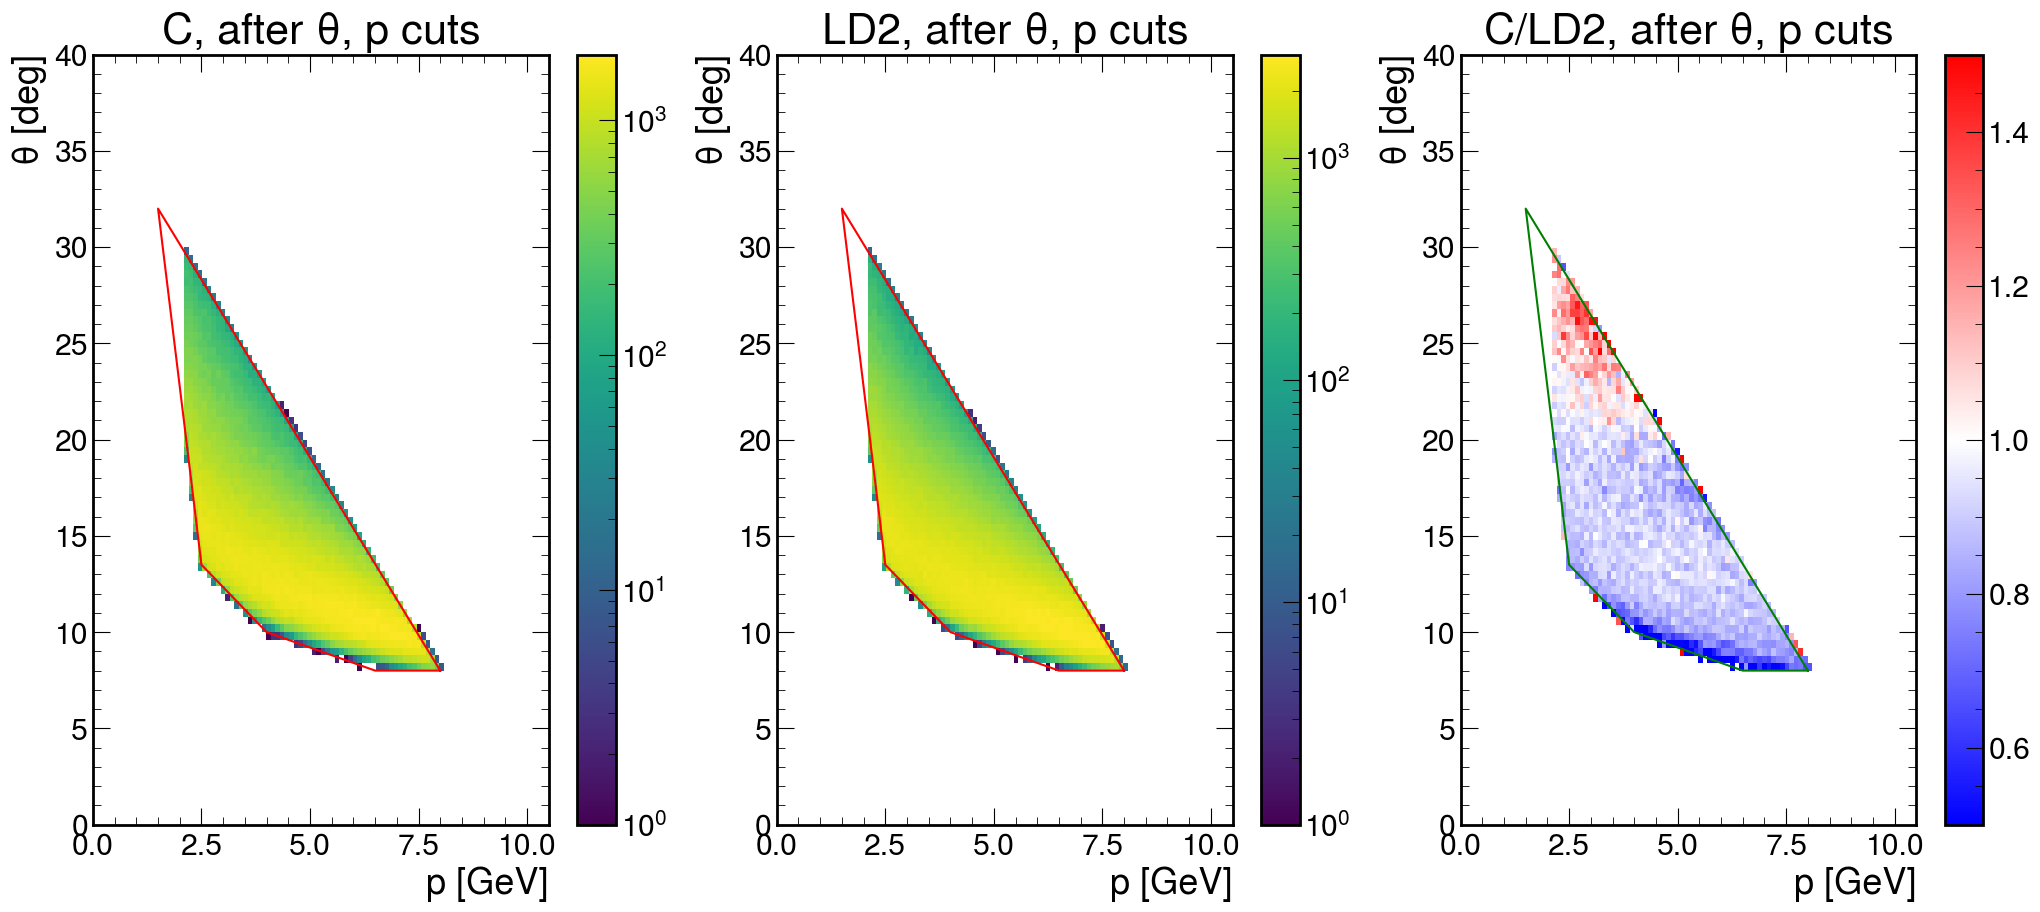

In [33]:
kin_cuts_p=[8, 6.5, 4, 2.5, 1.5, 8]
kin_cuts_theta=[8,8,10, 13.5,32, 8]
kin_cuts=""
for i in range(len(kin_cuts_p)-1):
    kin_cuts+=f" and ({kin_cuts_p[i+1]-kin_cuts_p[i]})*(theta*{180/np.pi}-{kin_cuts_theta[i]})<+(p-{kin_cuts_p[i]})*({kin_cuts_theta[i+1]-kin_cuts_theta[i]})"
kin_cuts = kin_cuts[5:]

for useKineticCuts in False, True:
    hists={}
    fig, axs = plt.subplots(1,3, figsize=(25,10))
    
    for i, (target_name, target_data) in enumerate(dataframes.items()):
        plt.sca(axs[i])
        masked_dataframe = dataframes[target_name].query(DIS_cuts + " and " + kin_cuts) if useKineticCuts else dataframes[target_name].query(DIS_cuts)
        hists[target_name] = plt.hist2d(
            masked_dataframe.p,
            masked_dataframe.theta*180/np.pi,
            bins=100,
            range=((0, 10.5), (0, 40)),
            norm = mcolors.LogNorm(),
        )
        plt.plot(kin_cuts_p, kin_cuts_theta, color='r')  
        plt.xlabel("p [GeV]")
        plt.ylabel("$\\theta$ [deg]")  
        plt.title(target_name + (", before $\\theta$, p cuts" if not useKineticCuts else ", after $\\theta$, p cuts"))
        plt.colorbar()
    
    # Create ratio plot
    plt.sca(axs[2])
    h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
    xedges, yedges= hists[solid_target][1:3]
    pc = plt.gca().pcolorfast(xedges, yedges, h.T, norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr'])
    plt.xlabel("p [GeV]")
    plt.ylabel("$\\theta$ [deg]")  
    plt.title(f"{solid_target}/LD2"+ (", before $\\theta$, p cuts" if not useFidCuts else ", after $\\theta$, p cuts"))
    plt.plot(kin_cuts_p, kin_cuts_theta, color='g')  
    plt.colorbar(pc)
    plt.show()

/tmp/ipykernel_337233/709586965.py:22: RuntimeWarning: divide by zero encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
/tmp/ipykernel_337233/709586965.py:22: RuntimeWarning: invalid value encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]


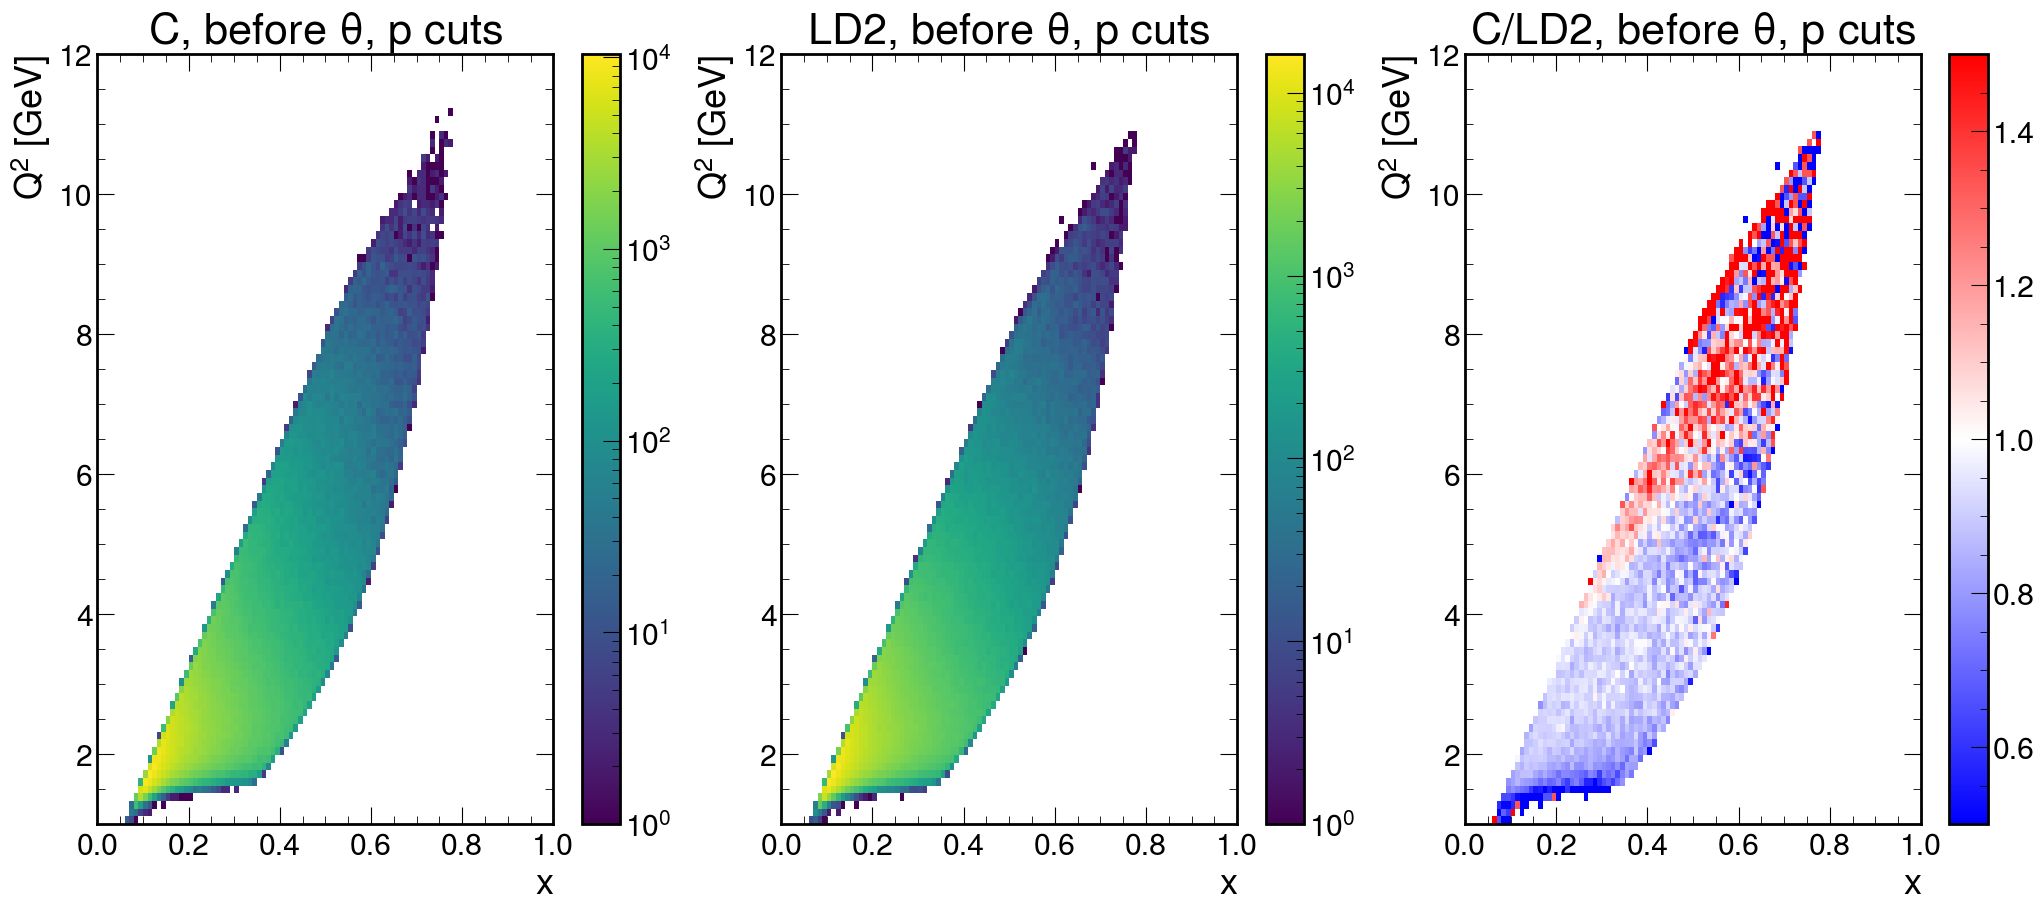

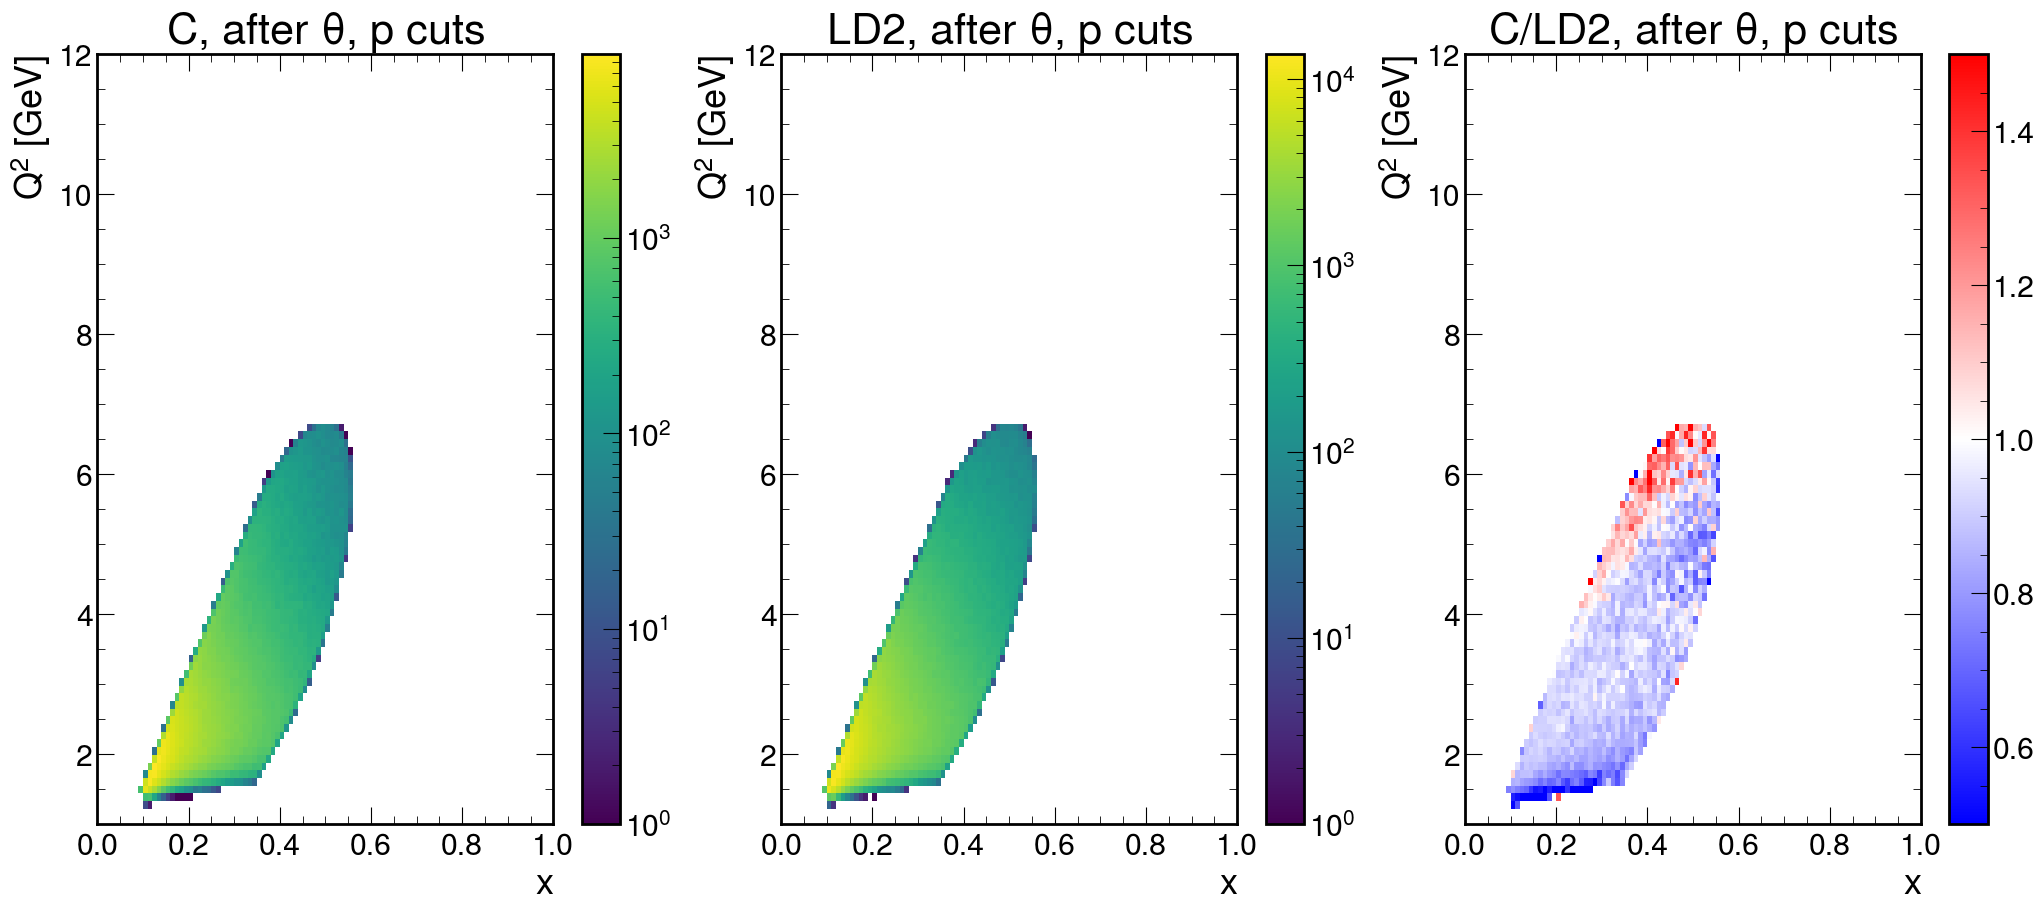

In [34]:
for useKineticCuts in False, True:
    hists={}
    fig, axs = plt.subplots(1,3, figsize=(25,10))
    
    for i, (target_name, target_data) in enumerate(dataframes.items()):
        plt.sca(axs[i])
        masked_dataframe = dataframes[target_name].query(DIS_cuts + " and " + kin_cuts) if useKineticCuts else dataframes[target_name].query(DIS_cuts)
        hists[target_name] = plt.hist2d(
            masked_dataframe.x,
            masked_dataframe.Q2,
            bins=100, range=((0, 1),(1,12)),
            norm = mcolors.LogNorm(),
        )
        plt.plot(kin_cuts_p, kin_cuts_theta, color='r')  
        plt.xlabel("x")
        plt.ylabel("$Q^2$ [GeV]")  
        plt.title(target_name + (", before $\\theta$, p cuts" if not useKineticCuts else ", after $\\theta$, p cuts"))
        plt.colorbar()
    
    # Create ratio plot
    plt.sca(axs[2])
    h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
    xedges, yedges= hists[solid_target][1:3]
    pc = plt.gca().pcolorfast(xedges, yedges, h.T, norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr'])
    plt.xlabel("x")
    plt.ylabel("$Q^2$ [GeV]")  
    plt.title(f"{solid_target}/LD2"+ (", before $\\theta$, p cuts" if not useKineticCuts else ", after $\\theta$, p cuts"))
    plt.colorbar(pc)
    plt.show()

/tmp/ipykernel_337233/709586965.py:22: RuntimeWarning: divide by zero encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
/tmp/ipykernel_337233/709586965.py:22: RuntimeWarning: invalid value encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]


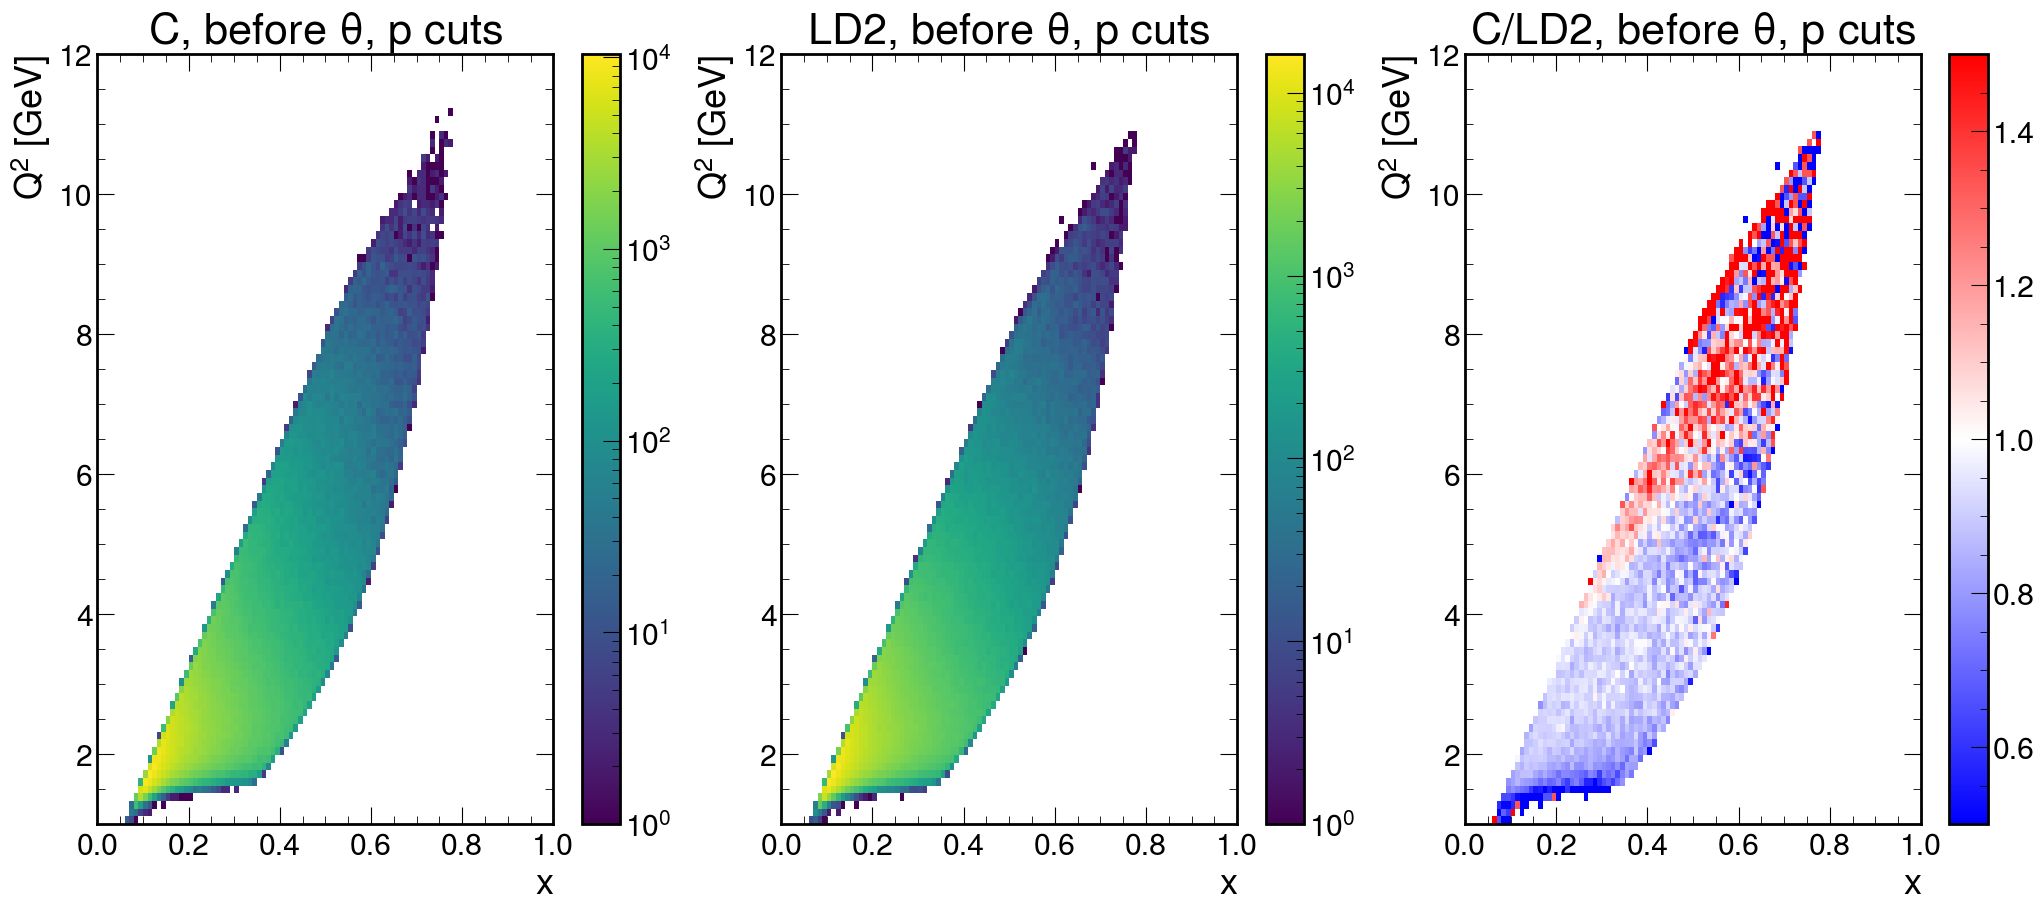

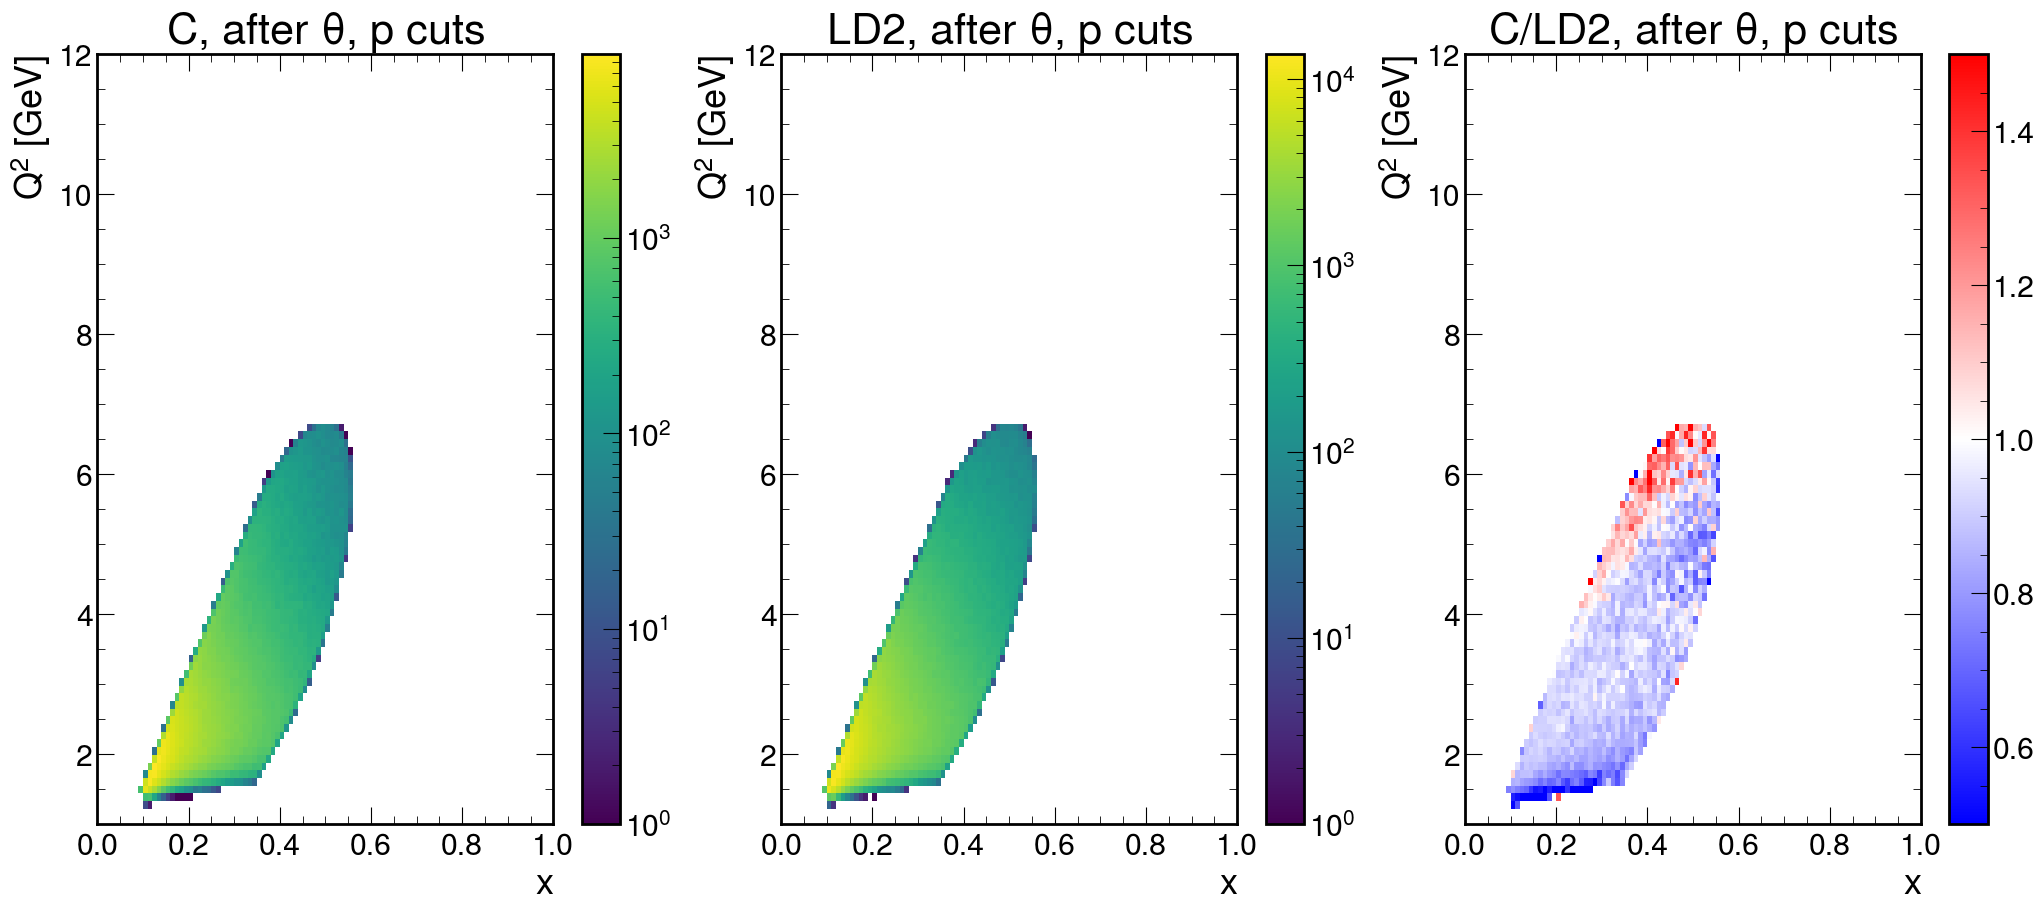

In [35]:
for useKineticCuts in False, True:
    hists={}
    fig, axs = plt.subplots(1,3, figsize=(25,10))
    
    for i, (target_name, target_data) in enumerate(dataframes.items()):
        plt.sca(axs[i])
        masked_dataframe = dataframes[target_name].query(DIS_cuts + " and " + kin_cuts) if useKineticCuts else dataframes[target_name].query(DIS_cuts)
        hists[target_name] = plt.hist2d(
            masked_dataframe.x,
            masked_dataframe.Q2,
            bins=100, range=((0, 1),(1,12)),
            norm = mcolors.LogNorm(),
        )
        plt.plot(kin_cuts_p, kin_cuts_theta, color='r')  
        plt.xlabel("x")
        plt.ylabel("$Q^2$ [GeV]")  
        plt.title(target_name + (", before $\\theta$, p cuts" if not useKineticCuts else ", after $\\theta$, p cuts"))
        plt.colorbar()
    
    # Create ratio plot
    plt.sca(axs[2])
    h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
    xedges, yedges= hists[solid_target][1:3]
    pc = plt.gca().pcolorfast(xedges, yedges, h.T, norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr'])
    plt.xlabel("x")
    plt.ylabel("$Q^2$ [GeV]")  
    plt.title(f"{solid_target}/LD2"+ (", before $\\theta$, p cuts" if not useKineticCuts else ", after $\\theta$, p cuts"))
    plt.colorbar(pc)
    plt.show()

/tmp/ipykernel_337233/1872492541.py:22: RuntimeWarning: divide by zero encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
/tmp/ipykernel_337233/1872492541.py:22: RuntimeWarning: invalid value encountered in divide
  h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]


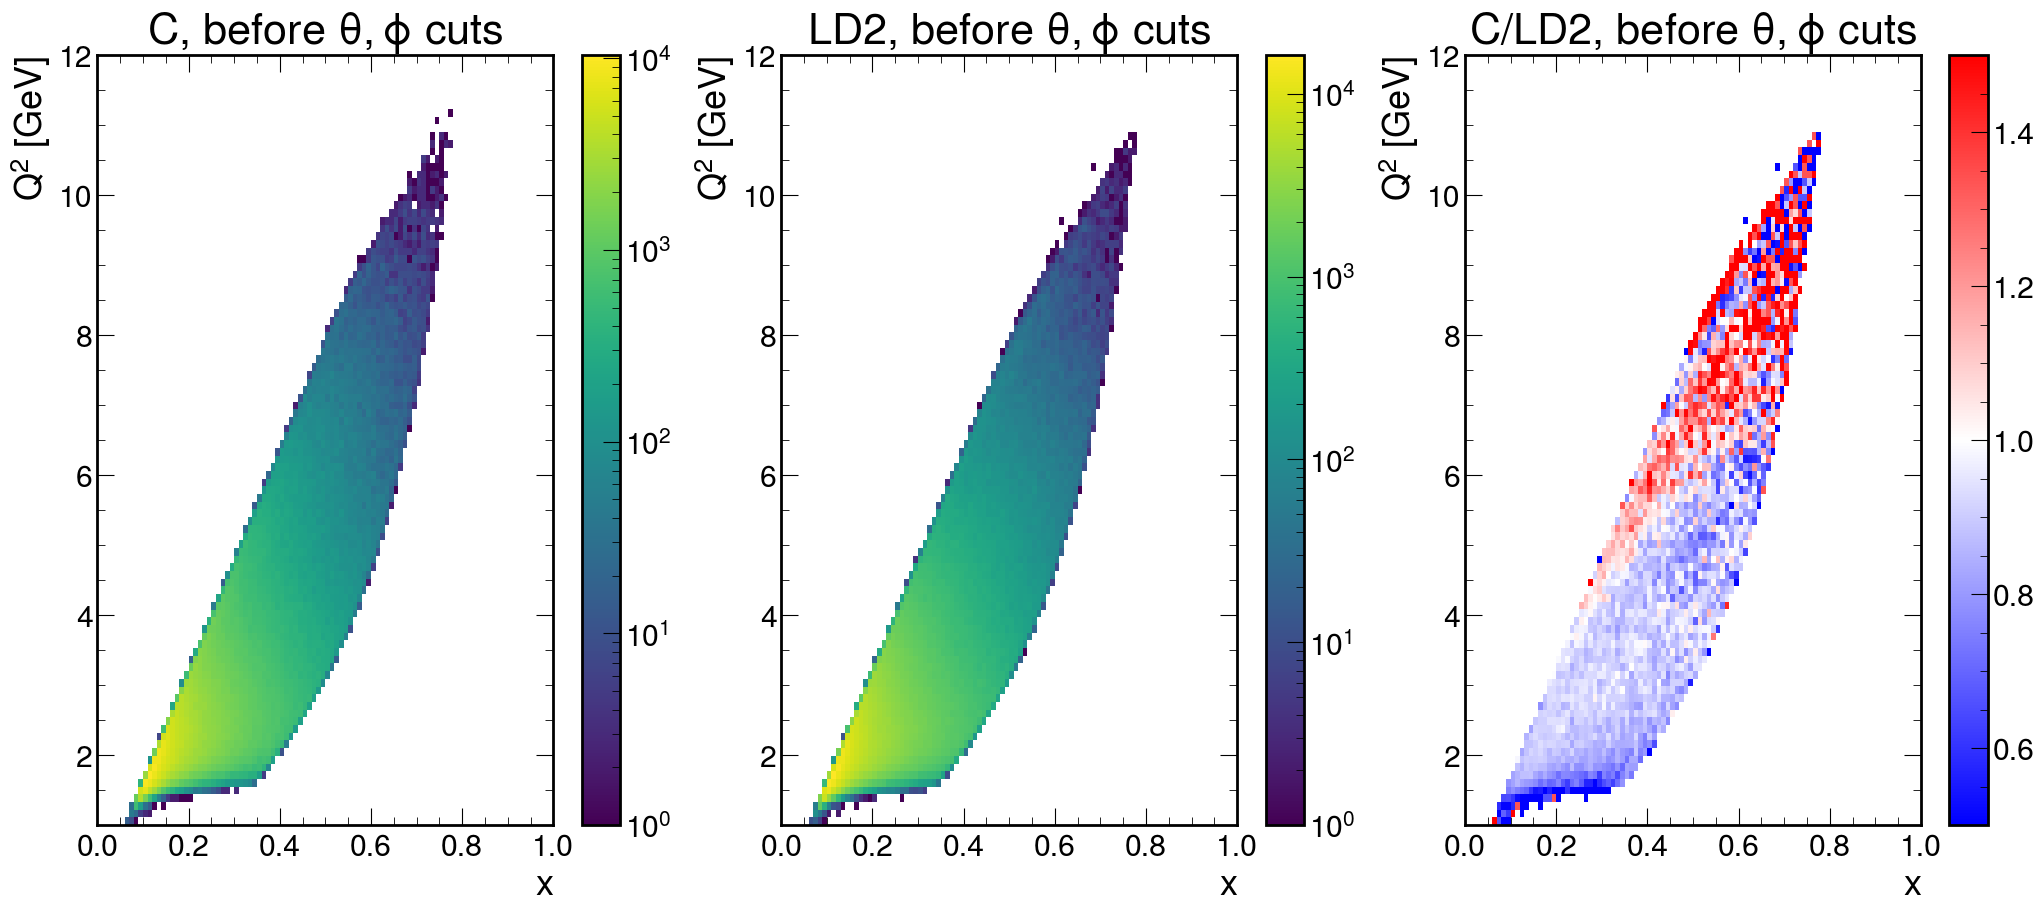

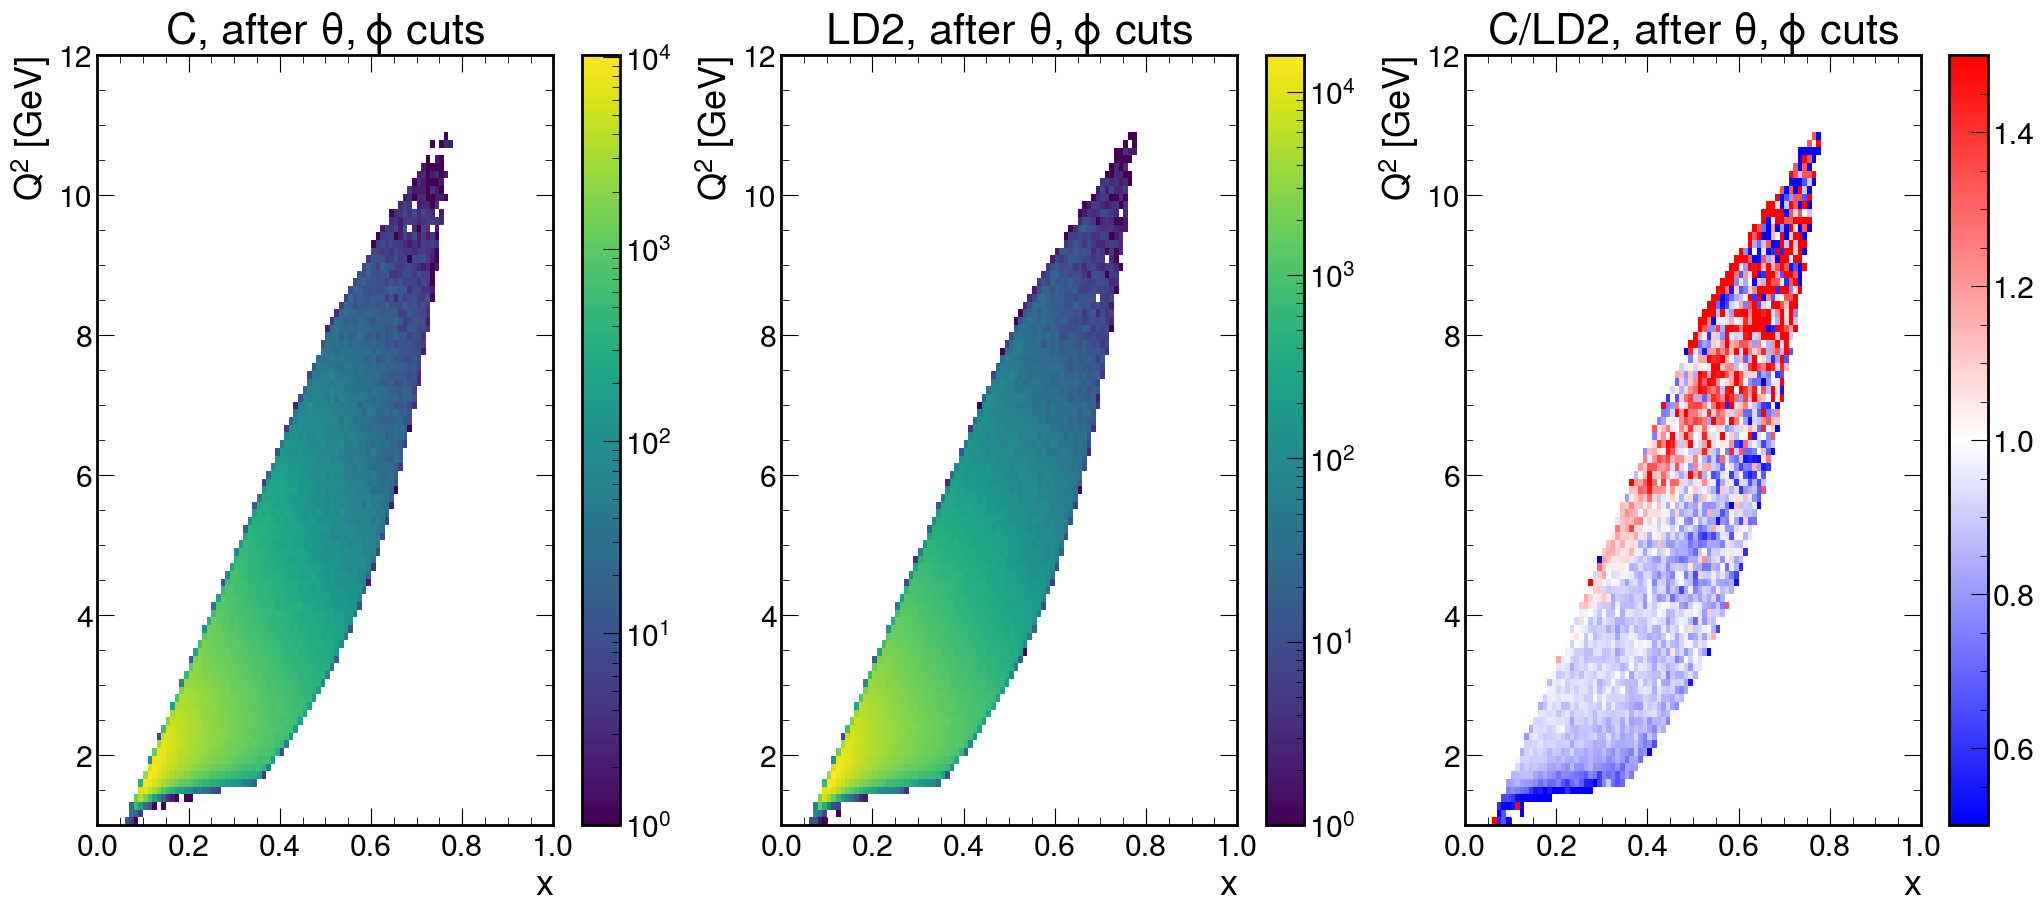

In [36]:
for useFiducialCuts in False, True:
    hists={}
    fig, axs = plt.subplots(1,3, figsize=(25,10))
    
    for i, (target_name, target_data) in enumerate(dataframes.items()):
        plt.sca(axs[i])
        masked_dataframe = dataframes[target_name].query(DIS_cuts + " and " + fiducial_cuts) if useFiducialCuts else dataframes[target_name].query(DIS_cuts)
        hists[target_name] = plt.hist2d(
            masked_dataframe.x,
            masked_dataframe.Q2,
            bins=100,
            range=((0, 1),(1,12)),
            norm = mcolors.LogNorm()
        )
        plt.xlabel("x")
        plt.ylabel("$Q^2$ [GeV]")  
        plt.title(target_name + (", before $\\theta,\\phi$ cuts" if not useFiducialCuts else ", after $\\theta,\\phi$ cuts"))
        plt.colorbar()
    
    # Create ratio plot
    plt.sca(axs[2])
    h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target]
    xedges, yedges= hists[solid_target][1:3]
    pc = plt.gca().pcolorfast(xedges, yedges, h.T, norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr'])
    plt.xlabel("x")
    plt.ylabel("$Q^2$ [GeV]")  
    plt.title(f"{solid_target}/LD2"+ (", before $\\theta,\\phi$ cuts" if not useFiducialCuts else ", after $\\theta,\\phi$ cuts"))
    plt.colorbar(pc)
    plt.show()

### Dividing data and simulation

In [53]:
num_Q2_bins = 100
num_x_bins= 100
Q2_bin_edges = np.linspace(1,12,num=100)
x_bin_edges = np.linspace(0, 1, num=100)
x_bin_centers = (x_bin_edges[:-1] + x_bin_edges[1:])/2
Q2_bin_centers = (Q2_bin_edges[:-1] + Q2_bin_edges[1:])/2


# Values of the bin centers in 2d histogram format
x_padded, Q2_padded = np.meshgrid(x_bin_centers, Q2_bin_centers)
# Taking transpose gives x constant along inner dimension, Q2 varies along inner dimension
x_padded = x_padded.T
Q2_padded = Q2_padded.T

x bin centers:  [0.00505051 0.01515152 0.02525253 0.03535354 0.04545455 0.05555556
 0.06565657 0.07575758 0.08585859 0.0959596  0.10606061 0.11616162
 0.12626263 0.13636364 0.14646465 0.15656566 0.16666667 0.17676768
 0.18686869 0.1969697  0.20707071 0.21717172 0.22727273 0.23737374
 0.24747475 0.25757576 0.26767677 0.27777778 0.28787879 0.2979798
 0.30808081 0.31818182 0.32828283 0.33838384 0.34848485 0.35858586
 0.36868687 0.37878788 0.38888889 0.3989899  0.40909091 0.41919192
 0.42929293 0.43939394 0.44949495 0.45959596 0.46969697 0.47979798
 0.48989899 0.5        0.51010101 0.52020202 0.53030303 0.54040404
 0.55050505 0.56060606 0.57070707 0.58080808 0.59090909 0.6010101
 0.61111111 0.62121212 0.63131313 0.64141414 0.65151515 0.66161616
 0.67171717 0.68181818 0.69191919 0.7020202  0.71212121 0.72222222
 0.73232323 0.74242424 0.75252525 0.76262626 0.77272727 0.78282828
 0.79292929 0.8030303  0.81313131 0.82323232 0.83333333 0.84343434
 0.85353535 0.86363636 0.87373737 0.88383838 0.8

Data 1156943.0
Data 1732127.0


/tmp/ipykernel_337233/2583940470.py:39: RuntimeWarning: divide by zero encountered in divide
  ratio_hist = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target] if data_name == "Data" else hists[solid_target][0] / hists['LD2'][0]
/tmp/ipykernel_337233/2583940470.py:39: RuntimeWarning: invalid value encountered in divide
  ratio_hist = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target] if data_name == "Data" else hists[solid_target][0] / hists['LD2'][0]


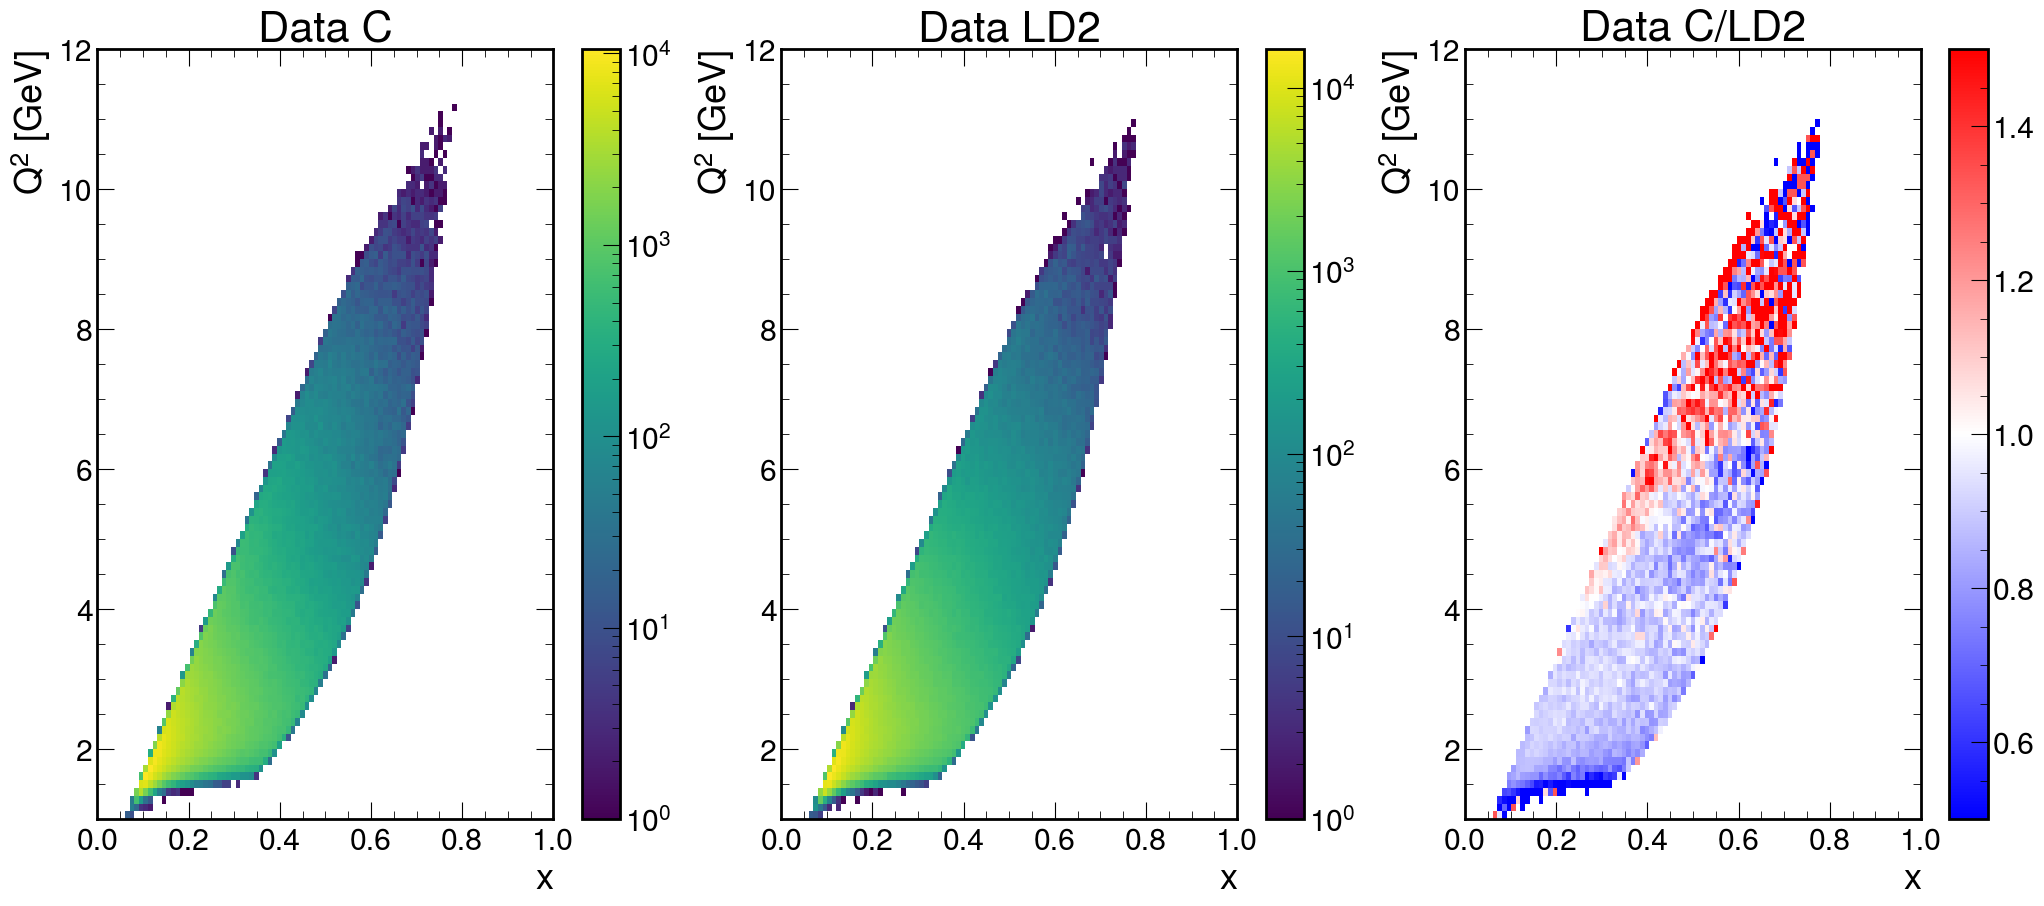

Sim 1867230.0
Sim 1798870.0


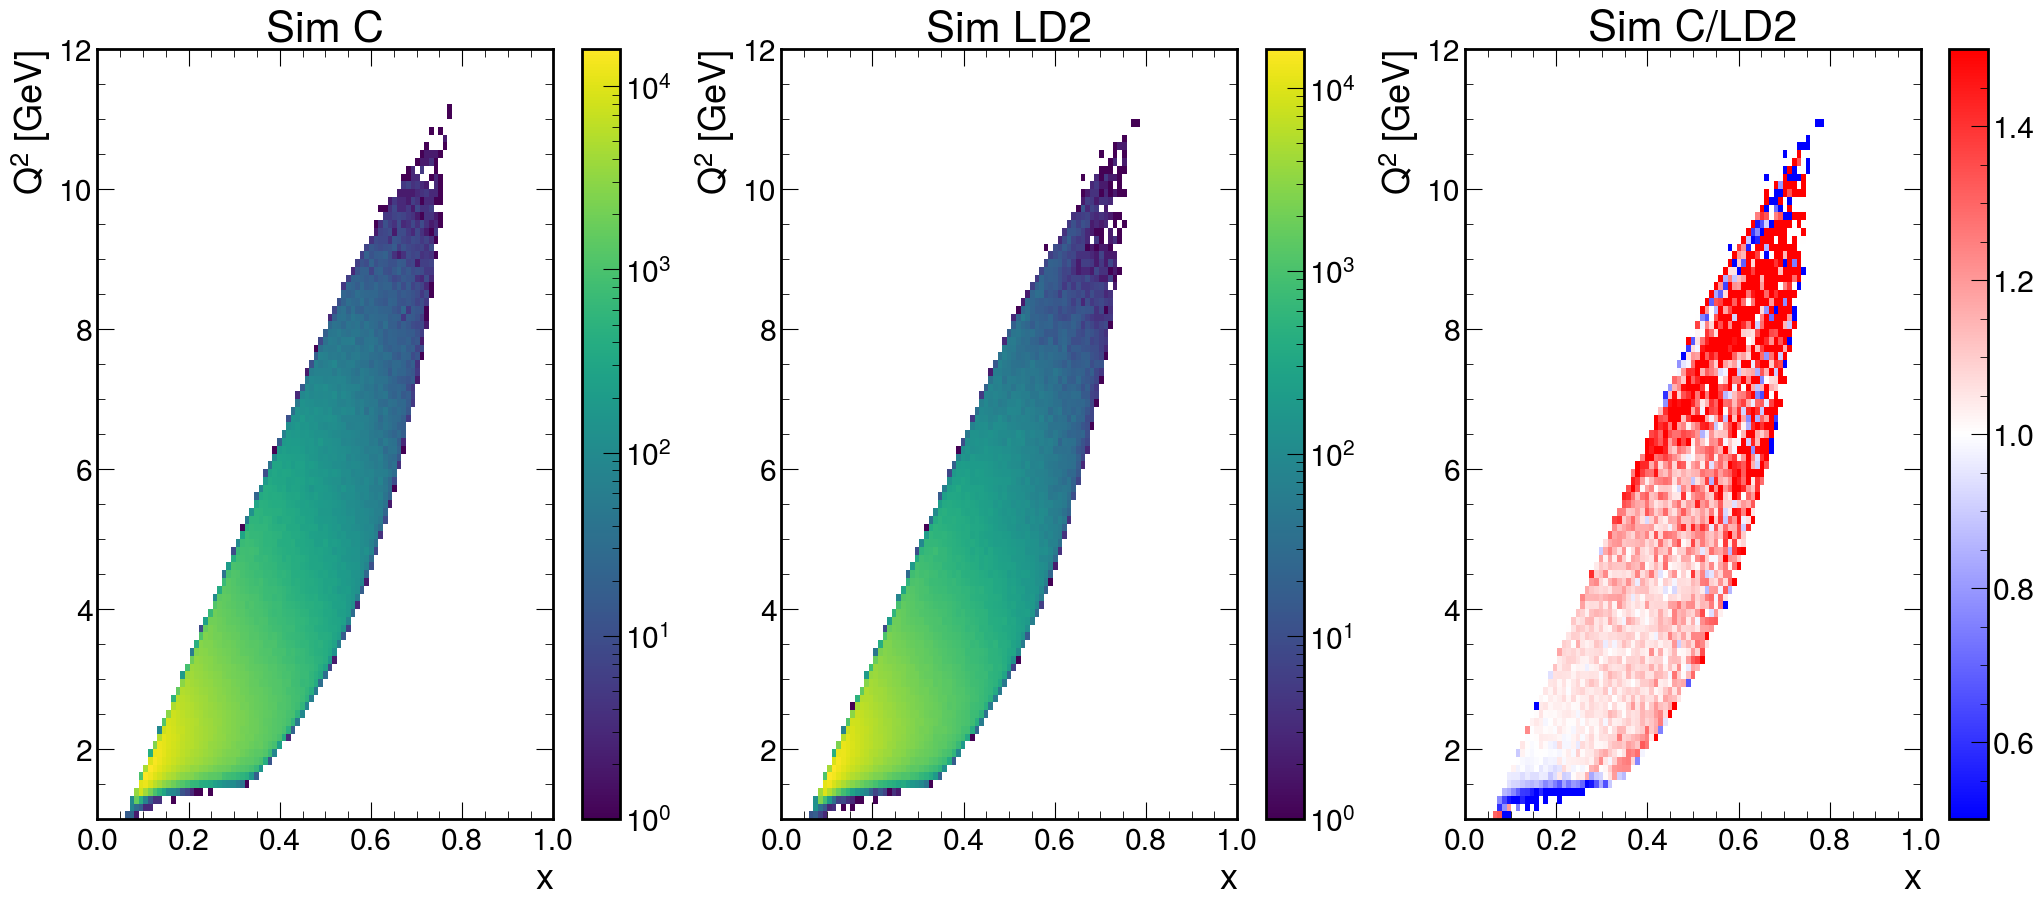

In [38]:
dataframes_dict = {"Data":dataframes, "Sim":sim_dataframes}

ratio_hists = {}
dataframe_solid_hists = {}
dataframe_solid_hists_err = {}
dataframe_liquid_hists = {}
dataframe_liquid_hists_err = {}
for data_name in "Data", "Sim":
    dataframe = dataframes_dict[data_name]
    hists={}
    fig, axs = plt.subplots(1,3, figsize=(25,10))
    
    for i, (target_name, target_data) in enumerate(dataframe.items()):
        plt.sca(axs[i])
        masked_dataframe = dataframe[target_name].query(DIS_cuts)
        hists[target_name] = plt.hist2d(
            masked_dataframe.x,
            masked_dataframe.Q2,
            bins=(x_bin_edges, Q2_bin_edges),
            norm = mcolors.LogNorm()
        )
        plt.xlabel("x")
        plt.ylabel("$Q^2$ [GeV]")
        plt.title(data_name +" "+ target_name)
        plt.colorbar()
    solid_hist_sum = np.sum(hists[solid_target][0])
    print(data_name, solid_hist_sum)
    dataframe_solid_hists[data_name] = hists[solid_target][0]/(solid_hist_sum)
    dataframe_solid_hists_err[data_name] = np.sqrt(hists[solid_target][0])/(solid_hist_sum)
    liquid_hist_sum = np.sum(hists["LD2"][0])
    print(data_name, liquid_hist_sum)
    dataframe_liquid_hists[data_name] = hists["LD2"][0]/liquid_hist_sum
    dataframe_liquid_hists_err[data_name] = np.sqrt(hists["LD2"][0])/(liquid_hist_sum)
    # Create ratio plot
    plt.sca(axs[2])
    # h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target] if data_name == "Data" else hists[solid_target][0] / hists['LD2'][0]
    # xedges, yedges= hists[solid_target][1:3]
    # pc = plt.gca().pcolorfast(xedges, yedges, h.T, norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr'])
    ratio_hist = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target] if data_name == "Data" else hists[solid_target][0] / hists['LD2'][0]
    ratio_hists[data_name] = ratio_hist
    
    plt.hist2d(
        np.ravel(x_padded),
        np.ravel(Q2_padded),
        weights=np.ravel(ratio_hist),
        bins=(x_bin_edges, Q2_bin_edges),
        norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr']
    )
    plt.colorbar()
    plt.xlabel("x")
    plt.ylabel("$Q^2$ [GeV]")  
    plt.title(data_name +" "+ f"{solid_target}/LD2")
    plt.colorbar(pc)
    plt.show()

/tmp/ipykernel_337233/3325823224.py:4: RuntimeWarning: divide by zero encountered in divide
  weights=np.ravel(ratio_hists["Data"]/ratio_hists["Sim"]),
/tmp/ipykernel_337233/3325823224.py:4: RuntimeWarning: invalid value encountered in divide
  weights=np.ravel(ratio_hists["Data"]/ratio_hists["Sim"]),


Text(1, 0, 'x')

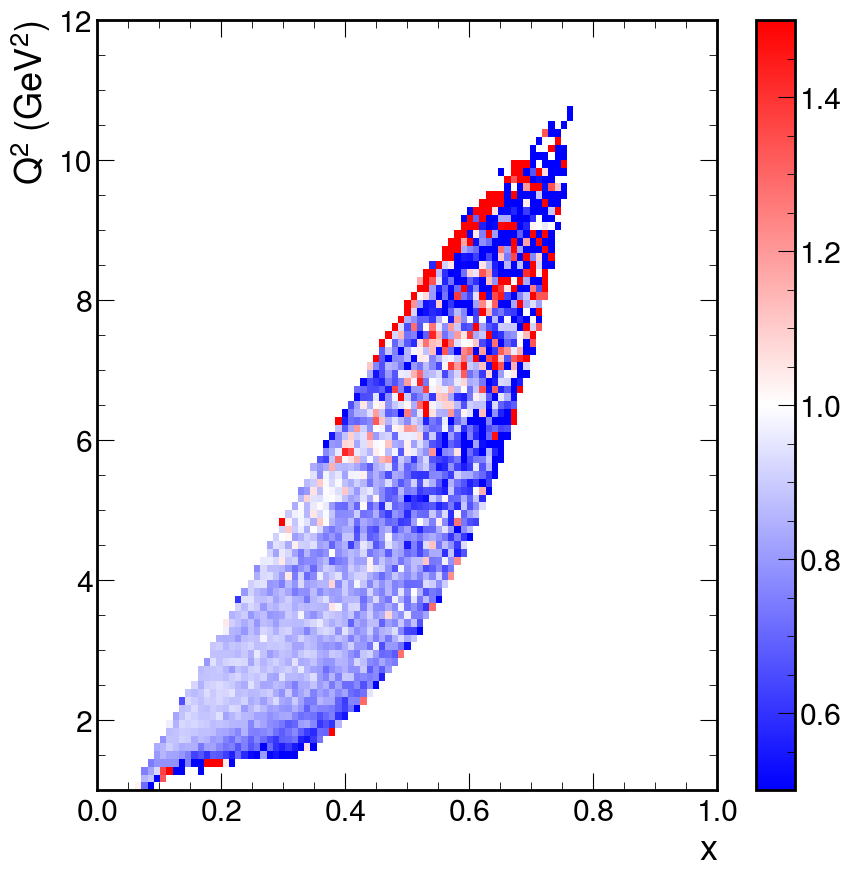

In [39]:
plt.hist2d(
        np.ravel(x_padded),
        np.ravel(Q2_padded),
        weights=np.ravel(ratio_hists["Data"]/ratio_hists["Sim"]),
        bins=(x_bin_edges, Q2_bin_edges),
        cmap=colormaps['bwr'],
        norm=mcolors.Normalize(0.5, 1.5)
    )
plt.colorbar()
plt.ylabel("$Q^2 ~(GeV^2)$")
plt.xlabel("x")

In [54]:
num_Q2_bins = 9
num_x_bins= 10
Q2_bin_edges = np.logspace(np.log10(1), np.log10(12), num=num_Q2_bins+1, base=10.)
x_bin_edges = np.linspace(0, 1, num=num_x_bins+1)
x_bin_centers = (x_bin_edges[:-1] + x_bin_edges[1:])/2
Q2_bin_centers = (Q2_bin_edges[:-1] + Q2_bin_edges[1:])/2
print("x bin centers: ", x_bin_centers)
print("Q2 bin centers: ", Q2_bin_centers)
# Values of the bin centers in 2d histogram format
x_padded, Q2_padded = np.meshgrid(x_bin_centers, Q2_bin_centers)
# Taking transpose gives x constant along inner dimension, Q2 varies along inner dimension
x_padded = x_padded.T
Q2_padded = Q2_padded.T

x bin centers:  [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Q2 bin centers:  [ 1.15899031  1.52752678  2.01325071  2.65342544  3.49716333  4.60919353
  6.07482779  8.00650535 10.55241896]


In [41]:
def DivideWithErrors(numerator, numerator_err, divisor, divisor_err):
    ratio = np.zeros_like(numerator)
    ratio_err = np.zeros_like(numerator)
    zero_mask = (numerator > 0) & (divisor > 0)
    ratio[zero_mask] = numerator[zero_mask] / divisor[zero_mask]
    ratio_err[zero_mask] = ratio[zero_mask] * np.sqrt( ( numerator_err[zero_mask]/numerator[zero_mask] )**2 + ( divisor_err[zero_mask]/divisor[zero_mask] )**2)
    ratio[~zero_mask] = None
    ratio_err[~zero_mask] = None
    return ratio, ratio_err

### Calculating acceptance corrections

/tmp/ipykernel_337233/1636698160.py:21: RuntimeWarning: divide by zero encountered in divide
  acceptance_corrections = hists[solid_target][0] / hists['LD2'][0]
/tmp/ipykernel_337233/1636698160.py:21: RuntimeWarning: invalid value encountered in divide
  acceptance_corrections = hists[solid_target][0] / hists['LD2'][0]


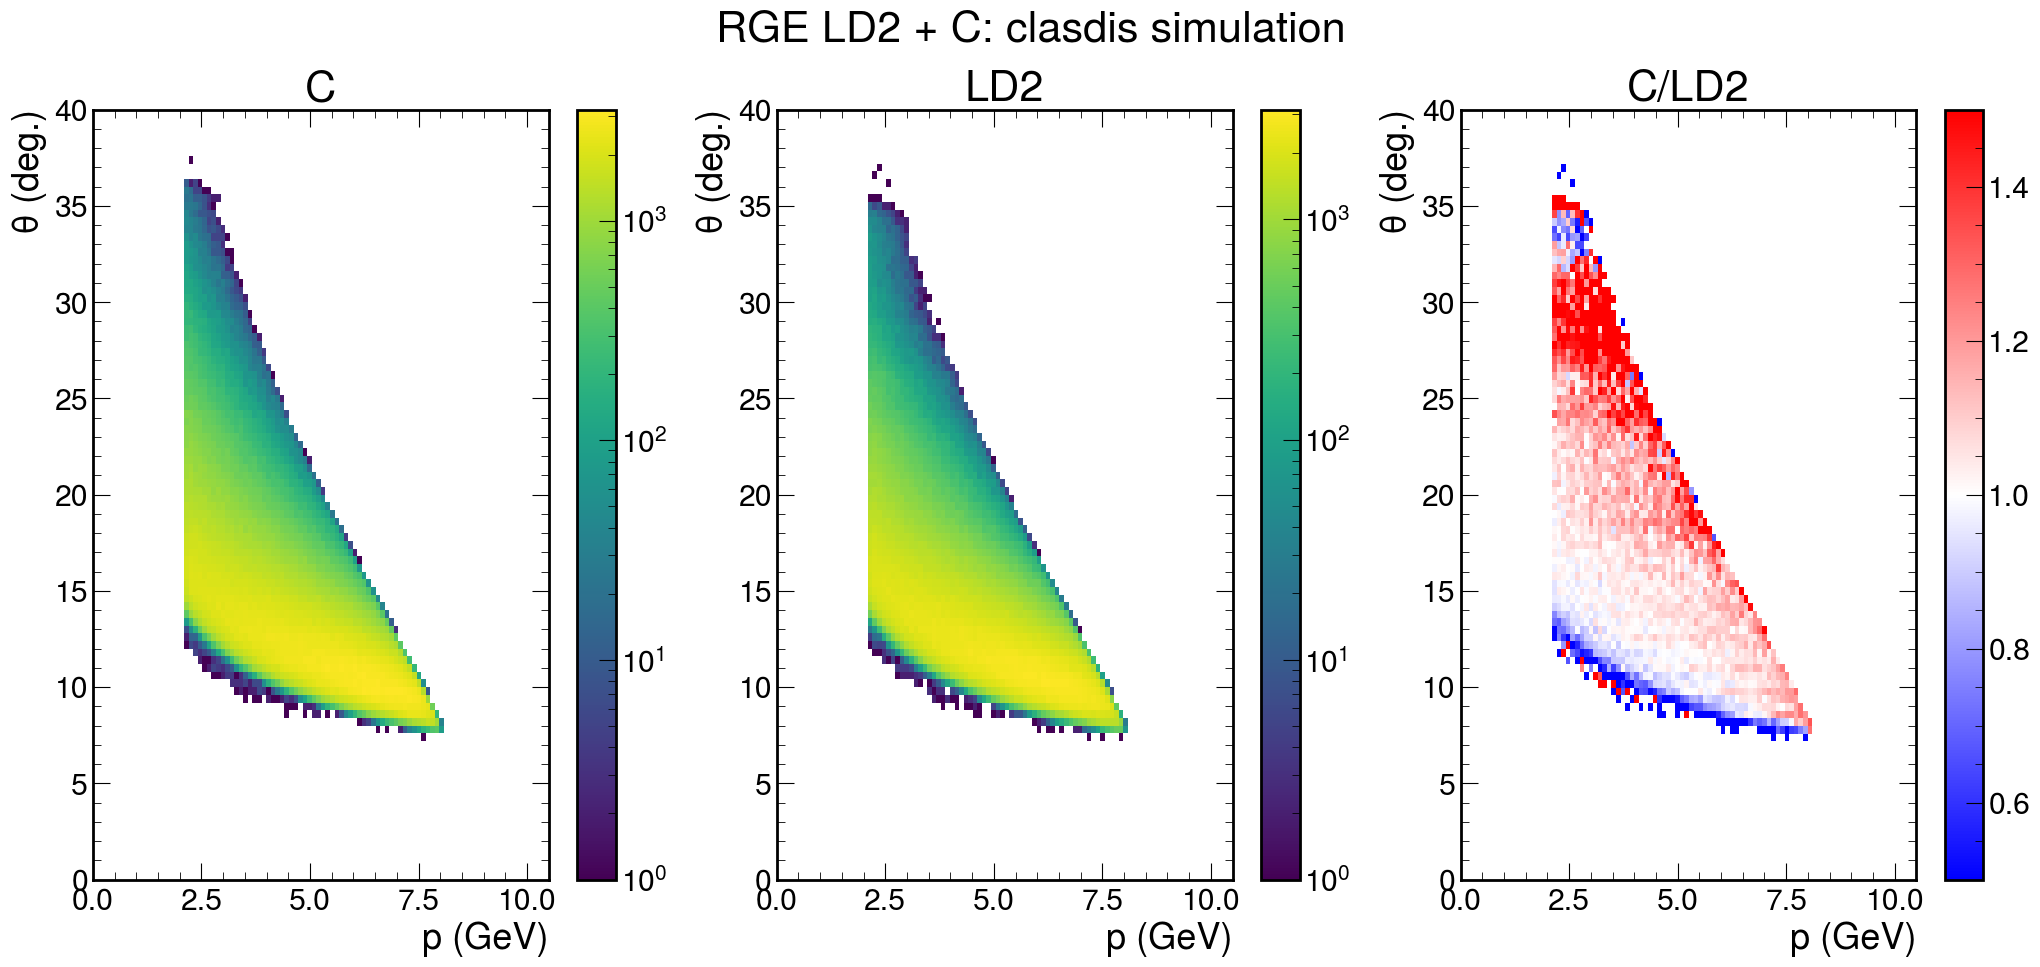

In [42]:
hists={}
fig, axs = plt.subplots(1,3, figsize=(25,10))

for i, (target_name, target_data) in enumerate(sim_dataframes.items()):
    plt.sca(axs[i])
    masked_dataframe = sim_dataframes[target_name].query(DIS_cuts)
    hists[target_name] = plt.hist2d(
        masked_dataframe.p,
        masked_dataframe.theta*180/np.pi,
        bins=100,
        range=((0, 10.5), (0, 40)),
        norm = mcolors.LogNorm()
    )
    plt.xlabel("p (GeV)")
    plt.ylabel("$\\theta$ (deg.)")  
    plt.title(target_name)
    plt.colorbar()

# Create ratio plot
plt.sca(axs[2])
acceptance_corrections = hists[solid_target][0] / hists['LD2'][0]
acceptance_corrections_xedges = hists[solid_target][1]
acceptance_corrections_yedges = hists[solid_target][2]
xedges, yedges= hists[solid_target][1:3]
pc = plt.gca().pcolorfast(xedges, yedges, acceptance_corrections.T, norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr'])
plt.xlabel("p (GeV)")
plt.ylabel("$\\theta$ (deg.)")  
plt.title(f"{solid_target}/LD2")
plt.colorbar(pc)
plt.suptitle(sim_title)
plt.show()

In [43]:
solid_pbins_index = np.digitize(dataframes[solid_target].p, acceptance_corrections_xedges, right=True)-1
solid_thetabins_index = np.digitize(dataframes[solid_target].theta*180/np.pi, acceptance_corrections_yedges, right=True)-1

solid_pbins_index = np.clip(solid_pbins_index, 0, acceptance_corrections.shape[0] - 1)
solid_thetabins_index = np.clip(solid_thetabins_index, 0, acceptance_corrections.shape[0] - 1)

solid_acceptance_corrections = [
    acceptance_corrections[p_idx, theta_idx]
    for p_idx, theta_idx in zip(solid_pbins_index, solid_thetabins_index)
]
solid_acceptance_corrections = np.nan_to_num(solid_acceptance_corrections, nan=1.0)
solid_acceptance_corrections[solid_acceptance_corrections == 0] = 1.0
dataframes[solid_target]["acceptance_corrections"] = solid_acceptance_corrections

In [44]:
# dataframes_dict = {"Data":dataframes, "Sim":sim_dataframes}

# ratio_hists = {}
# ratio_hists_err = {}
# dataframe_solid_hists = {}
# dataframe_solid_hists_err = {}
# dataframe_liquid_hists = {}
# dataframe_liquid_hists_err = {}

# for data_name in "Data", "Sim":
#     if data_name=="Sim":
#         continue
#     dataframe = dataframes_dict[data_name]
#     hists={}
#     fig, axs = plt.subplots(1,3, figsize=(25,10))
    
#     for i, (target_name, target_data) in enumerate(dataframe.items()):
#         plt.sca(axs[i])
#         masked_dataframe = dataframe[target_name].query(DIS_cuts)
#         if target_name == solid_target:
            
#             print(target_name)
#             hists[target_name] = plt.hist2d(
#                 masked_dataframe.x,
#                 masked_dataframe.Q2,
#                 weights = (1/masked_dataframe.acceptance_corrections),
#                 bins=(x_bin_edges, Q2_bin_edges),
#                 norm = mcolors.LogNorm()
#             )
#         else:
#             hists[target_name] = plt.hist2d(
#                 masked_dataframe.x,
#                 masked_dataframe.Q2,
#                 bins=(x_bin_edges, Q2_bin_edges),
#                 norm = mcolors.LogNorm()
#             )
#         plt.xlabel("x")
#         plt.ylabel("$Q^2~ (GeV^2)$")
#         plt.title(target_name)
#         plt.colorbar()

#     # solid_hist_value = hists[solid_target][0]
#     solid_hist_value = hists[solid_target][0]/lumonisity_ratios[solid_target] if data_name == "Data" else hists[solid_target][0]
#     dataframe_solid_hists[data_name] = solid_hist_value
#     dataframe_solid_hists_err[data_name] = np.sqrt(solid_hist_value)
    
#     dataframe_liquid_hists[data_name] = hists["LD2"][0]
#     dataframe_liquid_hists_err[data_name] = np.sqrt(hists["LD2"][0])
    
#     # Create ratio plot
#     plt.sca(axs[2])
#     # h = hists[solid_target][0] / hists['LD2'][0] / lumonisity_ratios[solid_target] if data_name == "Data" else hists[solid_target][0] / hists['LD2'][0]
#     # xedges, yedges= hists[solid_target][1:3]
#     # pc = plt.gca().pcolorfast(xedges, yedges, h.T, norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr'])
#     ratio_hist, ratio_hist_err = DivideWithErrors(
#         numerator = dataframe_solid_hists[data_name],
#         numerator_err = dataframe_solid_hists_err[data_name],
#         divisor = dataframe_liquid_hists[data_name],
#         divisor_err = dataframe_liquid_hists_err[data_name]
#     )
#     ratio_hists[data_name] = ratio_hist
#     ratio_hists_err[data_name] = ratio_hist_err
    
    
#     plt.hist2d(
#         np.ravel(x_padded),
#         np.ravel(Q2_padded),
#         weights=np.ravel(ratio_hist),
#         bins=(x_bin_edges, Q2_bin_edges),
#         norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr']
#     )
    
#     plt.colorbar()
#     plt.xlabel("x")
#     plt.ylabel("$Q^2~ (GeV^2)$")  
#     plt.title(f"{solid_target}/LD2")
#     plt.suptitle(plot_title, y=1.)
#     plt.colorbar(pc)
#     plt.show()

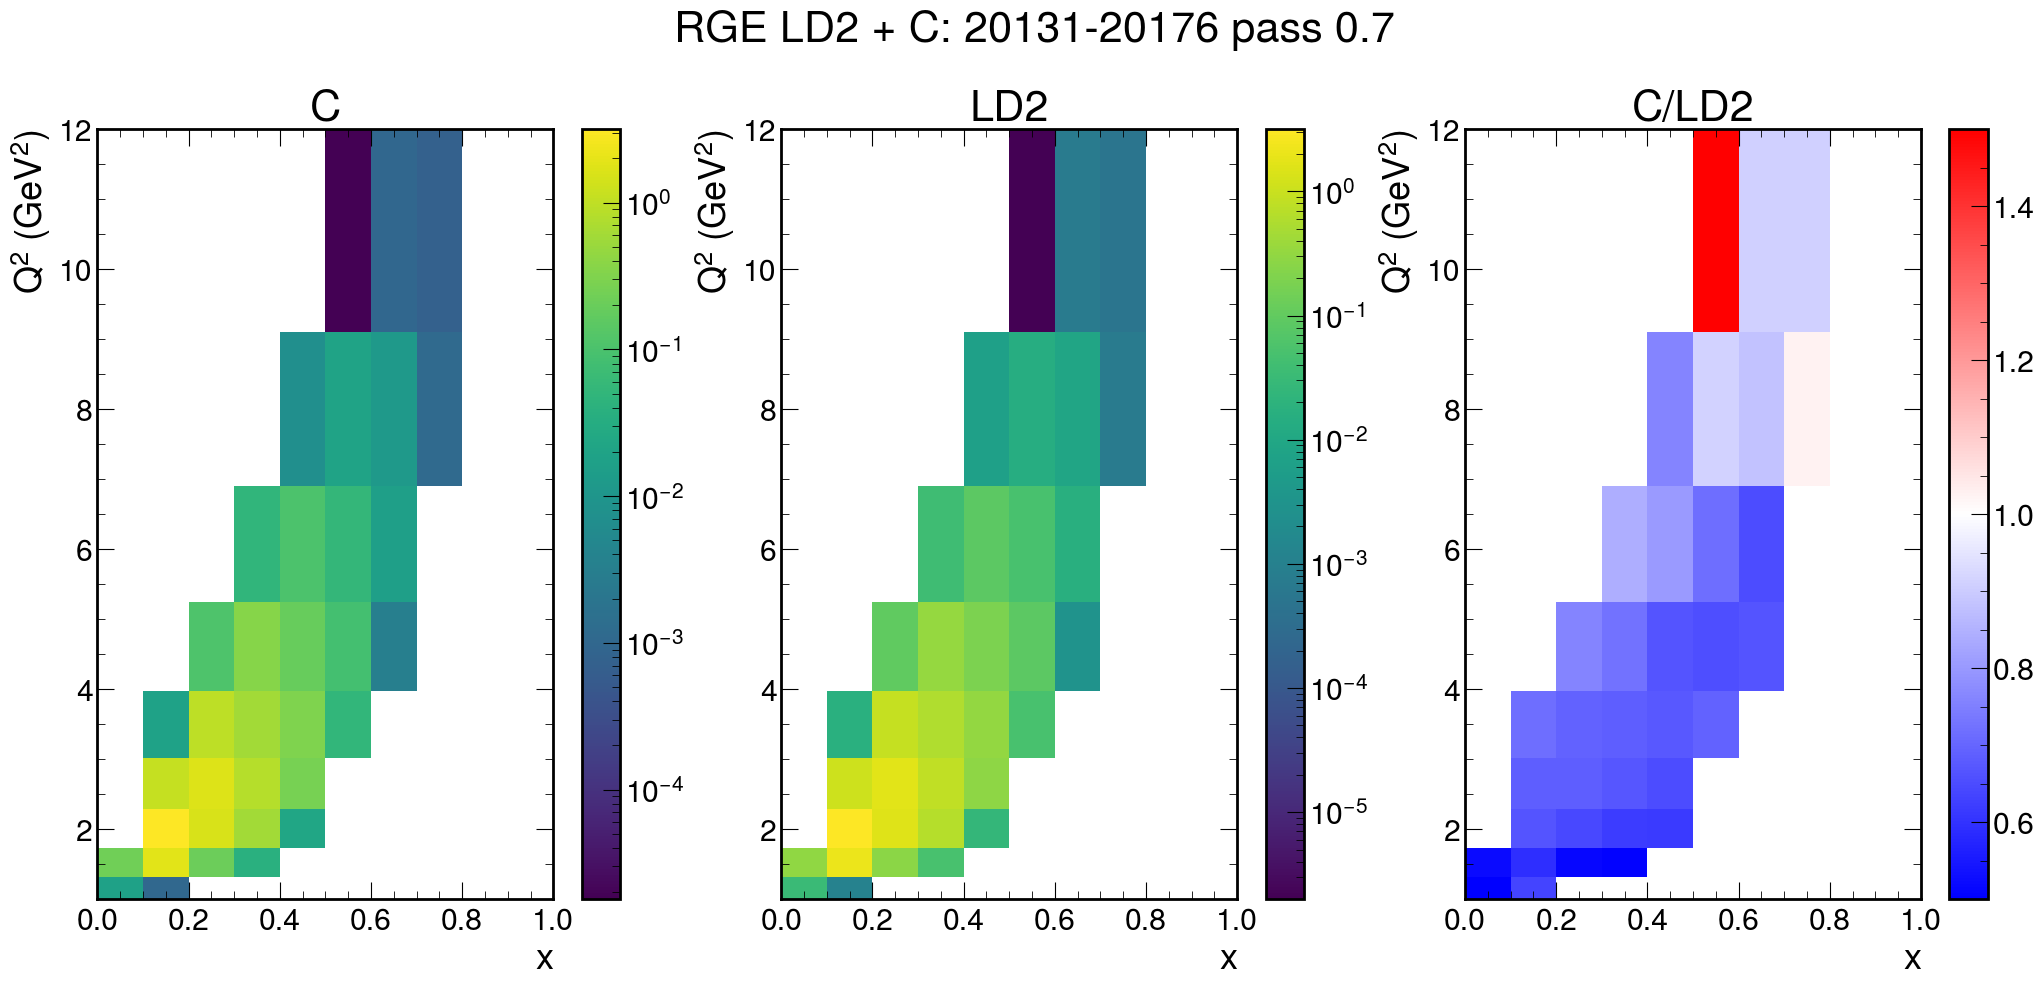

In [45]:
dataframes_dict = {"Data":dataframes, "Sim":sim_dataframes}

ratio_hists = {}
ratio_hists_err = {}
dataframe_solid_hists = {}
dataframe_solid_hists_err = {}
dataframe_liquid_hists = {}
dataframe_liquid_hists_err = {}

for data_name in "Data", "Sim":
    if data_name=="Sim":
        continue
    dataframe = dataframes_dict[data_name]
    hists={}
    normalized_hists, normalized_hist_errors = {}, {}
    nonnormalized_hists, nonnormalized_hist_errors = {}, {}
    fig, axs = plt.subplots(1,3, figsize=(25,10))
    
    for i, (target_name, target_data) in enumerate(dataframe.items()):
        plt.sca(axs[i])
        masked_dataframe = dataframe[target_name].query(DIS_cuts)

        H_counts, xedges, yedges = np.histogram2d(
            masked_dataframe.x,
            masked_dataframe.Q2,
            bins=(x_bin_edges, Q2_bin_edges)
        )
        nonnormalized_hists[target_name] = H_counts
        nonnormalized_hist_errors[target_name] = np.sqrt(H_counts)
        H_errors = np.sqrt(H_counts)
        x_widths = np.diff(xedges)
        y_widths = np.diff(yedges)
        bin_areas = np.outer(x_widths, y_widths)
        
        total_counts = np.sum(H_counts)
        
        H_density = H_counts / (total_counts * bin_areas)
        H_error_density = H_errors / (total_counts * bin_areas)
        normalized_hists[target_name] = H_density
        normalized_hist_errors[target_name] = H_error_density
        
        
        hists[target_name] = plt.hist2d(
            masked_dataframe.x,
            masked_dataframe.Q2,
            bins=(x_bin_edges, Q2_bin_edges),
            norm = mcolors.LogNorm(),
            density=True
        )

        plt.xlabel("x")
        plt.ylabel("$Q^2~ (GeV^2)$")
        plt.title(target_name)
        plt.colorbar()

    solid_hist_value = hists[solid_target][0]
    dataframe_solid_hists[data_name] = normalized_hists[solid_target]
    dataframe_solid_hists_err[data_name] = normalized_hist_errors[solid_target]
    
    dataframe_liquid_hists[data_name] = normalized_hists["LD2"]
    dataframe_liquid_hists_err[data_name] = normalized_hist_errors["LD2"]
    
    plt.sca(axs[2])
    ratio_hist, ratio_hist_err = DivideWithErrors(
        numerator = nonnormalized_hists[solid_target],
        numerator_err = nonnormalized_hist_errors[solid_target],
        divisor = nonnormalized_hists["LD2"],
        divisor_err = nonnormalized_hist_errors["LD2"]
    )
    ratio_hists[data_name] = ratio_hist
    ratio_hists_err[data_name] = ratio_hist_err
    
    plt.hist2d(
        np.ravel(x_padded),
        np.ravel(Q2_padded),
        weights=np.ravel(ratio_hist),
        bins=(x_bin_edges, Q2_bin_edges),
        norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr']
    )
    
    plt.colorbar()
    plt.xlabel("x")
    plt.ylabel("$Q^2~ (GeV^2)$")  
    plt.title(f"{solid_target}/LD2")
    plt.suptitle(plot_title, y=1.)
    plt.colorbar(pc)
    plt.show()

In [46]:
# plt.hist2d(
#         np.ravel(x_padded),
#         np.ravel(Q2_padded),
#         weights=np.ravel(ratio_hists["Sim"]),
#         bins=(x_bin_edges, Q2_bin_edges),
#     )
# plt.colorbar()
# plt.ylabel("$Q^2 ~(GeV^2)$")
# plt.xlabel("x")
# plt.title("C/LD2 Corrections")

In [47]:
# y_low, y_high = 0, 3.5

# for i in range(len(Q2_bin_edges) - 1):
#     low_edge = Q2_bin_edges[i]
#     high_edge = Q2_bin_edges[i + 1]
#     label = f"${low_edge:.2f} < Q^2 < {high_edge:.2f}$"
#     bin_widths = x_centers[1] - x_centers[0]
    
#     plot = plt.errorbar(x_centers, ratio_hists["Sim"][:, i], xerr = bin_widths, yerr = ratio_hists_err["Sim"][:, i], label=label, fmt="o")

# plt.xlabel("x")
# plt.ylabel(f"$\sigma_{{{solid_target},sim}}/\sigma_{{LD2,sim}}$")
# plt.legend(ncol=2, loc='upper left')
# plt.tight_layout()

# plt.ylim(y_low, y_high)

# plt.title("C/LD2 Corrections")

In [48]:
def IntegrateAlongQ2(counts_2d):
    counts_1d = np.sum(counts_2d, axis = 1)
    counts_1d_errors = np.sqrt(counts_1d)
    return counts_1d, counts_1d_errors

Text(0.5, 1.0, 'RGE LD2 + C: 20131-20176 pass 0.7')

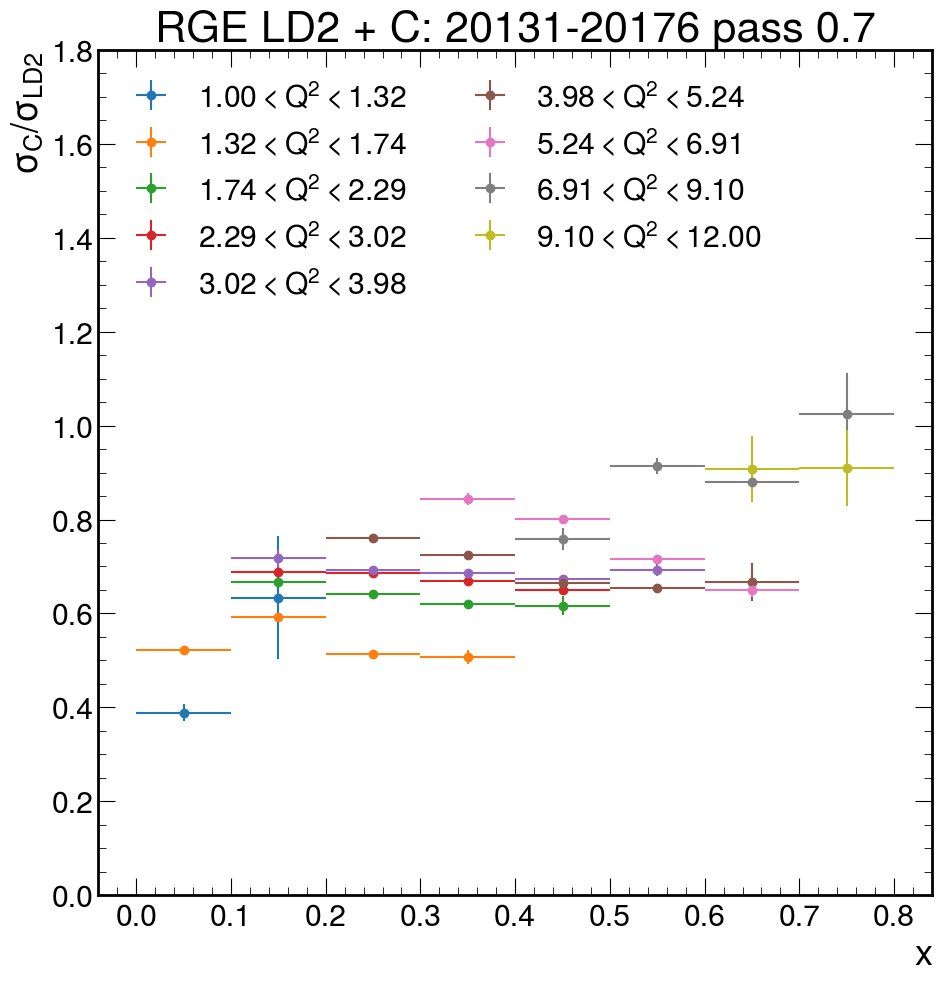

In [49]:
y_low, y_high = 0, 1.8

for i in range(len(Q2_bin_edges) - 1):
    low_edge = Q2_bin_edges[i]
    high_edge = Q2_bin_edges[i + 1]
    label = f"${low_edge:.2f} < Q^2 < {high_edge:.2f}$"
    ylim_mask = (ratio_hists["Data"][:, i]>y_low) & (ratio_hists["Data"][:, i] < y_high)
    bin_widths = x_bin_centers[1] - x_bin_centers[0]
    
    plot = plt.errorbar(x_bin_centers[ylim_mask], ratio_hists["Data"][:, i][ylim_mask], xerr = bin_widths/2, yerr = ratio_hists_err["Data"][:, i][ylim_mask], label=label, fmt="o")

plt.xlabel("x")
plt.ylabel(f"$\sigma_{{{solid_target}}}/\sigma_{{LD2}}$")
plt.legend(ncol=2, loc='upper left')
plt.tight_layout()
plt.ylim(y_low,y_high)
plt.title(plot_title)

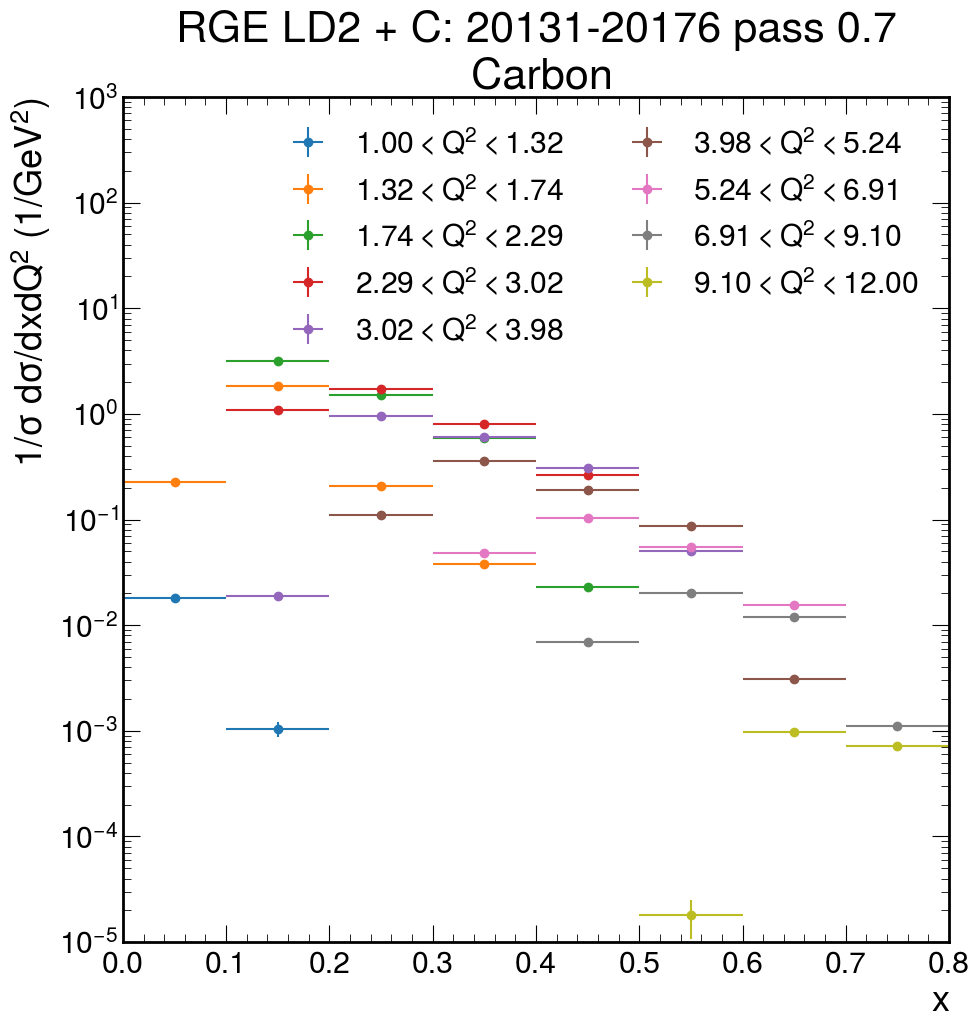

In [50]:
y_low, y_high = 0, 100

for i in range(len(Q2_bin_edges) - 1):
    low_edge = Q2_bin_edges[i]
    high_edge = Q2_bin_edges[i + 1]
    label = f"${low_edge:.2f} < Q^2 < {high_edge:.2f}$"
    ylim_mask = (dataframe_solid_hists["Data"][:, i]>y_low) & (dataframe_solid_hists["Data"][:, i] < y_high)
    bin_widths = x_bin_centers[1] - x_bin_centers[0]
    
    plot = plt.errorbar(x_bin_centers[ylim_mask], dataframe_solid_hists["Data"][:, i][ylim_mask], xerr = bin_widths/2, yerr = dataframe_solid_hists_err["Data"][:, i][ylim_mask], label=label, fmt="o")

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Carbon")
plt.yscale('log')

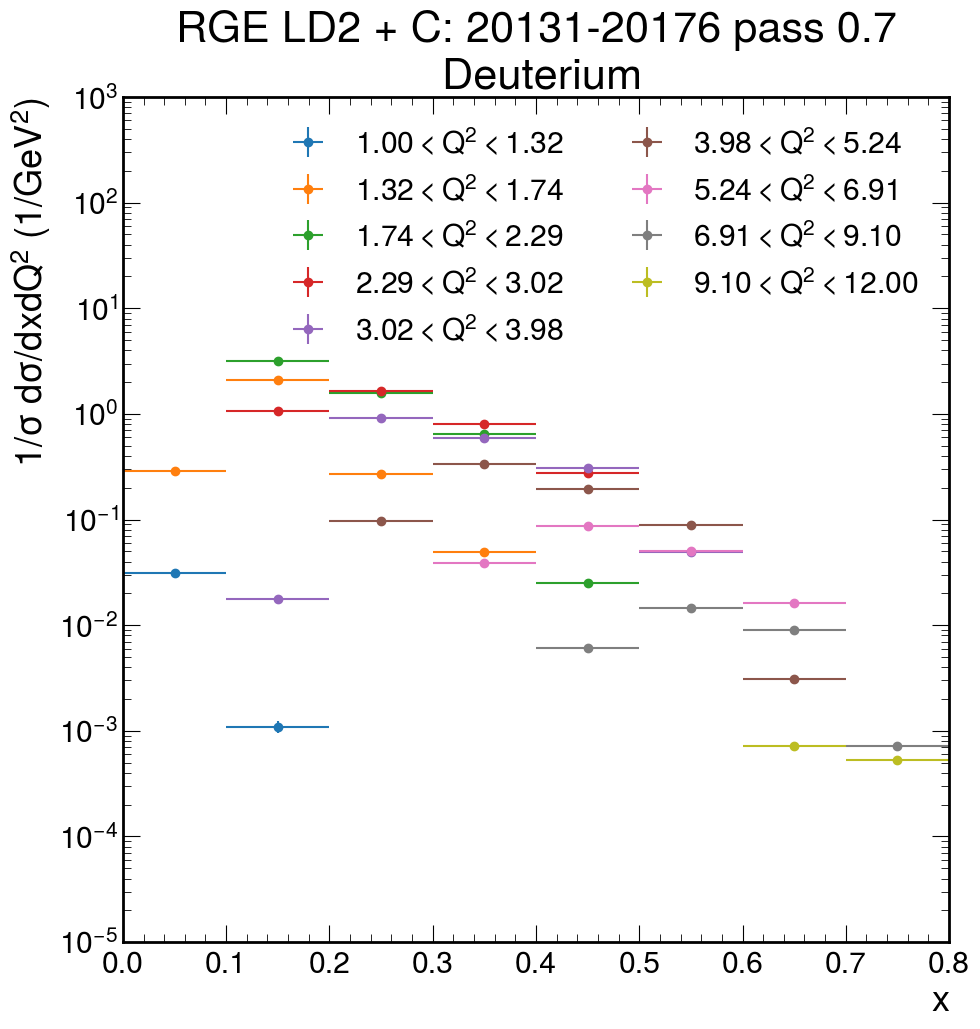

In [51]:
y_low, y_high = 0, 100

for i in range(len(Q2_bin_edges) - 1):
    low_edge = Q2_bin_edges[i]
    high_edge = Q2_bin_edges[i + 1]
    label = f"${low_edge:.2f} < Q^2 < {high_edge:.2f}$"
    ylim_mask = (dataframe_liquid_hists["Data"][:, i]>y_low) & (dataframe_liquid_hists["Data"][:, i] < y_high)
    bin_widths = x_bin_centers[1] - x_bin_centers[0]
    
    plot = plt.errorbar(x_bin_centers[ylim_mask], dataframe_liquid_hists["Data"][:, i][ylim_mask], xerr = bin_widths/2, yerr = dataframe_liquid_hists_err["Data"][:, i][ylim_mask], label=label, fmt="o")

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Deuterium")
plt.yscale('log')

### Repeating above procedure with radiative corrections

In [100]:
def CalculateCentroids(x_bin_edges, Q2_bin_edges, x_data, Q2_data):
    x_centroids = []
    Q2_centroids = []
    bin_yields = []
    for i, x_edge in enumerate(x_bin_edges):
        if i == len(x_bin_edges)-1:
            break
        x_bin_low, x_bin_high = x_edge, x_bin_edges[i+1]
        for j, Q2_edge in enumerate(Q2_bin_edges):
            if j == len(Q2_bin_edges)-1:
                break
            Q2_bin_low, Q2_bin_high = Q2_edge, Q2_bin_edges[j+1]
            bin_mask = (x_data < x_bin_high) & (x_data > x_bin_low) & (Q2_data < Q2_bin_high) & (Q2_data > Q2_bin_low)
            x_in_bin = x_data[bin_mask]
            Q2_in_bin = Q2_data[bin_mask]
            bin_yield = len(x_in_bin)
            if bin_yield != len(Q2_in_bin):
                print("wut")
            bin_yields.append(bin_yield)
            if len(x_in_bin) == 0 or len(Q2_in_bin) == 0:
                continue
            x_center = np.mean(x_in_bin)
            x_centroids.append(x_center)
            y_center = np.mean(Q2_in_bin)
            Q2_centroids.append(y_center)
    return x_centroids, Q2_centroids
def InputForExternals(x_bin_centers, Q2_bin_centers):
    Eb =  10.5473
    Mp = 0.938272
    x_bin_centers = np.asarray(x_bin_centers)
    Q2_bin_centers = np.asarray(Q2_bin_centers)
    Ep = Eb - Q2_bin_centers/(2. * Mp * x_bin_centers)
    theta = 2. * np.arcsin(np.sqrt(Q2_bin_centers/(4. * Eb * Ep)))
    
    theta_deg = np.degrees(theta)
    theta_deg[theta_deg<0] += 360
    print("E\tEp\ttheta\tW\ty\tx\tQ2")
    for Ep, theta in zip(Ep, theta_deg):
        if Ep < 0:
            continue
        print("{Eb:.3f} {Ep:.3f} {theta:.4f}".format(Eb = round(Eb, 3), Ep = round(Ep, 3), theta = round(theta, 4)))

In [101]:
solid_x_centroids, solid_Q2_centroids = CalculateCentroids(x_bin_edges,
                                                           Q2_bin_edges,
                                                           dataframe["C"].x,
                                                           dataframe["C"].Q2)

In [102]:
bin_center_mesh = np.meshgrid(x_bin_centers, Q2_bin_centers)
# print(solid_x_centroids)
# print(solid_Q2_centroids)
# print(x_bin_centers)
# print(Q2_bin_centers)
x_bin_centers_repeated = []
for xbins in bin_center_mesh[0]:
    x_bin_centers_repeated.extend(xbins)
Q2_bin_centers_repeated = []
for Q2bins in bin_center_mesh[1]:
    Q2_bin_centers_repeated.extend(Q2bins)
InputForExternals(x_bin_centers_repeated, Q2_bin_centers_repeated)
# print(x_bin_centers)
# print(Q2_bin_centers)
# print(np.meshgrid(x_bin_centers, Q2_bin_centers)[0][0])
# print(np.meshgrid(x_bin_centers, Q2_bin_centers)[1][1])

E	Ep	theta	W	y	x	Q2
10.547 6.430 7.4955
10.547 8.077 6.6868
10.547 8.783 6.4122
10.547 9.175 6.2735
10.547 9.424 6.1898
10.547 9.597 6.1338
10.547 9.724 6.0937
10.547 9.821 6.0635
10.547 9.897 6.0400
10.547 5.121 9.6472
10.547 7.291 8.0817
10.547 8.222 7.6101
10.547 8.738 7.3813
10.547 9.067 7.2460
10.547 9.295 7.1566
10.547 9.462 7.0931
10.547 9.590 7.0456
10.547 9.690 7.0088
10.547 3.395 13.6178
10.547 6.256 10.0210
10.547 7.482 9.1612
10.547 8.163 8.7699
10.547 8.597 8.5455
10.547 8.897 8.3999
10.547 9.117 8.2977
10.547 9.285 8.2220
10.547 9.418 8.1637
10.547 1.121 27.4073
10.547 4.891 13.0220
10.547 6.507 11.2838
10.547 7.405 10.5756
10.547 7.976 10.1888
10.547 8.372 9.9446
10.547 8.662 9.7763
10.547 8.884 9.6532
10.547 9.059 9.5592
10.547 3.093 18.8448
10.547 5.223 14.4750
10.547 6.406 13.0635
10.547 7.159 12.3546
10.547 7.680 11.9264
10.547 8.062 11.6392
10.547 8.355 11.4331
10.547 8.586 11.2778
10.547 0.722 45.7690
10.547 3.530 20.2662
10.547 5.089 16.8505
10.547 6.081 15.4053
1

/tmp/ipykernel_337233/1599149736.py:33: RuntimeWarning: invalid value encountered in sqrt
  theta = 2. * np.arcsin(np.sqrt(Q2_bin_centers/(4. * Eb * Ep)))


In [52]:
y_low, y_high = 0, 1.5
data_sim_ratio, data_sim_ratio_err = DivideWithErrors(
    numerator = ratio_hists["Data"],
    numerator_err = ratio_hists_err["Data"],
    divisor = ratio_hists["Sim"],
    divisor_err = ratio_hists_err["Sim"],
)

for i in range(len(Q2_bin_edges) - 1):
    low_edge = Q2_bin_edges[i]
    high_edge = Q2_bin_edges[i + 1]
    label = f"${low_edge:.2f} < Q^2 < {high_edge:.2f}$"
    ylim_mask = (data_sim_ratio[:, i]>y_low) & (data_sim_ratio[:, i] < y_high)
    bin_widths = x_centers[1] - x_centers[0]
    
    plot = plt.errorbar(x_centers[ylim_mask], data_sim_ratio[:, i][ylim_mask], yerr = data_sim_ratio_err[:, i][ylim_mask], xerr = bin_widths, label=label, fmt="o")

plt.xlabel("x")
plt.ylabel(f"$(\sigma_{{{solid_target},data}}/\sigma_{{LD2,data}})/(\sigma_{{{solid_target},sim}}/\sigma_{{LD2,sim}})$")
plt.legend(ncol=2, loc='upper left')
plt.tight_layout()
plt.ylim(y_low, y_high)
plt.title("C/LD2 EMC after corrections")

KeyError: 'Sim'

In [ ]:
# mask = dataframe_solid_hists["Sim"]>0
# integrated_solid, integrated_solid_err = IntegrateAlongQ2(ak.mask(dataframe_solid_hists["Data"], mask)/ak.mask(dataframe_solid_hists["Sim"],mask))

# mask = dataframe_liquid_hists["Sim"]>0
# integrated_deuterium, integrated_deuterium_err = IntegrateAlongQ2(ak.mask(dataframe_liquid_hists["Data"], mask)/ak.mask(dataframe_liquid_hists["Sim"],mask))
# integrated_EMC = integrated_solid[integrated_deuterium>0]/integrated_deuterium[integrated_deuterium>0]
# plt.errorbar(x_bin_centers[integrated_deuterium>0],
#              y=integrated_EMC,
#              yerr = 0,
#              linestyle='none',
#              fmt ='o',
#              label="RGE no corrections")

In [ ]:
import numpy as np
import awkward as ak  # since you use ak.mask

def ratio_and_error(A, A_err, C, C_err):
    """Compute ratio and its uncertainty bin-by-bin"""
    ratio = np.zeros_like(A, dtype=float)
    ratio_err = np.zeros_like(A, dtype=float)
    
    # Mask to avoid division by zero
    mask = (C > 0) & (A > 0)
    
    ratio[mask] = A[mask] / C[mask]
    # Propagate error
    ratio_err[mask] = ratio[mask] * np.sqrt((A_err[mask]/A[mask])**2 + (C_err[mask]/C[mask])**2)
    
    # For bins where mask is False, you can leave ratio and error as 0 or np.nan
    ratio[~mask] = 0
    ratio_err[~mask] = 0
    return ratio, ratio_err

def integrate_with_error(ratio_2d, ratio_err_2d):
    """Integrate along y (axis=1) and propagate errors"""
    integral = np.sum(ratio_2d, axis=1)
    integral_err = np.sqrt(np.sum(ratio_err_2d**2, axis=1))
    return integral, integral_err

# Compute solid histogram ratio and errors
mask_solid = dataframe_solid_hists["Sim"] > 0
A = ak.to_numpy(ak.mask(dataframe_solid_hists["Data"], mask_solid))
A_err = ak.to_numpy(ak.mask(dataframe_solid_hists_err["Data"], mask_solid))
C = ak.to_numpy(ak.mask(dataframe_solid_hists["Sim"], mask_solid))
C_err = ak.to_numpy(ak.mask(dataframe_solid_hists_err["Sim"], mask_solid))

ratio_solid, ratio_solid_err = ratio_and_error(A, A_err, C, C_err)
integrated_solid, integrated_solid_err = integrate_with_error(ratio_solid, ratio_solid_err)

# Compute liquid histogram ratio and errors
mask_liquid = dataframe_liquid_hists["Sim"] > 0
B = ak.to_numpy(ak.mask(dataframe_liquid_hists["Data"], mask_liquid))
B_err = ak.to_numpy(ak.mask(dataframe_liquid_hists_err["Data"], mask_liquid))
D = ak.to_numpy(ak.mask(dataframe_liquid_hists["Sim"], mask_liquid))
D_err = ak.to_numpy(ak.mask(dataframe_liquid_hists_err["Sim"], mask_liquid))

ratio_liquid, ratio_liquid_err = ratio_and_error(B, B_err, D, D_err)
integrated_liquid, integrated_liquid_err = integrate_with_error(ratio_liquid, ratio_liquid_err)

# Compute final EMC ratio and error
mask_final = (integrated_liquid > 0) & (integrated_solid > 0)
EMC = np.zeros_like(integrated_solid)
EMC_err = np.zeros_like(integrated_solid)

EMC[mask_final] = integrated_solid[mask_final] / integrated_liquid[mask_final]
EMC_err[mask_final] = EMC[mask_final] * np.sqrt(
    (integrated_solid_err[mask_final] / integrated_solid[mask_final])**2 +
    (integrated_liquid_err[mask_final] / integrated_liquid[mask_final])**2
)

# Plot with errors
plt.errorbar(x_bin_centers[mask_final],
             EMC[mask_final],
             yerr=EMC_err[mask_final],
             linestyle='none',
             fmt='o',
             )
plt.xlabel("x")
plt.ylabel(f"$(\sigma_{{{solid_target},data}}/\sigma_{{{solid_target},sim}})/(\sigma_{{LD2,data}}/\sigma_{{LD2,sim}})$")


In [ ]:
# Assume you already have errors from somewhere:
# dataframe_solid_hists_err["Data"] and dataframe_liquid_hists_err["Data"]

def IntegrateAlongQ2(counts_2d, errors_2d):
    counts_1d = np.sum(counts_2d, axis=1)
    counts_1d_errors = np.sqrt(np.sum(errors_2d**2, axis=1))  # sum errors in quadrature
    return counts_1d, counts_1d_errors

# Solid integration
mask = dataframe_solid_hists["Sim"] > 0
solid_data = ak.to_numpy(ak.mask(dataframe_solid_hists["Data"], mask))
solid_errs = ak.to_numpy(ak.mask(dataframe_solid_hists_err["Data"], mask))
integrated_solid, integrated_solid_err = IntegrateAlongQ2(solid_data, solid_errs)

# Liquid integration
mask = dataframe_liquid_hists["Sim"] > 0
liquid_data = ak.to_numpy(ak.mask(dataframe_liquid_hists["Data"], mask))
liquid_errs = ak.to_numpy(ak.mask(dataframe_liquid_hists_err["Data"], mask))
integrated_deuterium, integrated_deuterium_err = IntegrateAlongQ2(liquid_data, liquid_errs)

# Compute EMC and propagate uncertainties
valid_mask = (integrated_deuterium > 0) & (integrated_solid > 0)
EMC = integrated_solid[valid_mask] / integrated_deuterium[valid_mask]
EMC_err = EMC * np.sqrt(
    (integrated_solid_err[valid_mask] / integrated_solid[valid_mask])**2 +
    (integrated_deuterium_err[valid_mask] / integrated_deuterium[valid_mask])**2
)

# Plot
plt.errorbar(
    x_bin_centers[valid_mask],
    EMC,
    yerr=EMC_err,
    linestyle='none',
    fmt='o',
)
plt.xlabel("x")
plt.ylabel("EMC ratio")
plt.ylabel(f"$\sigma_{{{solid_target},data}}/\sigma_{{LD2,data}}$")


In [ ]:
deuterium_counts, bins = np.histogram(dataframes["LD2"].query(DIS_cuts + " and Q2>1" + " and Q2<10")["x"], bins=20, range=(0,1))
bin_centers = (bins[:-1] + bins[1:])/2 
solid_counts, bins = np.histogram(dataframes[solid_target].query(DIS_cuts+ " and Q2>1" + " and Q2<10")["x"], bins=20, range=(0,1))

plt.scatter(bin_centers, solid_counts/deuterium_counts)
plt.xlabel("x")

In [ ]:
#Q2bins=np.geomspace(1,12, 10)
#xbins=np.linspace(0.05,0.8, 6)

xbins=[0.06060606, 0.09646465, 0.13232323, 0.16818182, 0.2040404,  0.23989899,
      0.27575758, 0.31161616, 0.34747475, 0.38333333, 0.41919192, 0.45505051,
      0.49090909, 0.52676768, 0.56262626, 0.59848485, 0.63434343, 0.67020202,
      0.70606061, 0.74191919, 0.77777778]
Q2bins=[1.01958322, 1.32860611, 1.73128997, 2.25602227, 2.93979434, 3.83080915,
      4.99187939, 6.50485546,  8.47639562, 11.04548489]

In [ ]:
include_bin= {(0, 0): True, (0, 1): False, (0, 2): False, (0, 3): False, (0, 4): False, (0, 5): False, (0, 6): False, (0, 7): False, (0, 8): False, (1, 0): True, (1, 1): True, (1, 2): True, (1, 3): False, (1, 4): False, (1, 5): False, (1, 6): False, (1, 7): False, (1, 8): False, (2, 0): True, (2, 1): True, (2, 2): True, (2, 3): True, (2, 4): False, (2, 5): False, (2, 6): False, (2, 7): False, (2, 8): False, (3, 0): True, (3, 1): True, (3, 2): True, (3, 3): True, (3, 4): False, (3, 5): False, (3, 6): False, (3, 7): False, (3, 8): False, (4, 0): True, (4, 1): True, (4, 2): True, (4, 3): True, (4, 4): True, (4, 5): False, (4, 6): False, (4, 7): False, (4, 8): False, (5, 0): True, (5, 1): True, (5, 2): True, (5, 3): True, (5, 4): True, (5, 5): True, (5, 6): False, (5, 7): False, (5, 8): False, (6, 0): False, (6, 1): True, (6, 2): True, (6, 3): True, (6, 4): True, (6, 5): True, (6, 6): False, (6, 7): False, (6, 8): False, (7, 0): False, (7, 1): True, (7, 2): True, (7, 3): True, (7, 4): True, (7, 5): True, (7, 6): True, (7, 7): False, (7, 8): False, (8, 0): False, (8, 1): False, (8, 2): True, (8, 3): True, (8, 4): True, (8, 5): True, (8, 6): True, (8, 7): False, (8, 8): False, (9, 0): False, (9, 1): False, (9, 2): True, (9, 3): True, (9, 4): True, (9, 5): True, (9, 6): True, (9, 7): False, (9, 8): False, (10, 0): False, (10, 1): False, (10, 2): False, (10, 3): True, (10, 4): True, (10, 5): True, (10, 6): True, (10, 7): True, (10, 8): False, (11, 0): False, (11, 1): False, (11, 2): False, (11, 3): False, (11, 4): True, (11, 5): True, (11, 6): True, (11, 7): True, (11, 8): False, (12, 0): False, (12, 1): False, (12, 2): False, (12, 3): False, (12, 4): True, (12, 5): True, (12, 6): True, (12, 7): True, (12, 8): False, (13, 0): False, (13, 1): False, (13, 2): False, (13, 3): False, (13, 4): False, (13, 5): True, (13, 6): True, (13, 7): True, (13, 8): False, (14, 0): False, (14, 1): False, (14, 2): False, (14, 3): False, (14, 4): False, (14, 5): True, (14, 6): True, (14, 7): True, (14, 8): True, (15, 0): False, (15, 1): False, (15, 2): False, (15, 3): False, (15, 4): False, (15, 5): False, (15, 6): True, (15, 7): True, (15, 8): True, (16, 0): False, (16, 1): False, (16, 2): False, (16, 3): False, (16, 4): False, (16, 5): False, (16, 6): True, (16, 7): True, (16, 8): True, (17, 0): False, (17, 1): False, (17, 2): False, (17, 3): False, (17, 4): False, (17, 5): False, (17, 6): False, (17, 7): True, (17, 8): True, (18, 0): False, (18, 1): False, (18, 2): False, (18, 3): False, (18, 4): False, (18, 5): False, (18, 6): False, (18, 7): False, (18, 8): True, (19, 0): False, (19, 1): False, (19, 2): False, (19, 3): False, (19, 4): False, (19, 5): False, (19, 6): False, (19, 7): False, (19, 8): True}
Ngen= {(0, 0): 10899.140687007095, (1, 0): 14639.614164891418, (1, 1): 14270.764207322038, (1, 2): 5724.549233191906, (2, 0): 14639.618247488726, (2, 1): 14639.618461672877, (2, 2): 14605.874429583406, (2, 3): 5933.0391747828335, (3, 0): 14639.614164891424, (3, 1): 14639.614379075514, (3, 2): 14639.614600381683, (3, 3): 14397.54233107753, (4, 0): 14639.618247488712, (4, 1): 14639.618461672866, (4, 2): 14639.618682979095, (4, 3): 14639.618378420608, (4, 4): 12503.79783582626, (5, 0): 11133.528101854088, (5, 1): 14639.618461672866, (5, 2): 14639.618682979095, (5, 3): 14639.618378420608, (5, 4): 14639.618333782559, (5, 5): 6575.160485748286, (6, 1): 14029.432668316034, (6, 2): 14639.614600381672, (6, 3): 14639.614295823269, (6, 4): 14639.61425118523, (6, 5): 13319.048639298297, (7, 1): 6735.36505778759, (7, 2): 14639.618682979106, (7, 3): 14639.61837842062, (7, 4): 14639.61833378257, (7, 5): 14639.61845798626, (7, 6): 5525.718250433772, (8, 2): 12317.40539438853, (8, 3): 14639.61429582329, (8, 4): 14639.614251185256, (8, 5): 14639.614375388912, (8, 6): 11243.18800739398, (9, 3): 14639.618378420595, (9, 4): 14639.618333782548, (9, 5): 14639.618457986235, (9, 6): 14588.59604352725, (10, 3): 10705.544992507854, (10, 4): 14639.61833378257, (10, 5): 14639.61845798626, (10, 6): 14639.618394271365, (10, 7): 6520.703427217886, (11, 4): 14537.741796678694, (11, 5): 14639.614375388886, (11, 6): 14639.614311674011, (11, 7): 10883.105733284207, (12, 4): 9400.82131500083, (12, 5): 14639.618457986235, (12, 6): 14639.618394271343, (12, 7): 14284.285133586363, (13, 5): 14229.303412335854, (13, 6): 14639.614311674057, (13, 7): 14639.614365874197, (14, 5): 8012.918819332851, (14, 6): 14639.618394271321, (14, 7): 14639.618448471474, (14, 8): 7580.87168604792, (15, 6): 13463.80220129661, (15, 7): 14639.614365874197, (15, 8): 10896.245442297646, (16, 6): 5832.284653950369, (16, 7): 14639.618448471474, (16, 8): 13890.53780366068, (17, 7): 11374.440430998093, (17, 8): 14639.6184394734, (18, 8): 14165.4038174013, (19, 8): 6170.700991877795}

In [ ]:
chi2=0
ndof=0

d={'x_low':[],'x_high':[], 'Q2_low':[],'Q2_high':[], 'R':[], 'dR':[]}
acceptances_A=[]
acceptances_D=[]

AC=np.zeros((len(xbins)-1, len(Q2bins)-1))
dAC=np.zeros((len(xbins)-1, len(Q2bins)-1))

for i in range(len(Q2bins)-1):
    ys, dys, bcs=[],[],[]
    for j in range(len(xbins)-1):
        if not include_bin[(j,i)]:
            continue
        q=f"Q2>{Q2bins[i]} and Q2<{Q2bins[i+1]} and x>{xbins[j]} and x<{xbins[j+1]}"
        q+=" and " + DIS_cuts
        # q+= " and "+fiducial_cuts + " and " + kin_cuts
        y,dy,accA,accD=get_acceptance_ratio(dataframes, solid_target, q)
        acceptances_A.append(accA)
        acceptances_D.append(accD)
        # if (j,i) in Ngen:
            # print(accA/Ngen[(j,i)],accD/Ngen[(j,i)])
        if accA<100 or accD<100:
            # print("unused bin:", j,i)
            continue
        ys.append(y)
        dys.append(dy)
        bcs.append((xbins[j]+xbins[j+1])/2.+.002*i)
        
        AC[j][i]=1/y
        dAC[j][i]=dy/y**2
        
        d['Q2_low'].append(Q2bins[i])
        d['Q2_high'].append(Q2bins[i+1])
        d['x_low'].append(xbins[j])
        d['x_high'].append(xbins[j+1])
        d['R'].append(y)
        d['dR'].append(dy)
        
    plt.errorbar(bcs, ys,dys, label=f"${Q2bins[i]:.2f}<Q^2<{Q2bins[i+1]:.2f}$ GeV$^2$")
    ys=np.array(ys)
    dys=np.array(dys)

plt.xlabel("$x$")
plt.ylabel("$n_A/n_D$")
plt.axhline(1, ls='--',alpha=0.5, color='0.7')
plt.legend(fontsize=16, ncol=2)
df=pd.DataFrame(d)
plt.ylim(0, 2)

In [ ]:
for useCuts in False, True:
    fig = plt.figure(figsize=(10, 8))
    for i in range(len(Q2bins)-1):
        acceptance_ratios, acceptance_ratio_errors, bin_centers = [], [], []
        for j in range(len(xbins)-1):
            if not include_bin[(j,i)]:
                continue
            q=f"Q2>{Q2bins[i]} and Q2<{Q2bins[i+1]} and x>{xbins[j]} and x<{xbins[j+1]}"
            q+=" and " + DIS_cuts
            if useCuts:
                q+= " and "+fiducial_cuts + " and " + kin_cuts
            acceptance_ratio, acceptance_ratio_error, acceptance_solid, acceptance_deuterium = get_acceptance_ratio(dataframes, solid_target, q)
            if acceptance_solid<100 or acceptance_deuterium<100:
                continue
            acceptance_ratios.append(acceptance_ratio)
            acceptance_ratio_errors.append(acceptance_ratio_error)
            bin_centers.append((xbins[j]+xbins[j+1])/2.+.002*i)
        plt.errorbar(bin_centers, acceptance_ratios, acceptance_ratio_errors, label=f"${Q2bins[i]:.2f}<Q^2<{Q2bins[i+1]:.2f}$ GeV$^2$")
    
    plt.xlabel("$x$")
    plt.ylabel(f"$n_{solid_target}/n_{{LD2}}$")
    plt.axhline(1, ls='--',alpha=0.5, color='0.7')
    plt.legend(fontsize=16, ncol=2)
    plt.ylim(0, 2)
    plt.title(f"{solid_target}/LD2"+ (", before $\\theta$, p cuts and $\\theta, \\phi$ cuts"  if not useCuts else ", after $\\theta$, p cuts and $\\theta, \\phi$ cuts"))

In [ ]:
theta_bins=np.linspace(0, 180, 90)
p_bins=np.linspace(1, 10.5*0.85, 11)

for useCuts in False, True:
    fig = plt.figure(figsize=(10, 8))
    for i in range(len(Q2bins)-1):
        acceptance_ratios, acceptance_ratio_errors, bin_centers = [], [], []
        for j in range(len(xbins)-1):
            if not include_bin[(j,i)]:
                continue
            q=f"Q2>{p_bins[i]} and Q2<{p_bins[i+1]} and theta>{theta_bins[j]*np.pi/180} and theta<{theta_bins[j+1]*np.pi/180}"
            q+=" and " + DIS_cuts
            if useCuts:
                q+= " and "+fiducial_cuts + " and " + kin_cuts
            acceptance_ratio, acceptance_ratio_error, acceptance_solid, acceptance_deuterium = get_acceptance_ratio(dataframes, solid_target, q)
            if acceptance_solid<100 or acceptance_deuterium<100:
                continue
            acceptance_ratios.append(acceptance_ratio)
            acceptance_ratio_errors.append(acceptance_ratio_error)
            bin_centers.append((theta_bins[j]+theta_bins[j+1])/2.+.002*i)
        plt.errorbar(bin_centers, acceptance_ratios, acceptance_ratio_errors, label=f"${p_bins[i]:.2f}<p<{p_bins[i+1]:.2f}$ GeV")
    
    plt.xlabel("$\\theta$ [deg]")
    plt.ylabel(f"$n_{solid_target}/n_{{LD2}}$")
    plt.axhline(1, ls='--',alpha=0.5, color='0.7')
    plt.legend(fontsize=16, ncol=2)
    plt.ylim(0, 2)
    plt.title(f"{solid_target}/LD2"+ (", before $\\theta$, p cuts and $\\theta, \\phi$ cuts"  if not useCuts else ", after $\\theta$, p cuts and $\\theta, \\phi$ cuts"))